# ECG Signal Quality Classifier V3 — Clinical Grade

**Five models of increasing complexity:**
1. **Logistic Regression A** — L1-regularized logistic regression on basic SQI features
2. **Logistic Regression B** — L1-regularized logistic regression on enhanced SQI features
3. **MLP (DL1)** — Simple feedforward neural network on basic features
4. **CNN (DL2)** — 1D convolutional neural network on raw waveforms
5. **CNN-Transformer Ensemble (DL3)** — Multi-scale CNN + Transformer encoder ensemble with uncertainty quantification

## IMPORTS & ENVIRONMENT

In [1]:
# # Delete model caches (keep feature cache)
# from pathlib import Path

# cache_dir = Path("output_clinical")
# if not cache_dir.exists():
#     print(f"Cache directory doesn't exist: {cache_dir}")
# else:
#     patterns = [
#         "bayesian_*",          # Legacy Bayesian files
#         "logistic_*",          # Logistic regression files
#         "dl1_clinical_*",      # MLP files
#         "dl2_clinical_*",      # CNN files
#         "dl2_best.pt",         # CNN best checkpoint
#         "dl3_clinical_*",      # CNN-Transformer files
#     ]
#     deleted = 0
#     for pattern in patterns:
#         for file in cache_dir.glob(pattern):
#             try:
#                 file.unlink()
#                 print(f"✓ Deleted: {file.name}")
#                 deleted += 1
#             except Exception as e:
#                 print(f"✗ Failed to delete {file.name}: {e}")
#     print(f"\n✓ Deleted {deleted} model cache files")
#     print("✓ Feature caches preserved (features_clinical_basic.csv, features_clinical_enhanced.csv)")

In [2]:
import os
import warnings
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks, iirnotch, welch
from scipy.stats import skew, kurtosis
from scipy.ndimage import median_filter
import wfdb
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, precision_recall_curve, confusion_matrix,
                             brier_score_loss, roc_auc_score, average_precision_score,
                             accuracy_score, log_loss)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import pickle
import hashlib
import json
import joblib

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
torch.set_num_threads(8)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LIMB_LEADS = [0, 1, 2, 3, 4, 5]
PRECORDIAL_LEADS = [6, 7, 8, 9, 10, 11]

## CONFIGURATION

In [3]:
def _stable_params_hash(params: dict) -> str:
    s = json.dumps(params, sort_keys=True, default=str)
    return hashlib.md5(s.encode("utf-8")).hexdigest()[:10]


def get_model_cache_paths(cfg, model_name: str, params: dict) -> dict:
    h = _stable_params_hash(params)
    cache_dir = Path(cfg.cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    stem = cache_dir / f"{model_name}_{h}"
    return {
        "pkl": stem.with_suffix(".pkl"),
        "nc": stem.with_suffix(".nc"),
        "selector": stem.with_suffix(".selector.joblib"),
    }


def cache_model_results(cfg, model_name: str, results: dict, params: dict,
                        *, selector=None) -> dict:
    paths = get_model_cache_paths(cfg, model_name, params)

    if selector is not None:
        joblib.dump(selector, paths["selector"])

    safe = dict(results)
    safe["__cache_meta__"] = {
        "model_name": model_name,
        "params_hash": _stable_params_hash(params),
        "selector_path": str(paths["selector"]) if selector is not None else None,
    }

    with open(paths["pkl"], "wb") as f:
        pickle.dump(safe, f)

    return paths


def load_cached_results(cfg, model_name: str, params: dict):
    paths = get_model_cache_paths(cfg, model_name, params)
    if not paths["pkl"].exists():
        return None

    with open(paths["pkl"], "rb") as f:
        out = pickle.load(f)

    out["selector"] = joblib.load(paths["selector"]) if paths["selector"].exists() else None
    out["__paths__"] = {k: str(v) for k, v in paths.items()}
    return out


@dataclass(frozen=True)
class Config:
    data_root: Path
    cache_dir: Path
    max_records: Optional[int] = None
    n_jobs: int = 8
    leads: Tuple[int, ...] = tuple(range(12))
    # Signal processing
    bp_low: float = 0.5
    bp_high: float = 40.0
    bp_order: int = 3
    notch_freq: float = 60.0
    notch_q: float = 30.0
    # Feature selection
    variance_threshold: float = 0.001
    n_features_a: int = 15
    n_features_b: int = 20
    # Training
    batch_size: int = 64
    dl1_epochs: int = 40
    dl2_epochs: int = 50
    lr: float = 1e-3
    target_fs: int = 500
    target_sec: int = 10
    random_seed: int = 42
    # CNN-Transformer Ensemble (DL3)
    dl3_epochs: int = 100
    dl3_lr: float = 1e-4
    dl3_d_model: int = 128
    dl3_n_heads: int = 8
    dl3_n_layers: int = 4
    dl3_n_ensemble: int = 5
    dl3_focal_gamma: float = 2.0
    conformal_alpha: float = 0.1

    def __post_init__(self):
        object.__setattr__(self, 'cache_dir', Path(self.cache_dir))
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        (self.cache_dir / "results").mkdir(parents=True, exist_ok=True)

## DATA UTILITIES & SIGNAL PROCESSING

In [4]:
def create_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]

    def to_flag(x):
        if pd.isna(x) or str(x).strip() == "" or str(x).lower() == "nan":
            return 0
        try:
            return int(float(x) != 0.0)
        except:
            return 1

    flags = db[noise_cols].map(to_flag)
    labels = (flags.sum(axis=1) > 0).astype(int).to_numpy()
    logger.info(f"Labels: Clean={np.sum(labels==0)}, Degraded={np.sum(labels==1)}")
    return labels


def preprocess_ecg_clinical(x: np.ndarray, fs: float, cfg: Config) -> np.ndarray:
    if x.size < 64:
        return x

    x_clean = np.copy(x)

    # Baseline removal via median filter
    win_size = max(3, int(0.2 * fs))
    if win_size % 2 == 0:
        win_size += 1
    baseline = median_filter(x_clean, size=win_size)
    x_clean = x_clean - baseline

    # Notch filter (powerline interference)
    b_notch, a_notch = iirnotch(cfg.notch_freq, cfg.notch_q, fs)
    pad_len = min(3 * max(len(a_notch), len(b_notch)), x_clean.size - 1)
    x_clean = filtfilt(b_notch, a_notch, x_clean, padlen=pad_len)

    # Low-pass filter
    nyq = 0.5 * fs
    hi = min(cfg.bp_high / nyq, 0.999999)
    try:
        b_lp, a_lp = butter(cfg.bp_order, hi, btype='low')
        pad_len = min(3 * max(len(a_lp), len(b_lp)), x_clean.size - 1)
        x_clean = filtfilt(b_lp, a_lp, x_clean, padlen=pad_len)
    except Exception:
        pass

    return x_clean


def _welch_psd(x, fs):
    try:
        f, pxx = welch(x, fs=fs, nperseg=min(1024, x.size), scaling="density")
        return f, pxx
    except Exception:
        return None, None


def _bandpower(f, pxx, low, high):
    if f is None:
        return 0.0
    mask = (f >= low) & (f < high)
    return float(np.trapezoid(pxx[mask], f[mask])) if np.any(mask) else 0.0

## FEATURE ENGINEERING

In [5]:
def detect_r_peaks_pan_tompkins_simple(x: np.ndarray, fs: float) -> np.ndarray:
    try:
        distance = int(0.6 * fs)
        prominence = 0.5 * np.std(x)
        peaks, _ = find_peaks(x, distance=distance, prominence=prominence)
        return peaks
    except Exception:
        return np.array([])


def detect_r_peaks_hamilton_simple(x: np.ndarray, fs: float) -> np.ndarray:
    try:
        distance = int(0.5 * fs)
        prominence = 0.3 * np.std(x)
        peaks, _ = find_peaks(x, distance=distance, prominence=prominence)
        return peaks
    except Exception:
        return np.array([])


def extract_sqi_clinical(x: np.ndarray, fs: float, cfg: Config,
                         enhanced: bool = False) -> Dict[str, float]:
    feats = {
        "mean": 0.0, "std": 0.0, "rms": 0.0, "ptp": 0.0, "skew": 0.0, "kurt": 0.0,
        "mobility": 0.0, "complexity": 0.0,
        "p_total": 0.0, "p_qrs": 0.0, "p_base": 0.0, "p_high": 0.0,
        "frac_base": 0.0, "frac_qrs": 0.0,
        "pSQI": 0.0, "kSQI": 0.0, "sSQI": 0.0, "basSQI": 0.0
    }
    if enhanced:
        feats.update({
            "iSQI": 0.0,
            "rr_mean": 0.0, "rr_std": 0.0, "rr_rmssd": 0.0, "rr_cv": 0.0,
            "spec_entropy": 0.0
        })

    if x.size < 64:
        return feats

    x_filt = preprocess_ecg_clinical(x, fs, cfg)

    feats.update({
        "mean": float(np.mean(x_filt)),
        "std": float(np.std(x_filt)),
        "rms": float(np.sqrt(np.mean(x_filt**2))),
        "ptp": float(np.ptp(x_filt))
    })

    if x_filt.size >= 8:
        feats.update({
            "skew": float(skew(x_filt)),
            "kurt": float(kurtosis(x_filt))
        })

    if np.var(x_filt) > 1e-12:
        d1 = np.diff(x_filt)
        d2 = np.diff(d1)
        feats["mobility"] = float(np.sqrt(np.var(d1) / np.var(x_filt)))
        if np.var(d1) > 1e-12:
            feats["complexity"] = float(np.sqrt(np.var(d2) / np.var(d1)) / feats["mobility"])

    f, pxx = _welch_psd(x_filt, fs)
    if f is not None:
        p_tot = _bandpower(f, pxx, 0, fs/2)
        p_qrs = _bandpower(f, pxx, 5, 40)
        p_base = _bandpower(f, pxx, 0, 1)
        p_high = _bandpower(f, pxx, 40, 100)

        feats.update({
            "p_total": p_tot, "p_qrs": p_qrs,
            "p_base": p_base, "p_high": p_high
        })

        if p_tot > 1e-12:
            feats.update({"frac_base": p_base/p_tot, "frac_qrs": p_qrs/p_tot})

        p_wide = _bandpower(f, pxx, 0, 40)
        if p_wide > 1e-12:
            feats["pSQI"] = float(np.clip(p_qrs / p_wide, 0, 2))
            feats["basSQI"] = float(np.clip(1.0 - (p_base / p_wide), 0, 1))

        feats["kSQI"] = float(np.clip(feats.get("kurt", 0.0) / 5.0, -1, 1))
        feats["sSQI"] = float(np.clip(1.0 - abs(feats.get("skew", 0.0)) / 2.0, 0, 1))

        if enhanced:
            pxx_n = pxx / (np.sum(pxx) + 1e-12)
            feats["spec_entropy"] = float(-np.sum(pxx_n * np.log2(pxx_n + 1e-12)))

    if enhanced:
        peaks_pt = detect_r_peaks_pan_tompkins_simple(x_filt, fs)
        peaks_ham = detect_r_peaks_hamilton_simple(x_filt, fs)

        if len(peaks_pt) > 2 and len(peaks_ham) > 2:
            agreement = sum(
                1.0 for p1 in peaks_pt
                if np.any(np.abs(peaks_ham - p1) < int(0.05 * fs))
            )
            feats["iSQI"] = float(agreement / len(peaks_pt)) if len(peaks_pt) > 0 else 0.0

        if len(peaks_pt) > 2:
            rr = np.diff(peaks_pt) / fs
            rr = rr[(rr >= 0.4) & (rr <= 2.0)]
            if len(rr) > 1:
                feats.update({
                    "rr_mean": float(np.mean(rr)),
                    "rr_std": float(np.std(rr)),
                    "rr_rmssd": float(np.sqrt(np.mean(np.diff(rr)**2))),
                    "rr_cv": float(np.std(rr) / np.mean(rr)) if np.mean(rr) > 0 else 0.0
                })

    return feats

## CLASSES: FEATURE SELECTOR & MODELS

In [6]:
def process_record(idx, row, y, cfg, enhanced):
    try:
        path = str(cfg.data_root / row["filename_hr"]).replace("\\", "/")
        candidates = [Path(path), Path(path.replace("records100", "records500"))]
        fpath = next((f for f in candidates if f.with_suffix(".hea").exists()), None)

        if fpath is None:
            return None

        sig, fields = wfdb.rdsamp(str(fpath).split('.')[0])
        fs = fields.get('fs', 500.0)

        per_lead = []
        for i in cfg.leads:
            lead_feats = extract_sqi_clinical(sig[:, i], fs, cfg, enhanced)
            lead_name = LEAD_NAMES[i]
            lead_feats_named = {f"{lead_name}_{k}": v for k, v in lead_feats.items()}
            per_lead.append(lead_feats_named)

        agg = {}
        all_keys = set()
        for d in per_lead:
            all_keys.update(d.keys())

        for k in all_keys:
            vals = [d.get(k, 0.0) for d in per_lead]
            base_key = k.split('_', 1)[1] if '_' in k else k
            agg[f"{base_key}_mean"] = float(np.mean(vals))
            agg[f"{base_key}_std"] = float(np.std(vals))

        limb_sqi, prec_sqi = [], []
        for i, lead_dict in enumerate(per_lead):
            sqi_keys = [k for k in lead_dict.keys() if 'SQI' in k]
            sqi_vals = [lead_dict[k] for k in sqi_keys]
            avg_sqi = np.mean(sqi_vals) if sqi_vals else 0.0
            if i in LIMB_LEADS:
                limb_sqi.append(avg_sqi)
            else:
                prec_sqi.append(avg_sqi)

        if limb_sqi:
            agg["limb_sqi_mean"] = float(np.mean(limb_sqi))
        if prec_sqi:
            agg["precordial_sqi_mean"] = float(np.mean(prec_sqi))

        if enhanced:
            corr = np.corrcoef(sig[:, :12], rowvar=False)
            upper = corr[np.triu_indices(12, k=1)]
            if len(upper) > 0:
                agg.update({"corr_mean": float(np.mean(upper)), "corr_min": float(np.min(upper))})
            else:
                agg.update({"corr_mean": 0.0, "corr_min": 0.0})

        agg.update({"ecg_id": row["ecg_id"], "y": int(y), "strat_fold": row["strat_fold"]})
        return agg
    except Exception as e:
        logger.debug(f"Failed record {idx}: {e}")
        return None


def get_features(db, y, cfg, enhanced=False):
    fname = f"features_clinical_{'enhanced' if enhanced else 'basic'}.csv"
    if (cfg.cache_dir / fname).exists():
        logger.info(f"Loading cached {fname}...")
        return pd.read_csv(cfg.cache_dir / fname)

    logger.info(f"Extracting {'enhanced' if enhanced else 'basic'} features...")
    res = Parallel(n_jobs=cfg.n_jobs)(
        delayed(process_record)(i, db.iloc[i], y[i], cfg, enhanced)
        for i in tqdm(range(len(db)))
    )

    valid_res = [r for r in res if r is not None]
    if not valid_res:
        raise RuntimeError("No features extracted.")

    df = pd.DataFrame(valid_res).fillna(0)
    df.to_csv(cfg.cache_dir / fname, index=False)
    return df


class FeatureSelector:
    def __init__(self, n_feats=25):
        self.n = n_feats
        self.var = VarianceThreshold(threshold=0.001)
        self.scaler = StandardScaler()
        self.var_mask = None
        self.selected_indices_in_var_space = None
        self.feature_names = None

    def fit_transform(self, X, y, feature_names=None):
        X_var = self.var.fit_transform(X)
        self.var_mask = self.var.get_support()

        mi = mutual_info_classif(X_var, y, random_state=42)
        self.selected_indices_in_var_space = np.argsort(mi)[-self.n:]

        self.feature_names = [feature_names[i] for i in range(len(feature_names))
                              if self.var_mask[i]]
        self.feature_names = [self.feature_names[i] for i in self.selected_indices_in_var_space]

        return self.scaler.fit_transform(X_var[:, self.selected_indices_in_var_space])

    def transform(self, X):
        if self.selected_indices_in_var_space is None:
            raise ValueError("Not fitted")
        X_var = self.var.transform(X)
        return self.scaler.transform(X_var[:, self.selected_indices_in_var_space])


class LogisticECGClassifier:
    """L1-regularized Logistic Regression for ECG signal quality classification."""

    def __init__(self, cfg, n_feats):
        self.cfg = cfg
        self.selector = FeatureSelector(n_feats)
        self.model = None

    def fit(self, X, y, feature_names=None):
        from sklearn.linear_model import LogisticRegression

        X_scaled = self.selector.fit_transform(X, y, feature_names)
        self.model = LogisticRegression(
            penalty='l1', C=0.1, solver='liblinear',
            class_weight='balanced', random_state=42, max_iter=1000
        )
        self.model.fit(X_scaled, y)
        return self

    def predict_proba(self, X):
        X_scaled = self.selector.transform(X)
        return self.model.predict_proba(X_scaled)[:, 1]


# ---- MLP (DL1) ----

class MLPNet(nn.Module):
    """Simple 3-layer feedforward network for feature-based classification."""

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ---- CNN (DL2) ----

class ECGConvNet(nn.Module):
    """4-layer 1D CNN for raw waveform classification."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(0.2),

            nn.Conv1d(32, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(0.3),

            nn.Conv1d(128, 256, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x).squeeze(-1)


# ---- CNN-Transformer Ensemble (DL3) ----

class MultiScaleCNN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_ch = out_channels // 4
        self.branch1 = nn.Sequential(nn.Conv1d(in_channels, branch_ch, 3, padding=1), nn.BatchNorm1d(branch_ch), nn.ReLU())
        self.branch2 = nn.Sequential(nn.Conv1d(in_channels, branch_ch, 7, padding=3), nn.BatchNorm1d(branch_ch), nn.ReLU())
        self.branch3 = nn.Sequential(nn.Conv1d(in_channels, branch_ch, 15, padding=7), nn.BatchNorm1d(branch_ch), nn.ReLU())
        self.branch4 = nn.Sequential(nn.Conv1d(in_channels, branch_ch, 31, padding=15), nn.BatchNorm1d(branch_ch), nn.ReLU())

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)


class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.se = SqueezeExcitation(channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.se(self.bn2(self.conv2(out)))
        return F.relu(out + x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class ECGQualityTransformer(nn.Module):
    """Multi-scale CNN stem + Transformer encoder with attention pooling and uncertainty head."""

    def __init__(self, n_leads=12, d_model=128, n_heads=8, n_layers=4, dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            MultiScaleCNN(n_leads, 64), nn.MaxPool1d(4), ResidualBlock(64),
            MultiScaleCNN(64, d_model), nn.MaxPool1d(4), ResidualBlock(d_model),
        )
        self.channel_se = SqueezeExcitation(d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, n_heads, d_model*4, dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.attn_pool = nn.Sequential(nn.Linear(d_model, 1), nn.Softmax(dim=1))
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model//2, 1)
        )
        self.uncertainty_head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(), nn.Linear(d_model//2, 1)
        )

    def forward(self, x):
        feat = self.channel_se(self.stem(x)).permute(0, 2, 1)
        feat = self.transformer(self.pos_encoding(feat))
        pooled = (feat * self.attn_pool(feat)).sum(dim=1)
        return self.classifier(pooled).squeeze(-1), self.uncertainty_head(pooled).squeeze(-1)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        pt = torch.exp(-bce)
        return ((1 - pt) ** self.gamma * bce).mean()


class TemperatureScaling:
    def __init__(self):
        self.temperature = 1.0

    def calibrate(self, logits, labels):
        logits, labels = torch.tensor(logits), torch.tensor(labels, dtype=torch.long)
        temp = nn.Parameter(torch.ones(1))
        opt = torch.optim.LBFGS([temp], lr=0.01, max_iter=50)

        def closure():
            opt.zero_grad()
            loss = F.binary_cross_entropy_with_logits(logits / temp, labels.float())
            loss.backward()
            return loss
        opt.step(closure)
        self.temperature = temp.item()

    def scale(self, probs):
        logits = np.log(probs / (1 - probs + 1e-10) + 1e-10)
        return 1 / (1 + np.exp(-logits / self.temperature))


class ConformalPredictor:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.quantile = None

    def calibrate(self, probs, labels):
        n = len(labels)
        scores = np.where(labels == 1, 1 - probs, probs)
        self.quantile = np.quantile(scores, (1 - self.alpha) * (n + 1) / n)

    def predict_sets(self, probs):
        sets = []
        for p in probs:
            s = []
            if p <= self.quantile:
                s.append(0)
            if 1 - p <= self.quantile:
                s.append(1)
            sets.append(s)
        return sets, np.array([len(s) for s in sets])

    def coverage(self, probs, labels):
        sets, _ = self.predict_sets(probs)
        return np.mean([labels[i] in sets[i] for i in range(len(labels))])


# ---- Datasets ----

class WaveDataset(Dataset):
    def __init__(self, db, y, root, target_len=5000):
        self.db, self.y, self.root, self.L = db, y, root, target_len

    def __len__(self):
        return len(self.db)

    def __getitem__(self, i):
        p = str(self.root / self.db.iloc[i]["filename_hr"]).replace("\\", "/")
        path = next((f for f in [Path(p), Path(p.replace("records100", "records500"))]
                      if f.with_suffix(".hea").exists()), None)
        if not path:
            raise FileNotFoundError(f"Missing {p}")

        sig, _ = wfdb.rdsamp(str(path).split('.')[0])
        x = sig[:, :12].T.astype(np.float32)
        if x.shape[1] < self.L:
            x = np.pad(x, ((0, 0), (0, self.L - x.shape[1])))
        else:
            x = x[:, :self.L]

        x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-6)
        return torch.tensor(x), torch.tensor(self.y.iloc[i], dtype=torch.float32)


class WaveDatasetAugmented(Dataset):
    def __init__(self, db, y, root, target_len=5000, augment=False):
        self.db, self.y, self.root, self.L, self.augment = db, y, root, target_len, augment

    def __len__(self):
        return len(self.db)

    def __getitem__(self, i):
        p = str(self.root / self.db.iloc[i]["filename_hr"]).replace("\\", "/")
        path = next((f for f in [Path(p), Path(p.replace("records100", "records500"))]
                      if f.with_suffix(".hea").exists()), None)
        if not path:
            raise FileNotFoundError(f"Missing {p}")
        sig, _ = wfdb.rdsamp(str(path).split('.')[0])
        x = sig[:, :12].T.astype(np.float32)
        if x.shape[1] < self.L:
            x = np.pad(x, ((0, 0), (0, self.L - x.shape[1])))
        else:
            x = x[:, :self.L]
        if self.augment:
            if np.random.random() < 0.5:
                x = np.roll(x, np.random.randint(-500, 500), axis=-1)
            if np.random.random() < 0.5:
                x = x + np.random.normal(0, 0.01, x.shape).astype(np.float32)
            if np.random.random() < 0.5:
                x = x * np.random.uniform(0.9, 1.1)
            if np.random.random() < 0.15:
                x[np.random.randint(0, 12)] = 0
        x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-6)
        return torch.tensor(x), torch.tensor(self.y.iloc[i], dtype=torch.float32)

## EVALUATION & VISUALIZATION

In [7]:
def calculate_metrics(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, probs),
        "AUPRC": average_precision_score(y_true, probs),
        "Sensitivity": tp / (tp + fn) if (tp+fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn+fp) > 0 else 0,
        "PPV": tp / (tp + fp) if (tp+fp) > 0 else 0,
        "NPV": tn / (tn + fn) if (tn+fn) > 0 else 0,
        "Brier": brier_score_loss(y_true, probs),
        "LogLoss": log_loss(y_true, probs)
    }


def calculate_ece(y_true, probs, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = probs[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(bin_acc - bin_conf)
    return ece


def calculate_per_class_metrics(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    clean_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    clean_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    clean_f1 = 2 * (clean_precision * clean_recall) / (clean_precision + clean_recall) if (clean_precision + clean_recall) > 0 else 0

    degraded_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    degraded_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    degraded_f1 = 2 * (degraded_precision * degraded_recall) / (degraded_precision + degraded_recall) if (degraded_precision + degraded_recall) > 0 else 0

    return {
        "Clean": {"Precision": clean_precision, "Recall": clean_recall, "F1": clean_f1, "Support": tn + fp},
        "Degraded": {"Precision": degraded_precision, "Recall": degraded_recall, "F1": degraded_f1, "Support": tp + fn}
    }


def find_optimal_threshold(y_true, probs, metric='f1', beta=2.0):
    thresholds = np.linspace(0.1, 0.9, 100)
    scores = []
    for thresh in thresholds:
        y_pred = (probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        if metric == 'f1':
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        elif metric == 'fbeta':
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            score = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall) if (precision + recall) > 0 else 0
        elif metric == 'youden':
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            score = sensitivity + specificity - 1
        scores.append(score)
    optimal_idx = np.argmax(scores)
    return thresholds[optimal_idx], scores[optimal_idx]


def cost_sensitive_threshold(y_true, probs, cost_fn_to_fp_ratio=5.0):
    thresholds = np.linspace(0.05, 0.95, 200)
    costs = []
    for thresh in thresholds:
        y_pred = (probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        cost = fn * cost_fn_to_fp_ratio + fp * 1.0
        costs.append(cost)
    optimal_idx = np.argmin(costs)
    return thresholds[optimal_idx], costs[optimal_idx]


def plot_threshold_analysis(y_true, probs, save_path, optimal_thresholds=None):
    thresholds = np.linspace(0.05, 0.95, 100)
    sensitivities, specificities, ppvs, f1s = [], [], [], []
    for thresh in thresholds:
        y_pred = (probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ppvs.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        f1s.append(2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(thresholds, sensitivities, label='Sensitivity', linewidth=2)
    ax1.plot(thresholds, specificities, label='Specificity', linewidth=2)
    ax1.plot(thresholds, ppvs, label='PPV', linewidth=2)
    ax1.plot(thresholds, f1s, label='F1', linewidth=2, linestyle='--')
    ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
    if optimal_thresholds:
        for name, thresh in optimal_thresholds.items():
            ax1.axvline(thresh, linestyle=':', alpha=0.7, label=f'{name}={thresh:.2f}')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Score')
    ax1.set_title('Metrics vs Threshold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(1 - np.array(specificities), sensitivities, linewidth=2)
    ax2.scatter([1 - specificities[49]], [sensitivities[49]], color='red', s=100, zorder=5, label='Thresh=0.5')
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate (Sensitivity)')
    ax2.set_title('ROC Curve with Operating Points')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def generate_model_dashboard(y_test, p_mean, model_name, save_dir,
                             p_lower=None, p_upper=None,
                             importance_df=None,
                             val_metrics=None, test_metrics=None):
    os.makedirs(save_dir, exist_ok=True)

    fig = plt.figure(figsize=(22, 16))
    plt.suptitle(f"{model_name} Performance Dashboard", fontsize=22, y=0.98)

    ax1 = plt.subplot(3, 4, 1)
    fpr, tpr, _ = roc_curve(y_test, p_mean)
    ax1.plot(fpr, tpr, 'b-', lw=2, label=f"AUC = {test_metrics['ROC-AUC']:.4f}")
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_title("ROC Curve")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2 = plt.subplot(3, 4, 2)
    prec, rec, _ = precision_recall_curve(y_test, p_mean)
    ax2.plot(rec, prec, 'g-', lw=2, label=f"AUPRC = {test_metrics['AUPRC']:.4f}")
    ax2.set_title("Precision-Recall Curve")
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3 = plt.subplot(3, 4, 3)
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_true, bin_pred = [], []
    for i in range(n_bins):
        mask = (p_mean >= bin_edges[i]) & (p_mean < bin_edges[i+1])
        if mask.sum() > 0:
            bin_true.append(y_test[mask].mean())
            bin_pred.append(p_mean[mask].mean())
        else:
            bin_true.append(np.nan)
            bin_pred.append((bin_edges[i] + bin_edges[i+1])/2)
    ece = calculate_ece(y_test, p_mean, n_bins=10)
    ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax3.plot(bin_pred, bin_true, 'o-', label=f'ECE={ece:.3f}')
    ax3.set_title("Calibration Plot")
    ax3.legend()
    ax3.grid(alpha=0.3)

    ax4 = plt.subplot(3, 4, 4)
    if importance_df is not None:
        top_15 = importance_df.head(15)
        ax4.barh(top_15.index, top_15['abs_mean'].values, color='steelblue')
        ax4.invert_yaxis()
        ax4.set_title("Top 15 Features")
    else:
        ax4.text(0.5, 0.5, "Importance N/A\n(Deep Learning)", ha='center')
        ax4.axis('off')

    ax5 = plt.subplot(3, 4, 5)
    ax5.hist(p_mean[y_test == 0], bins=40, alpha=0.5, label='Clean', density=True, color='blue')
    ax5.hist(p_mean[y_test == 1], bins=40, alpha=0.5, label='Degraded', density=True, color='red')
    ax5.set_title("Probability Distribution")
    ax5.legend()

    ax6 = plt.subplot(3, 4, 6)
    cm = confusion_matrix(y_test, (p_mean >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6, cbar=False,
                xticklabels=['Clean', 'Degraded'], yticklabels=['Clean', 'Degraded'])
    ax6.set_title("Confusion Matrix (Test)")

    ax7 = plt.subplot(3, 4, 7)
    if p_lower is not None:
        idx = np.argsort(p_mean)
        n = min(100, len(idx))
        s_idx = idx[::len(idx)//n][:n]
        ax7.fill_between(range(n), p_lower[s_idx], p_upper[s_idx], alpha=0.3, color='gray')
        ax7.plot(range(n), p_mean[s_idx], 'b-', lw=1)
        ax7.scatter(range(n), y_test[s_idx], c=y_test[s_idx], cmap='coolwarm', s=15)
        ax7.set_title("Uncertainty Intervals")
    else:
        ax7.text(0.5, 0.5, "Uncertainty N/A", ha='center')
        ax7.axis('off')

    ax8 = plt.subplot(3, 4, 8)
    if val_metrics:
        m_names = ['ROC-AUC', 'AUPRC']
        x = np.arange(len(m_names))
        w = 0.3
        ax8.bar(x - w/2, [val_metrics[m] for m in m_names], w, label='Val')
        ax8.bar(x + w/2, [test_metrics[m] for m in m_names], w, label='Test')
        ax8.set_xticks(x)
        ax8.set_xticklabels(m_names)
        ax8.set_title("Val vs Test")
        ax8.legend()

    ax9 = plt.subplot(3, 4, 9)
    ax9.axis('off')
    metrics_text = "FINAL TEST METRICS:\n" + "="*20 + "\n"
    for k, v in test_metrics.items():
        metrics_text += f"{k:<15}: {v:.4f}\n"
    ax9.text(0.0, 0.5, metrics_text, fontsize=12, fontfamily='monospace', va='center')

    save_path = os.path.join(save_dir, f"Dashboard_{model_name.replace(' ', '_')}.png")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Dashboard saved to: {save_path}")


def visualize_feature_selection(selector_a, selector_b, cols_basic, cols_enh, save_dir):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    ax = axes[0, 0]
    feats_a = set(selector_a.feature_names) if selector_a.feature_names else set()
    feats_b = set(selector_b.feature_names) if selector_b.feature_names else set()
    overlap = feats_a & feats_b
    ax.bar(['LR-A Only', 'Overlap', 'LR-B Only'],
           [len(feats_a - overlap), len(overlap), len(feats_b - overlap)])
    ax.set_title('Feature Selection Overlap')
    ax.set_ylabel('Number of Features')

    if selector_a.feature_names:
        ax = axes[0, 1]
        if len(selector_a.feature_names) > 1:
            corr = np.corrcoef(selector_a.scaler.inverse_transform(
                np.eye(len(selector_a.feature_names))).T)
            im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
            ax.set_title('LR-A Feature Correlation')
            plt.colorbar(im, ax=ax)

    ax = axes[1, 0]
    if selector_a.feature_names and len(selector_a.feature_names) > 0:
        ax.barh(range(len(selector_a.feature_names)),
                [1/len(selector_a.feature_names)] * len(selector_a.feature_names))
        ax.set_yticks(range(min(10, len(selector_a.feature_names))))
        ax.set_yticklabels(selector_a.feature_names[:10])
        ax.set_title('LR-A Selected Features (Top 10)')
        ax.invert_yaxis()

    ax = axes[1, 1]
    if selector_b.feature_names and len(selector_b.feature_names) > 0:
        ax.barh(range(len(selector_b.feature_names)),
                [1/len(selector_b.feature_names)] * len(selector_b.feature_names))
        ax.set_yticks(range(min(10, len(selector_b.feature_names))))
        ax.set_yticklabels(selector_b.feature_names[:10])
        ax.set_title('LR-B Selected Features (Top 10)')
        ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(save_dir / "feature_selection_analysis.png", dpi=300)
    plt.show()


def delong_test(y_true, pred1, pred2, n_bootstrap=2000):
    auc1 = roc_auc_score(y_true, pred1)
    auc2 = roc_auc_score(y_true, pred2)

    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        try:
            diff = roc_auc_score(y_true[idx], pred1[idx]) - roc_auc_score(y_true[idx], pred2[idx])
            diffs.append(diff)
        except:
            continue

    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    p_value = 2 * min(np.mean(np.array(diffs) <= 0), np.mean(np.array(diffs) >= 0))

    return {
        "AUC1": auc1, "AUC2": auc2, "Diff": auc1 - auc2,
        "CI_lower": ci_lower, "CI_upper": ci_upper, "p_value": p_value
    }

## TRAINING WRAPPERS

In [8]:
def run_mlp(X_tr, y_tr, X_val, y_val, X_te, y_te, cfg):
    """Train MLP (DL1) on pre-extracted features."""
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te = scaler.transform(X_te)

    ds = torch.utils.data.TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)
    )
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True)

    model = MLPNet(X_tr.shape[1])
    opt = optim.Adam(model.parameters(), lr=cfg.lr)

    n_pos = sum(y_tr)
    pos_weight = torch.tensor([len(y_tr)/(2*n_pos) * 2.0]) if n_pos > 0 else torch.tensor([1.0])
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for _ in range(cfg.dl1_epochs):
        model.train()
        for x, y in dl:
            opt.zero_grad()
            crit(model(x), y).backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        return {
            "Train": (y_tr, torch.sigmoid(model(torch.tensor(X_tr, dtype=torch.float32))).numpy().flatten()),
            "Val": (y_val, torch.sigmoid(model(torch.tensor(X_val, dtype=torch.float32))).numpy().flatten()),
            "Test": (y_te, torch.sigmoid(model(torch.tensor(X_te, dtype=torch.float32))).numpy().flatten())
        }


def run_cnn(db, y, idx_tr, idx_val, idx_te, cfg):
    """Train CNN (DL2) on raw waveforms."""
    device = torch.device("mps" if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training CNN on {device}...")

    model = ECGConvNet().to(device)
    ds_tr = WaveDataset(db.iloc[idx_tr], y.iloc[idx_tr], cfg.data_root)
    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True)
    ds_val = WaveDataset(db.iloc[idx_val], y.iloc[idx_val], cfg.data_root)
    dl_val = DataLoader(ds_val, batch_size=cfg.batch_size)

    opt = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-2)
    pos_weight = torch.tensor([(len(idx_tr)-sum(y.iloc[idx_tr]))/sum(y.iloc[idx_tr]) * 2.0],
                              dtype=torch.float32).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_auc = 0
    patience, patience_counter = 10, 0

    for ep in range(cfg.dl2_epochs):
        model.train()
        for x, target in dl_tr:
            opt.zero_grad()
            crit(model(x.to(device)), target.to(device)).backward()
            opt.step()

        model.eval()
        probs, trues = [], []
        with torch.no_grad():
            for x, target in dl_val:
                probs.extend(torch.sigmoid(model(x.to(device))).cpu().numpy())
                trues.extend(target.numpy())

        auc = roc_auc_score(trues, probs)
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
            torch.save(model.state_dict(), cfg.cache_dir / "dl2_best.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {ep+1}")
                break

    model.load_state_dict(torch.load(cfg.cache_dir / "dl2_best.pt"))
    model.eval()

    def predict(idx):
        ds = WaveDataset(db.iloc[idx], y.iloc[idx], cfg.data_root)
        dl = DataLoader(ds, batch_size=cfg.batch_size)
        preds = []
        with torch.no_grad():
            for x, _ in dl:
                preds.extend(torch.sigmoid(model(x.to(device))).cpu().numpy())
        return np.array(preds)

    return {
        "Train": (y.iloc[idx_tr].values, predict(idx_tr)),
        "Val": (y.iloc[idx_val].values, predict(idx_val)),
        "Test": (y.iloc[idx_te].values, predict(idx_te))
    }


def run_cnn_transformer_ensemble(db, y, idx_tr, idx_val, idx_te, cfg):
    """Train CNN-Transformer Ensemble (DL3) with uncertainty quantification."""
    device = torch.device("mps" if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training CNN-Transformer Ensemble ({cfg.dl3_n_ensemble} models) on {device}...")

    ds_tr = WaveDatasetAugmented(db.iloc[idx_tr], y.iloc[idx_tr], cfg.data_root, augment=True)
    ds_val = WaveDatasetAugmented(db.iloc[idx_val], y.iloc[idx_val], cfg.data_root)
    ds_te = WaveDatasetAugmented(db.iloc[idx_te], y.iloc[idx_te], cfg.data_root)
    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True)
    dl_val = DataLoader(ds_val, batch_size=cfg.batch_size)
    dl_te = DataLoader(ds_te, batch_size=cfg.batch_size)

    n_pos = y.iloc[idx_tr].sum()
    pos_weight = torch.tensor([(len(idx_tr) - n_pos) / n_pos], dtype=torch.float32, device=device)

    models = []
    for m_idx in range(cfg.dl3_n_ensemble):
        print(f"\n  Model {m_idx+1}/{cfg.dl3_n_ensemble}")
        torch.manual_seed(cfg.random_seed + m_idx * 100)
        np.random.seed(cfg.random_seed + m_idx * 100)

        model = ECGQualityTransformer(
            d_model=cfg.dl3_d_model, n_heads=cfg.dl3_n_heads, n_layers=cfg.dl3_n_layers
        ).to(device)
        opt = optim.AdamW(model.parameters(), lr=cfg.dl3_lr, weight_decay=0.01)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)
        criterion = FocalLoss(gamma=cfg.dl3_focal_gamma, pos_weight=pos_weight)

        best_auc, best_state, patience, patience_counter = 0, None, 15, 0

        for epoch in range(cfg.dl3_epochs):
            model.train()
            for x, target in dl_tr:
                x, target = x.to(device), target.to(device)
                opt.zero_grad()
                logits, log_var = model(x)
                loss = criterion(logits, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            scheduler.step()

            model.eval()
            probs, trues = [], []
            with torch.no_grad():
                for x, target in dl_val:
                    logits, _ = model(x.to(device))
                    probs.extend(torch.sigmoid(logits).cpu().numpy())
                    trues.extend(target.numpy())

            auc = roc_auc_score(trues, probs)
            if auc > best_auc:
                best_auc = auc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"    Early stop epoch {epoch+1}, best AUC: {best_auc:.4f}")
                    break
            if epoch % 20 == 0:
                print(f"    Epoch {epoch}: AUC={auc:.4f}")

        model.load_state_dict(best_state)
        models.append(model)
        print(f"    Final AUC: {best_auc:.4f}")

    def ensemble_predict(dl):
        all_probs, all_vars = [], []
        for model in models:
            model.eval()
            probs, varis = [], []
            with torch.no_grad():
                for x, _ in dl:
                    logits, log_var = model(x.to(device))
                    probs.extend(torch.sigmoid(logits).cpu().numpy())
                    varis.extend(torch.exp(log_var).cpu().numpy())
            all_probs.append(probs)
            all_vars.append(varis)
        all_probs = np.array(all_probs)
        all_vars = np.array(all_vars)
        mean_probs = all_probs.mean(axis=0)
        epistemic = all_probs.std(axis=0)
        aleatoric = np.sqrt(all_vars.mean(axis=0))
        return mean_probs, epistemic, aleatoric

    p_tr, ep_tr, al_tr = ensemble_predict(dl_tr)
    p_val, ep_val, al_val = ensemble_predict(dl_val)
    p_te, ep_te, al_te = ensemble_predict(dl_te)

    # Temperature scaling
    temp_scaler = TemperatureScaling()
    temp_scaler.calibrate(np.log(p_val / (1 - p_val + 1e-10) + 1e-10), y.iloc[idx_val].values)
    p_te_calibrated = temp_scaler.scale(p_te)

    # Conformal prediction
    conformal = ConformalPredictor(alpha=cfg.conformal_alpha)
    conformal.calibrate(p_val, y.iloc[idx_val].values)
    pred_sets, set_sizes = conformal.predict_sets(p_te)
    coverage = conformal.coverage(p_te, y.iloc[idx_te].values)

    return {
        "Train": (y.iloc[idx_tr].values, p_tr),
        "Val": (y.iloc[idx_val].values, p_val),
        "Test": (y.iloc[idx_te].values, p_te_calibrated),
        "epistemic": ep_te, "aleatoric": al_te,
        "total_uncertainty": np.sqrt(ep_te**2 + al_te**2),
        "coverage": coverage, "set_sizes": set_sizes,
        "temperature": temp_scaler.temperature, "models": models
    }


def get_data(df, cols, idx_tr, idx_val, idx_te):
    return (
        df.iloc[idx_tr][cols].values, df.iloc[idx_tr]["y"].values,
        df.iloc[idx_val][cols].values, df.iloc[idx_val]["y"].values,
        df.iloc[idx_te][cols].values, df.iloc[idx_te]["y"].values
    )

## DATA AND FEATURE LOADING

In [9]:
DATA_PATH = Path.home() / "Downloads" / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1"
cfg = Config(data_root=DATA_PATH, cache_dir=Path("output_clinical"))

print("="*80)
print("ECG SIGNAL QUALITY CLASSIFIER V3")
print("="*80)

print("Loading Database...")
db = pd.read_csv(cfg.data_root / "ptbxl_database.csv")
y_all = create_degradation_labels(db)

fold = db["strat_fold"]
idx_tr = np.where(fold <= 8)[0]
idx_val = np.where(fold == 9)[0]
idx_te = np.where(fold == 10)[0]

print("Extracting Features...")
df_basic = get_features(db, y_all, cfg, enhanced=False)
df_enh = get_features(db, y_all, cfg, enhanced=True)

cols_basic = [c for c in df_basic.columns if c not in ['ecg_id', 'y', 'strat_fold', 'fs']]
cols_enh = [c for c in df_enh.columns if c not in ['ecg_id', 'y', 'strat_fold', 'fs']]

results = {}

2026-02-26 14:05:15,251 - INFO - Labels: Clean=16816, Degraded=5021
2026-02-26 14:05:15,252 - INFO - Loading cached features_clinical_basic.csv...
2026-02-26 14:05:15,332 - INFO - Loading cached features_clinical_enhanced.csv...


ECG SIGNAL QUALITY CLASSIFIER V3
Loading Database...
Extracting Features...


## MODEL 1: Logistic Regression A (Basic Features)


LOGISTIC REGRESSION A (Basic SQI Features, L1-Regularized)
Using cached results...

Threshold Optimization...
F2-Optimal: 0.100, Youden: 0.504, Cost: 0.462

LOGISTIC REGRESSION A - TEST RESULTS (Threshold=0.504)
Threshold      : 0.5040
Accuracy       : 0.5747
ROC-AUC        : 0.5591
AUPRC          : 0.2747
Sensitivity    : 0.5085
Specificity    : 0.5956
PPV            : 0.2844
NPV            : 0.7932
Brier          : 0.2491
LogLoss        : 0.6913
ECE            : 0.2602


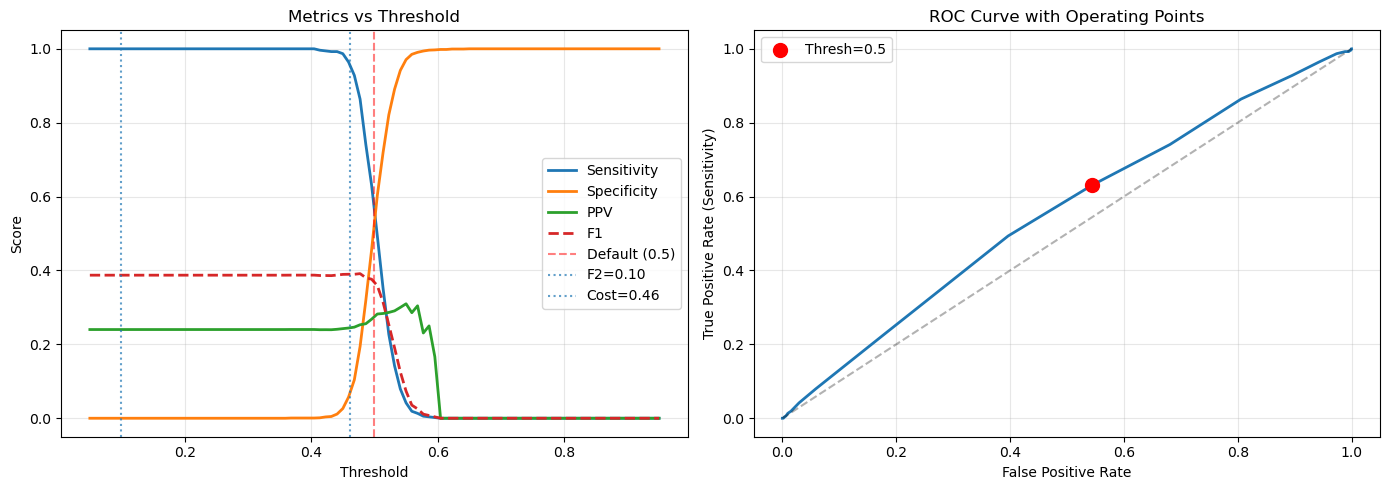

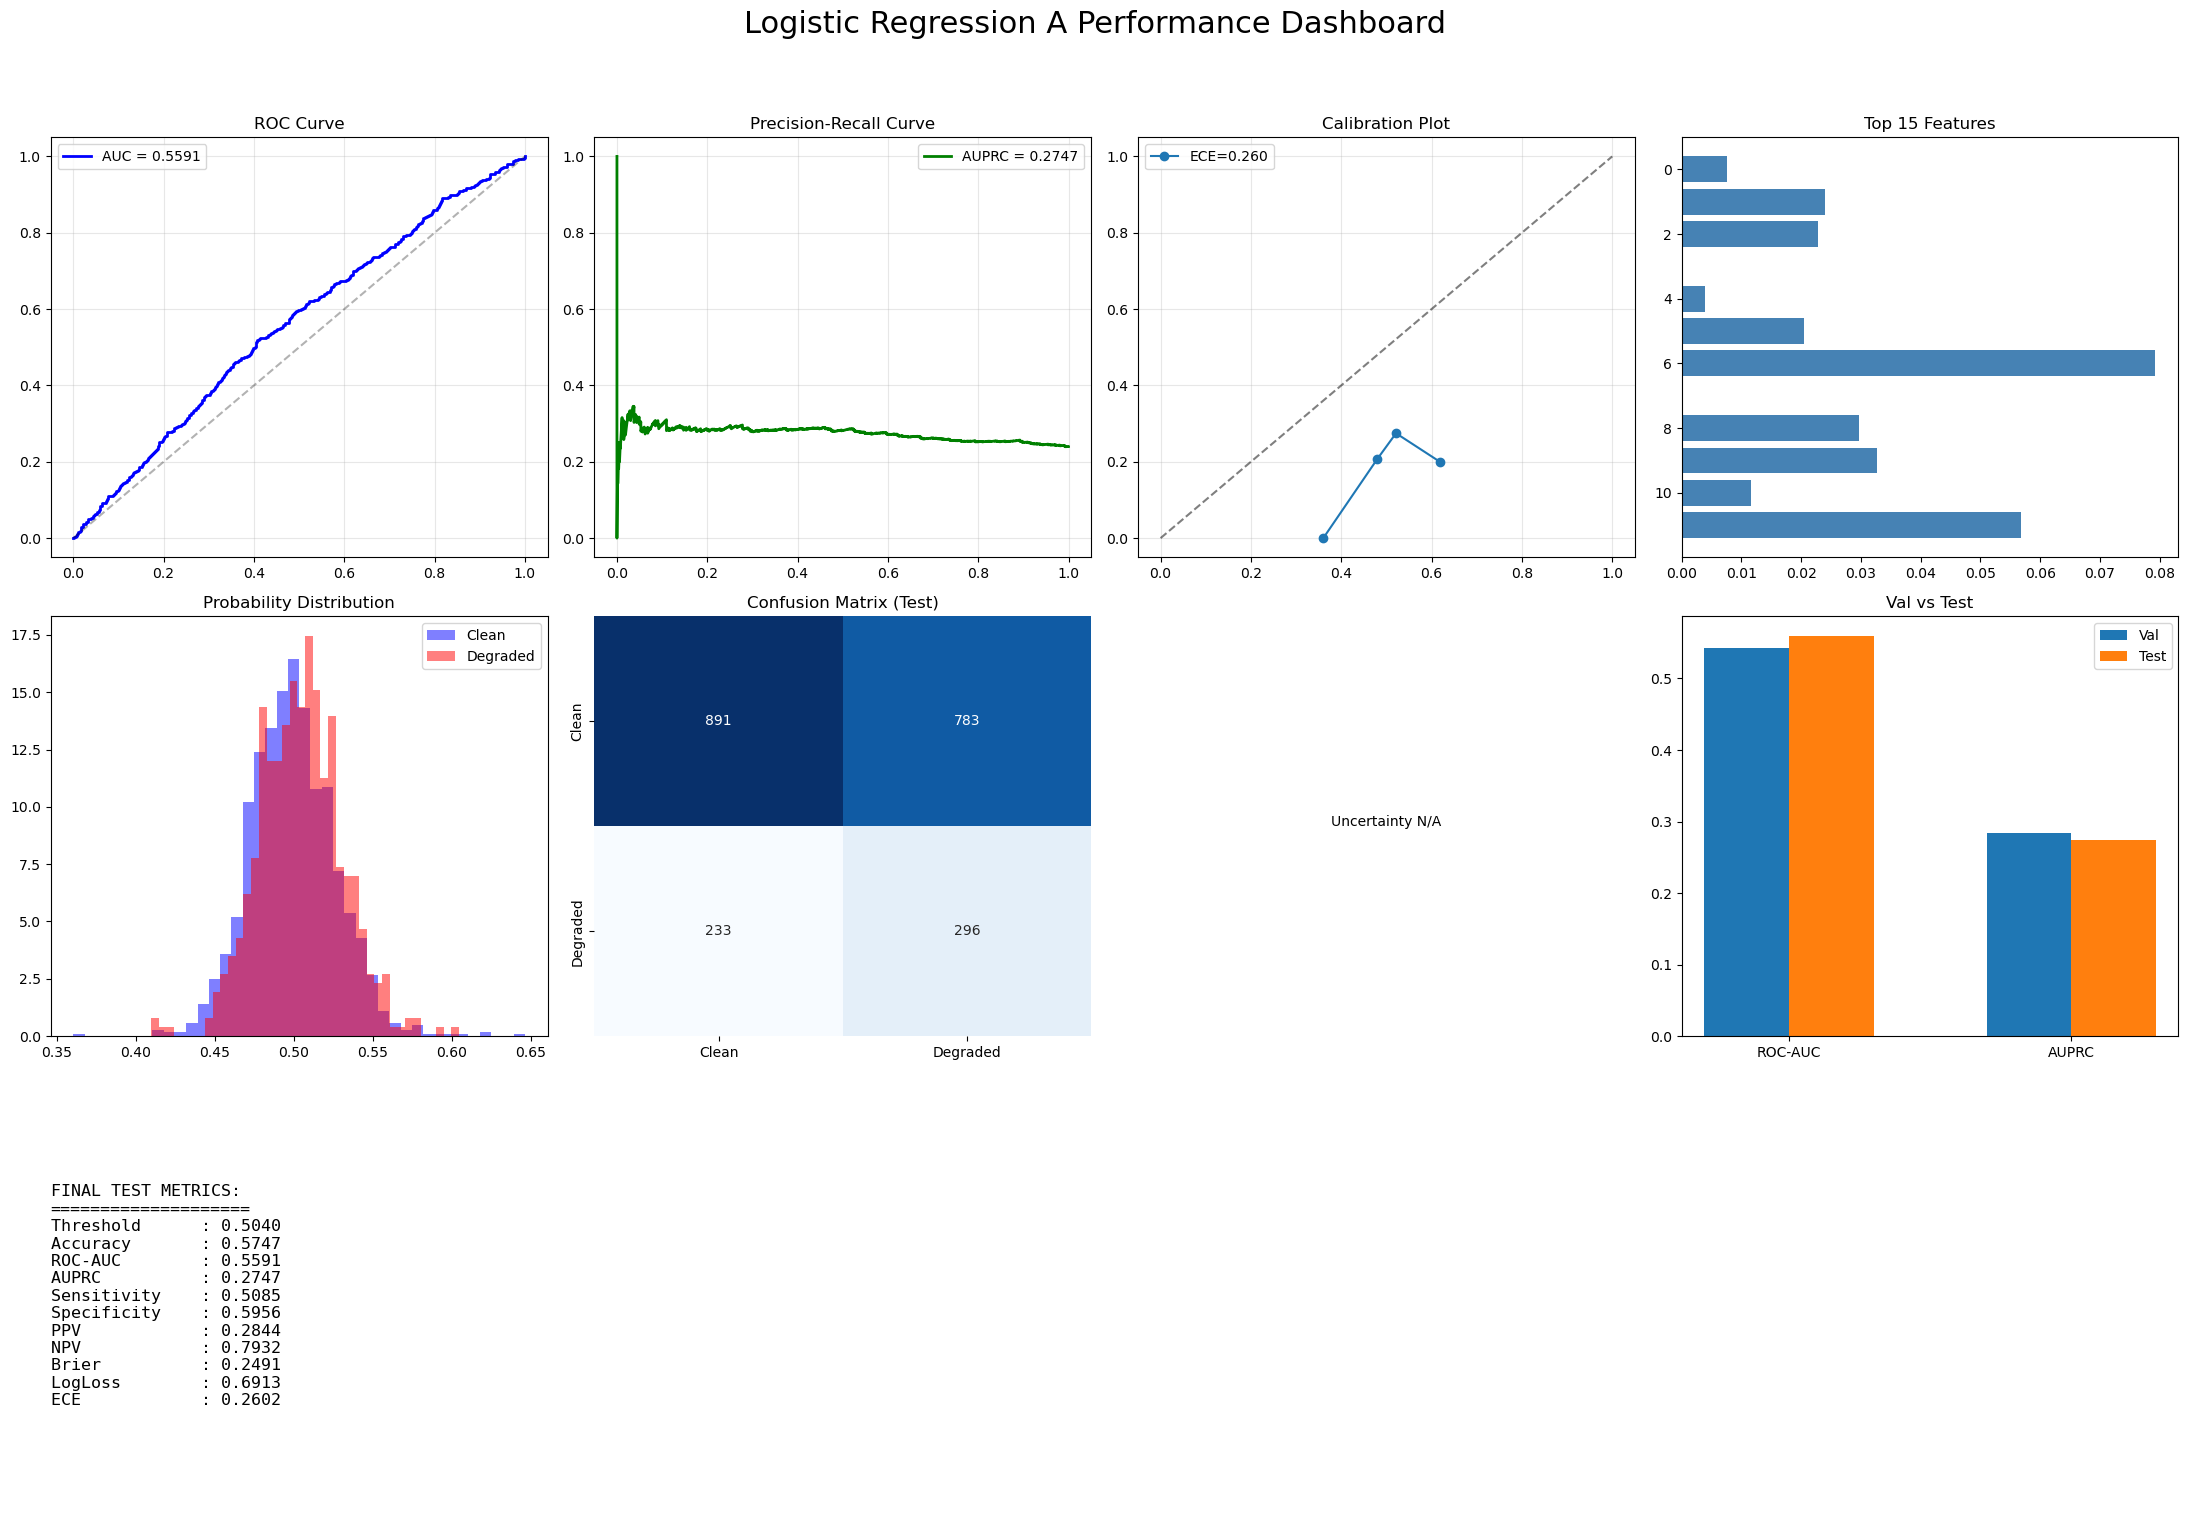

Dashboard saved to: output_clinical/results/Dashboard_Logistic_Regression_A.png


In [10]:
def train_logistic_a(df_basic, cols_basic, idx_tr, idx_val, idx_te, cfg):
    print("\n" + "="*80)
    print("LOGISTIC REGRESSION A (Basic SQI Features, L1-Regularized)")
    print("="*80)

    X_tr, y_tr, X_val, y_val, X_te, y_te = get_data(df_basic, cols_basic, idx_tr, idx_val, idx_te)

    # NOTE: Cache key matches original to reuse saved models
    params_a = {
        "model": "logistic_regression",
        "features": "basic_clinical",
        "n_feats": cfg.n_features_a,
    }

    cached_a = load_cached_results(cfg, "logistic_a_clinical", params_a)

    if cached_a and cached_a.get("model") is not None:
        print("Using cached results...")
        clf_a = LogisticECGClassifier(cfg, cfg.n_features_a)
        clf_a.model = cached_a["model"]
        clf_a.selector = cached_a["selector"]
        p_val = cached_a["p_val"]
        p_test = cached_a["p_test"]
        p_mean_a = cached_a["p_mean_a"]
        p_lower_a = cached_a.get("p_lower_a")
        p_upper_a = cached_a.get("p_upper_a")
        importance_a = cached_a["importance_a"]
    else:
        print("Training new model...")
        clf_a = LogisticECGClassifier(cfg, cfg.n_features_a)
        clf_a.fit(X_tr, y_tr, cols_basic)

        p_val = clf_a.predict_proba(X_val)
        p_test = clf_a.predict_proba(X_te)

        p_mean_a = p_test
        p_lower_a = None
        p_upper_a = None

        importance_a = pd.DataFrame({
            'feature': clf_a.selector.feature_names,
            'abs_mean': np.abs(clf_a.model.coef_[0])
        }).sort_values('abs_mean', ascending=False)

        cache_model_results(cfg, "logistic_a_clinical",
                            results={"p_val": p_val, "p_test": p_test, "p_mean_a": p_mean_a,
                                     "p_lower_a": p_lower_a, "p_upper_a": p_upper_a,
                                     "importance_a": importance_a, "model": clf_a.model},
                            params=params_a, selector=clf_a.selector)

    print("\nThreshold Optimization...")
    thresh_f2, _ = find_optimal_threshold(y_val, p_val, metric='fbeta', beta=2.0)
    thresh_youden, _ = find_optimal_threshold(y_val, p_val, metric='youden')
    thresh_cost, _ = cost_sensitive_threshold(y_val, p_val, cost_fn_to_fp_ratio=5.0)
    print(f"F2-Optimal: {thresh_f2:.3f}, Youden: {thresh_youden:.3f}, Cost: {thresh_cost:.3f}")

    m_val = calculate_metrics(y_val, p_val, threshold=thresh_youden)
    m_test = calculate_metrics(y_te, p_test, threshold=thresh_youden)
    m_test['ECE'] = calculate_ece(y_te, p_test)

    print("\n" + "="*80)
    print(f"LOGISTIC REGRESSION A - TEST RESULTS (Threshold={thresh_youden:.3f})")
    print("="*80)
    for k, v in m_test.items():
        print(f"{k:<15}: {v:.4f}")
    print("="*80)

    plot_threshold_analysis(y_te, p_test, cfg.cache_dir / "results" / "threshold_LR_A.png",
                            optimal_thresholds={'F2': thresh_f2, 'Cost': thresh_cost})

    generate_model_dashboard(y_test=y_te, p_mean=p_mean_a, model_name="Logistic Regression A",
                             save_dir=cfg.cache_dir / "results", p_lower=p_lower_a, p_upper=p_upper_a,
                             importance_df=importance_a, val_metrics=m_val, test_metrics=m_test)

    return {"metrics": m_test, "predictions": p_mean_a, "classifier": clf_a}

result_a = train_logistic_a(df_basic, cols_basic, idx_tr, idx_val, idx_te, cfg)

## MODEL 2: Logistic Regression B (Enhanced Features)


LOGISTIC REGRESSION B (Enhanced SQI Features, L1-Regularized)
Using cached results...

Threshold Optimization...
F2-Optimal: 0.100, Youden: 0.496, Cost: 0.050

LOGISTIC REGRESSION B - TEST RESULTS (Threshold=0.496)
Threshold      : 0.4960
Accuracy       : 0.5270
ROC-AUC        : 0.5559
AUPRC          : 0.2759
Sensitivity    : 0.5614
Specificity    : 0.5161
PPV            : 0.2683
NPV            : 0.7883
Brier          : 0.2486
LogLoss        : 0.6903
ECE            : 0.2592


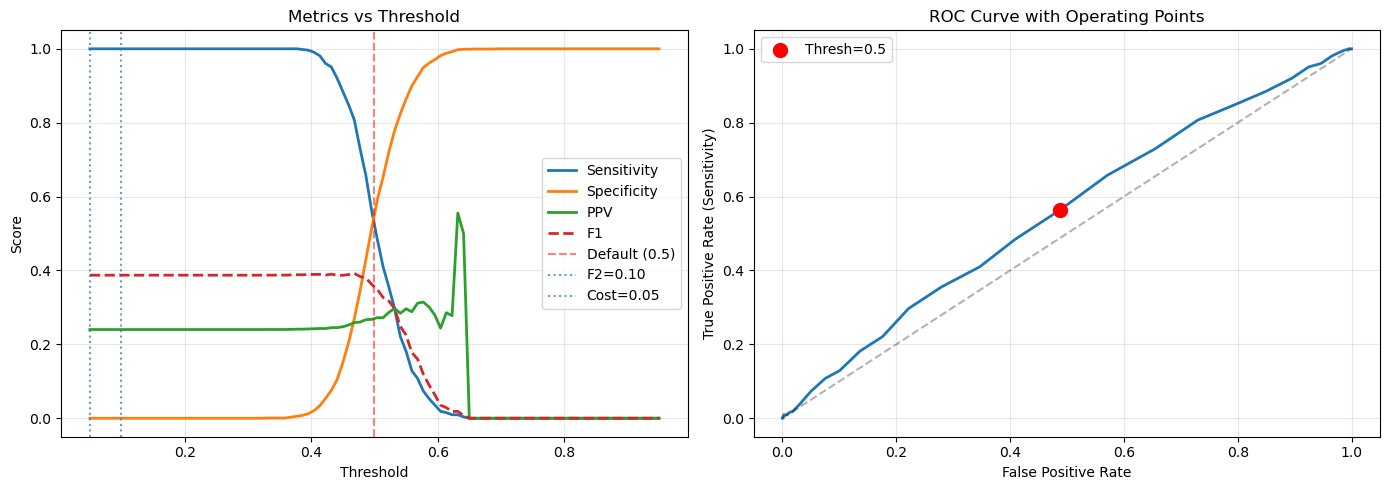

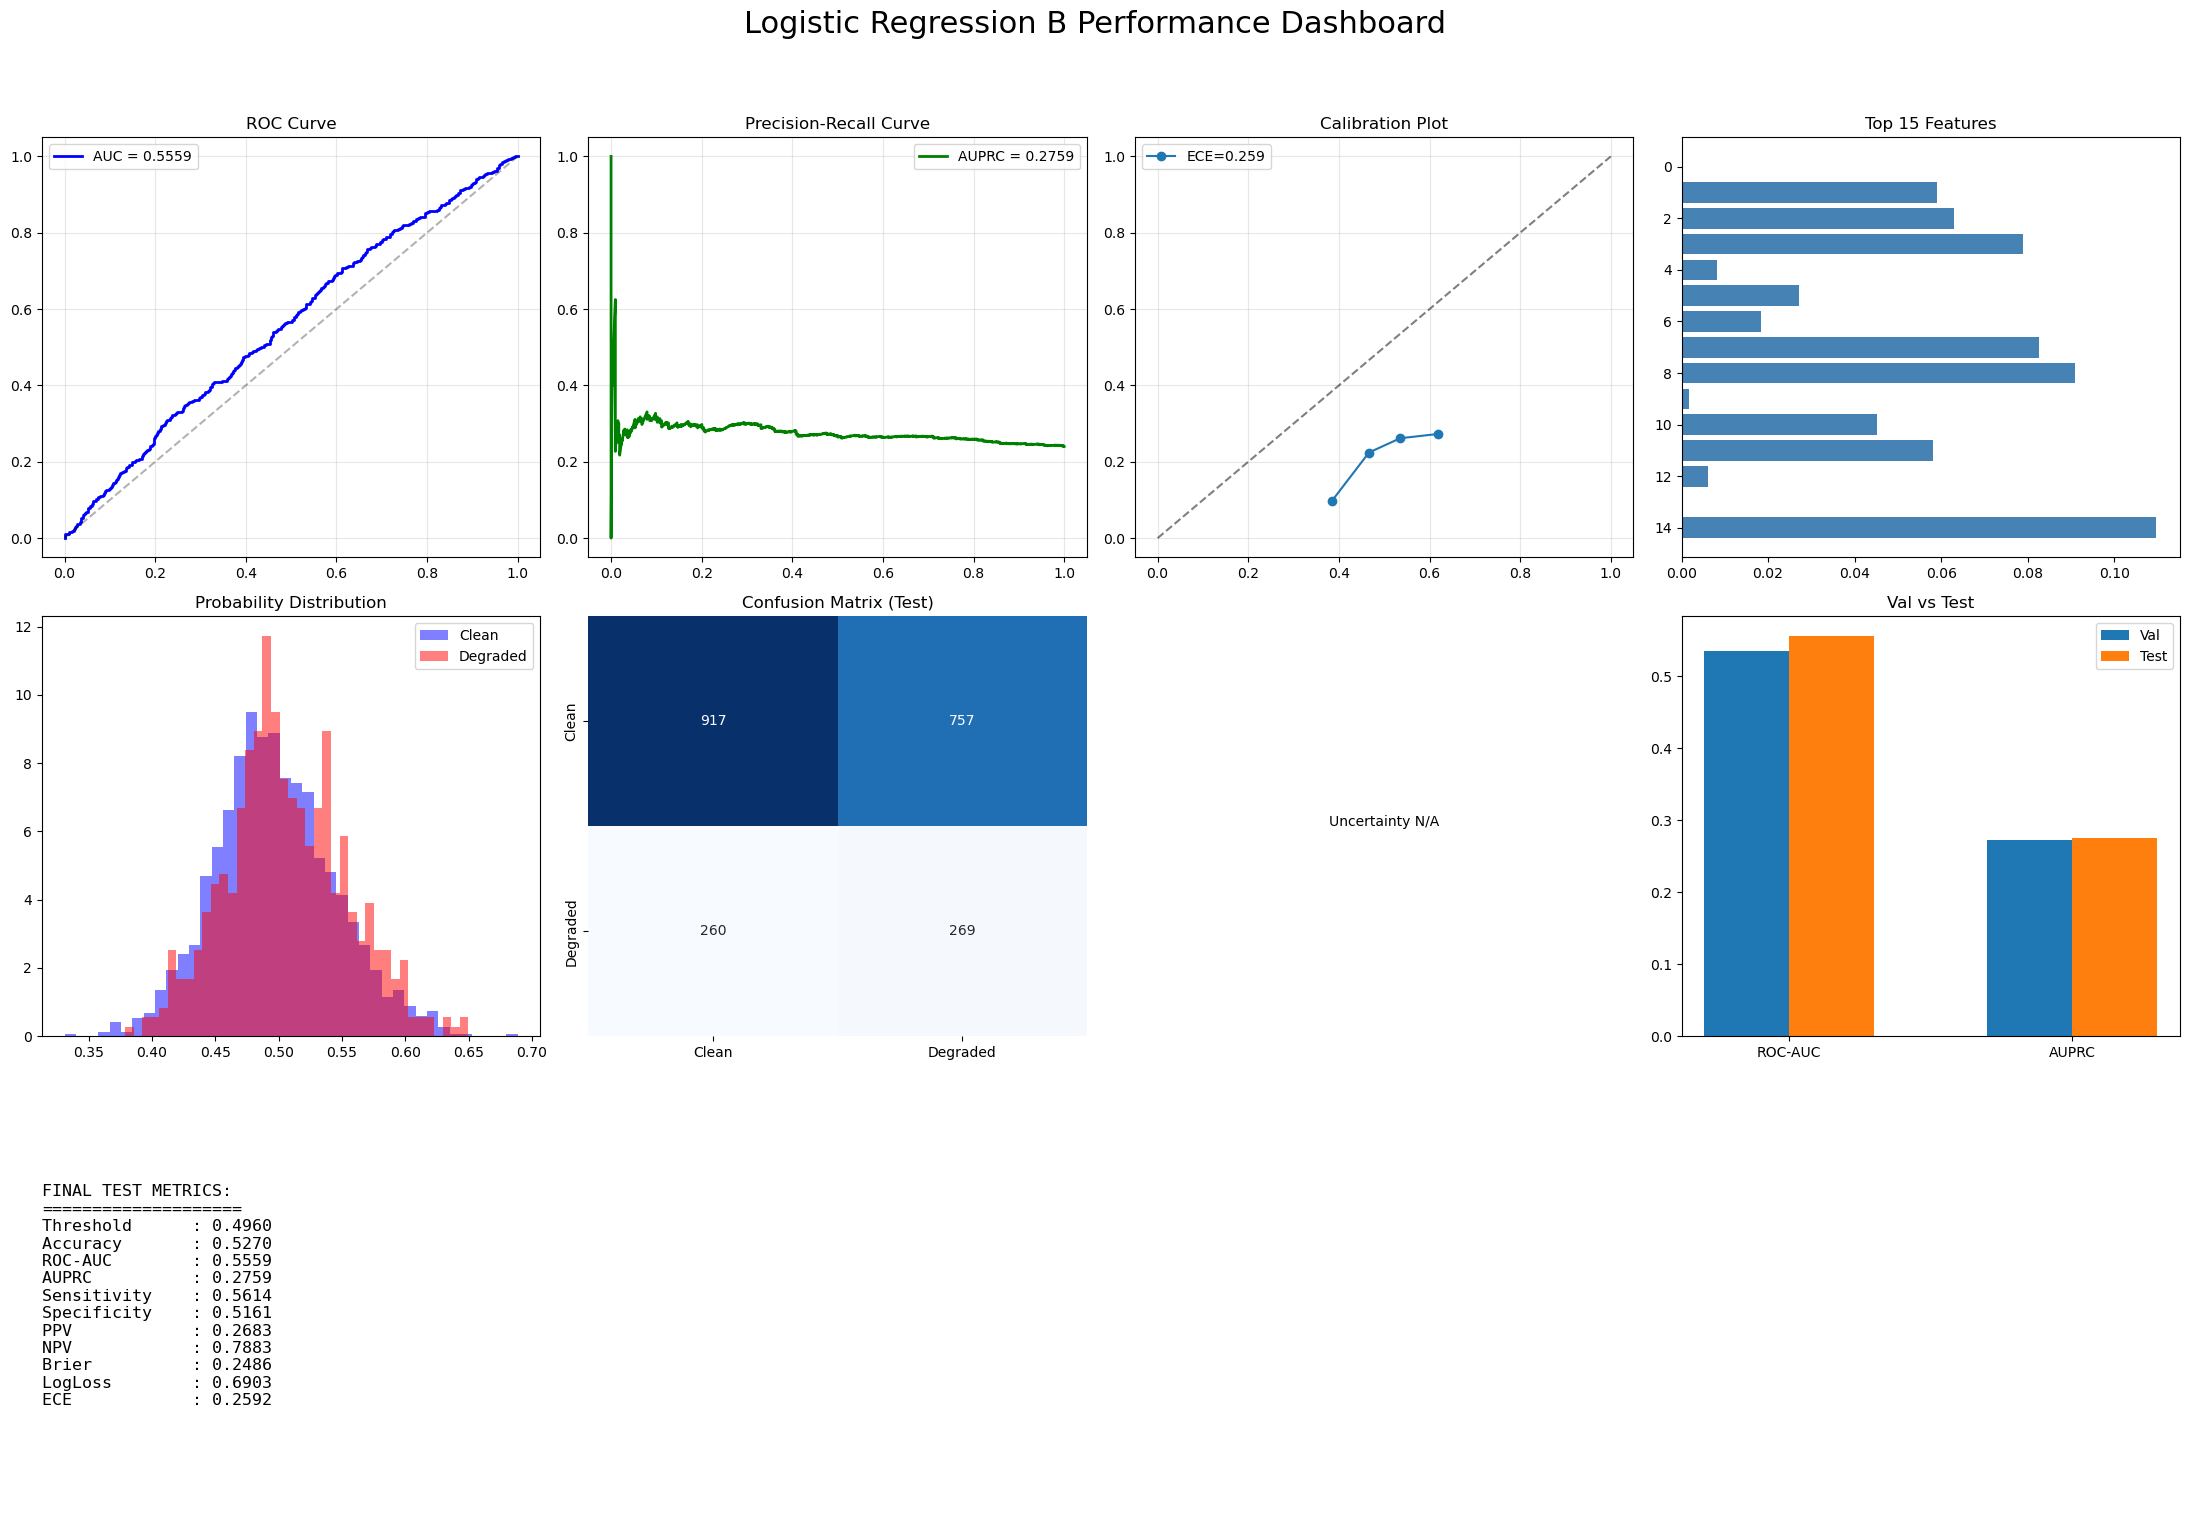

Dashboard saved to: output_clinical/results/Dashboard_Logistic_Regression_B.png


In [11]:
def train_logistic_b(df_enh, cols_enh, idx_tr, idx_val, idx_te, cfg):
    print("\n" + "="*80)
    print("LOGISTIC REGRESSION B (Enhanced SQI Features, L1-Regularized)")
    print("="*80)

    X_tr, y_tr, X_val, y_val, X_te, y_te = get_data(df_enh, cols_enh, idx_tr, idx_val, idx_te)

    params_b = {
        "model": "logistic_regression",
        "features": "enhanced_clinical",
        "n_feats": cfg.n_features_b,
    }

    cached_b = load_cached_results(cfg, "logistic_b_clinical", params_b)

    if cached_b and cached_b.get("model") is not None:
        print("Using cached results...")
        clf_b = LogisticECGClassifier(cfg, cfg.n_features_b)
        clf_b.model = cached_b["model"]
        clf_b.selector = cached_b["selector"]
        p_val_b = cached_b["p_val_b"]
        p_test_b = cached_b["p_test_b"]
        p_mean_b = cached_b["p_mean_b"]
        p_lower_b = cached_b.get("p_lower_b")
        p_upper_b = cached_b.get("p_upper_b")
        importance_b = cached_b["importance_b"]
    else:
        print("Training new model...")
        clf_b = LogisticECGClassifier(cfg, cfg.n_features_b)
        clf_b.fit(X_tr, y_tr, cols_enh)

        p_val_b = clf_b.predict_proba(X_val)
        p_test_b = clf_b.predict_proba(X_te)

        p_mean_b = p_test_b
        p_lower_b = None
        p_upper_b = None

        importance_b = pd.DataFrame({
            'feature': clf_b.selector.feature_names,
            'abs_mean': np.abs(clf_b.model.coef_[0])
        }).sort_values('abs_mean', ascending=False)

        cache_model_results(cfg, "logistic_b_clinical",
                            results={"p_val_b": p_val_b, "p_test_b": p_test_b, "p_mean_b": p_mean_b,
                                     "p_lower_b": p_lower_b, "p_upper_b": p_upper_b,
                                     "importance_b": importance_b, "model": clf_b.model},
                            params=params_b, selector=clf_b.selector)

    print("\nThreshold Optimization...")
    thresh_f2, _ = find_optimal_threshold(y_val, p_val_b, metric='fbeta', beta=2.0)
    thresh_youden, _ = find_optimal_threshold(y_val, p_val_b, metric='youden')
    thresh_cost, _ = cost_sensitive_threshold(y_val, p_val_b, cost_fn_to_fp_ratio=5.0)
    print(f"F2-Optimal: {thresh_f2:.3f}, Youden: {thresh_youden:.3f}, Cost: {thresh_cost:.3f}")

    m_val_b = calculate_metrics(y_val, p_val_b, threshold=thresh_youden)
    m_test_b = calculate_metrics(y_te, p_test_b, threshold=thresh_youden)
    m_test_b['ECE'] = calculate_ece(y_te, p_test_b)

    print("\n" + "="*80)
    print(f"LOGISTIC REGRESSION B - TEST RESULTS (Threshold={thresh_youden:.3f})")
    print("="*80)
    for k, v in m_test_b.items():
        print(f"{k:<15}: {v:.4f}")
    print("="*80)

    plot_threshold_analysis(y_te, p_test_b, cfg.cache_dir / "results" / "threshold_LR_B.png",
                            optimal_thresholds={'F2': thresh_f2, 'Cost': thresh_cost})

    generate_model_dashboard(y_test=y_te, p_mean=p_mean_b, model_name="Logistic Regression B",
                             save_dir=cfg.cache_dir / "results", p_lower=p_lower_b, p_upper=p_upper_b,
                             importance_df=importance_b, val_metrics=m_val_b, test_metrics=m_test_b)

    return {"metrics": m_test_b, "predictions": p_mean_b, "classifier": clf_b}

result_b = train_logistic_b(df_enh, cols_enh, idx_tr, idx_val, idx_te, cfg)

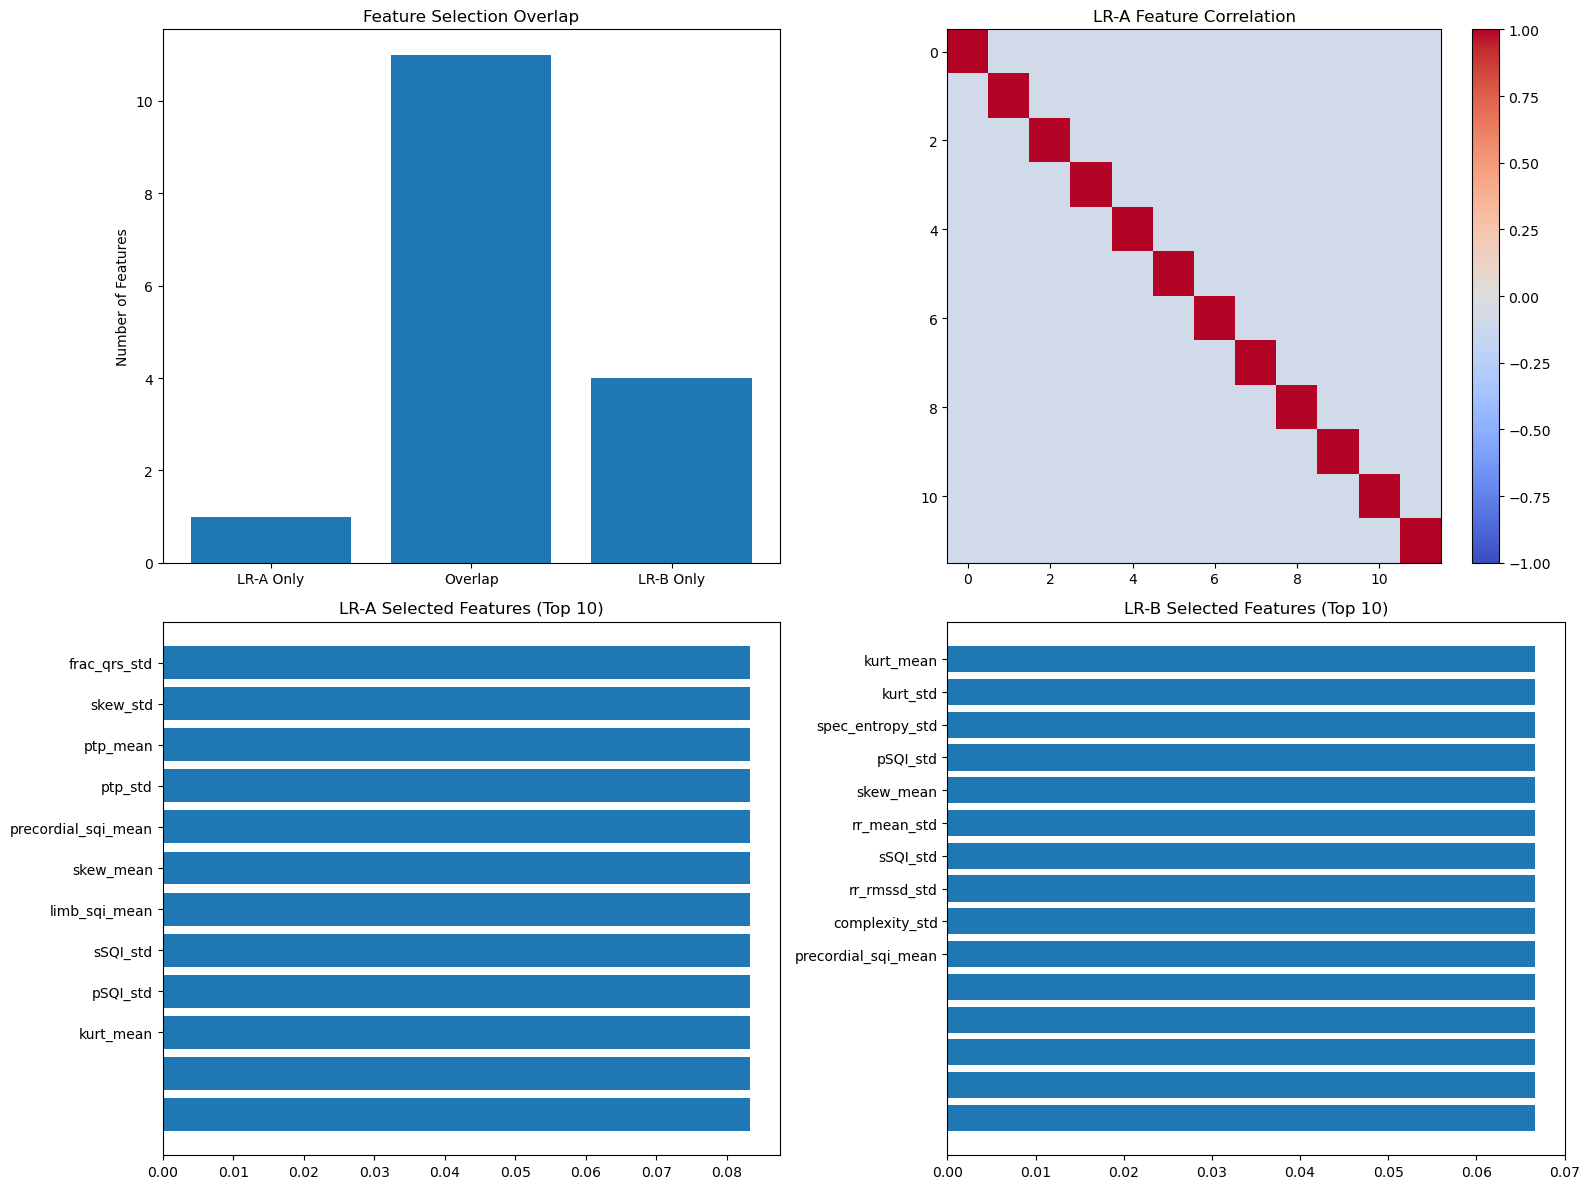

In [12]:
visualize_feature_selection(
    result_a["classifier"].selector,
    result_b["classifier"].selector,
    cols_basic, cols_enh,
    cfg.cache_dir / "results"
)

## MODEL 3: MLP (DL1)


MLP (Simple Feedforward Network on Basic Features)
Using cached results...

Threshold Optimization...
F2-Optimal: 0.100, Youden: 0.536, Cost: 0.050

MLP - TEST RESULTS (Threshold=0.536)
Threshold      : 0.5364
Accuracy       : 0.5138
ROC-AUC        : 0.5606
AUPRC          : 0.2878
Sensitivity    : 0.6181
Specificity    : 0.4809
PPV            : 0.2734
NPV            : 0.7994
Brier          : 0.2763
LogLoss        : 0.7497
ECE            : 0.3005


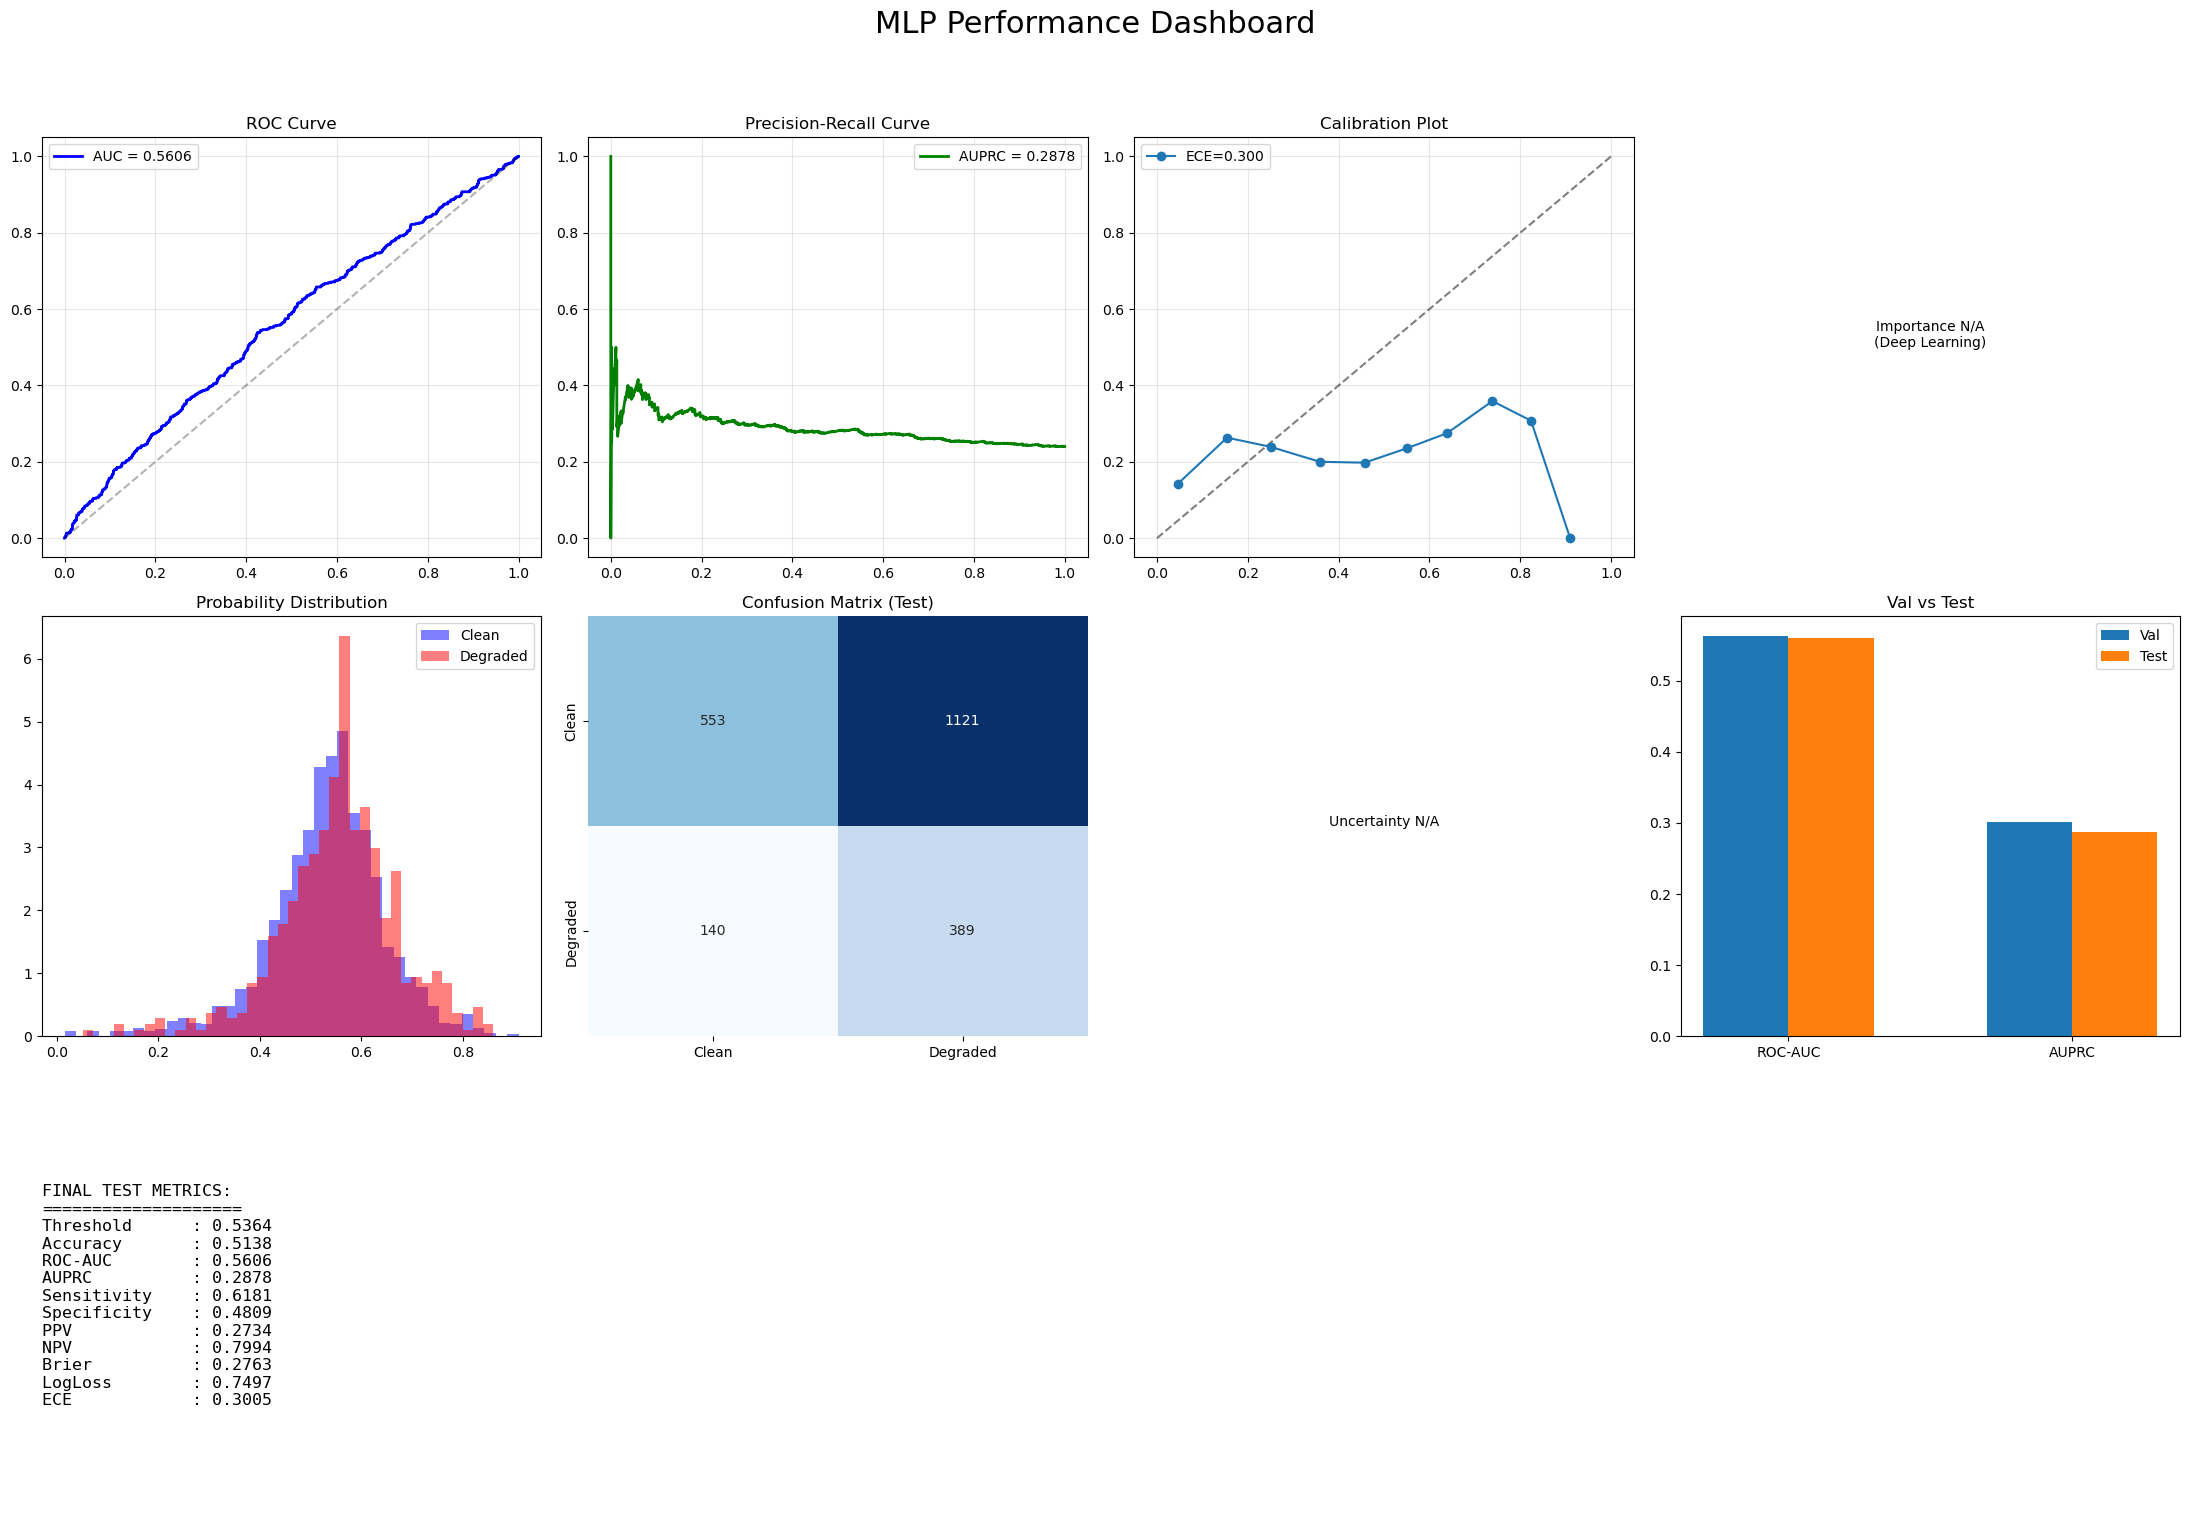

Dashboard saved to: output_clinical/results/Dashboard_MLP.png


In [13]:
def train_mlp_model(df_basic, cols_basic, idx_tr, idx_val, idx_te, cfg):
    print("\n" + "="*80)
    print("MLP (Simple Feedforward Network on Basic Features)")
    print("="*80)

    X_tr, y_tr, X_val, y_val, X_te, y_te = get_data(df_basic, cols_basic, idx_tr, idx_val, idx_te)

    params_dl1 = {
        'epochs': cfg.dl1_epochs, 'lr': cfg.lr,
        'batch_size': cfg.batch_size, 'features': 'basic_clinical'
    }

    cached_dl1 = load_cached_results(cfg, 'dl1_clinical', params_dl1)

    if cached_dl1:
        print("Using cached results...")
        res_dl1 = cached_dl1['results']
        p_val_dl1 = res_dl1["Val"][1]
        p_test_dl1 = res_dl1["Test"][1]
    else:
        print("Training new model...")
        res_dl1 = run_mlp(X_tr, y_tr, X_val, y_val, X_te, y_te, cfg)
        p_val_dl1 = res_dl1["Val"][1]
        p_test_dl1 = res_dl1["Test"][1]
        cache_model_results(cfg, 'dl1_clinical', {'results': res_dl1}, params_dl1)

    print("\nThreshold Optimization...")
    thresh_f2, _ = find_optimal_threshold(y_val, p_val_dl1, metric='fbeta', beta=2.0)
    thresh_youden, _ = find_optimal_threshold(y_val, p_val_dl1, metric='youden')
    thresh_cost, _ = cost_sensitive_threshold(y_val, p_val_dl1, cost_fn_to_fp_ratio=5.0)
    print(f"F2-Optimal: {thresh_f2:.3f}, Youden: {thresh_youden:.3f}, Cost: {thresh_cost:.3f}")

    m_test_dl1 = calculate_metrics(y_te, p_test_dl1, threshold=thresh_youden)
    m_test_dl1['ECE'] = calculate_ece(y_te, p_test_dl1)

    print("\n" + "="*80)
    print(f"MLP - TEST RESULTS (Threshold={thresh_youden:.3f})")
    print("="*80)
    for k, v in m_test_dl1.items():
        print(f"{k:<15}: {v:.4f}")
    print("="*80)

    generate_model_dashboard(y_test=y_te, p_mean=p_test_dl1, model_name="MLP",
                             save_dir=cfg.cache_dir / "results",
                             val_metrics=calculate_metrics(y_val, p_val_dl1, threshold=thresh_youden),
                             test_metrics=m_test_dl1)

    return {"metrics": m_test_dl1, "predictions": p_test_dl1}

result_dl1 = train_mlp_model(df_basic, cols_basic, idx_tr, idx_val, idx_te, cfg)

## MODEL 4: CNN (DL2)


CNN (1D Convolutional Network on Raw Waveforms)
Training new model...
Training CNN on mps...
Early stopping at epoch 32

Threshold Optimization...
F2-Optimal: 0.504, Youden: 0.593, Cost: 0.498

CNN - TEST RESULTS (Threshold=0.593)
Threshold      : 0.5929
Accuracy       : 0.6818
ROC-AUC        : 0.8007
AUPRC          : 0.5491
Sensitivity    : 0.8110
Specificity    : 0.6410
PPV            : 0.4165
NPV            : 0.9147
Brier          : 0.2431
LogLoss        : 0.7238
ECE            : 0.2781


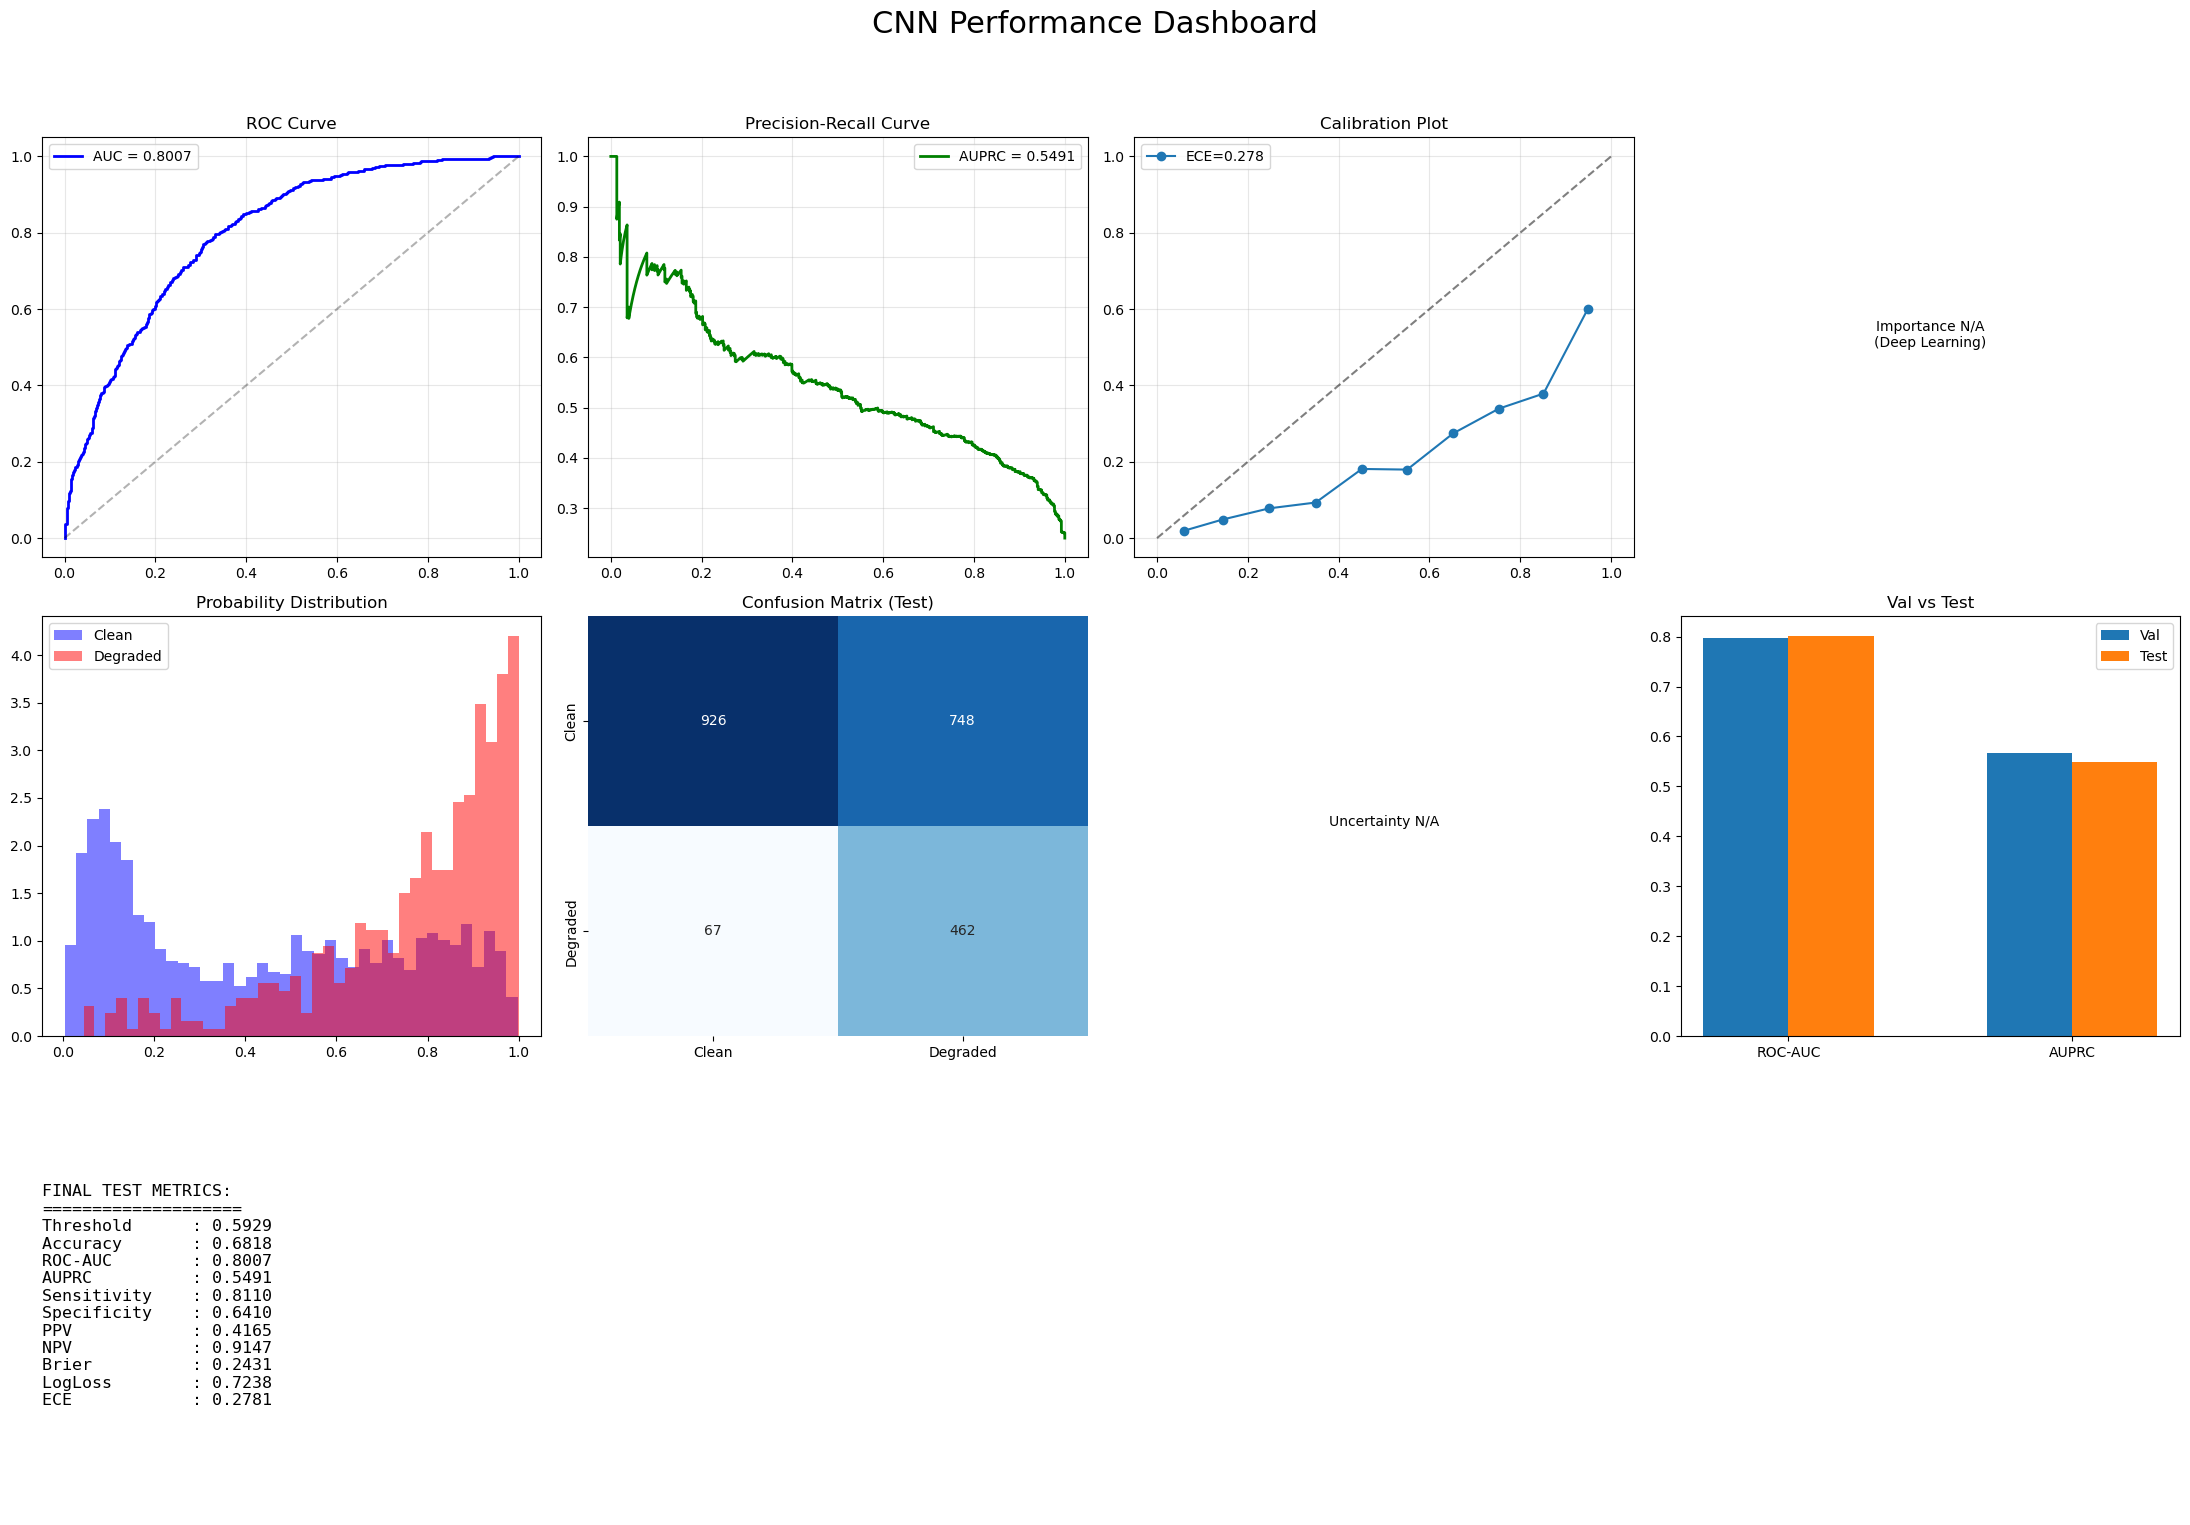

Dashboard saved to: output_clinical/results/Dashboard_CNN.png


In [14]:
def train_cnn_model(db, y_all, idx_tr, idx_val, idx_te, cfg):
    print("\n" + "="*80)
    print("CNN (1D Convolutional Network on Raw Waveforms)")
    print("="*80)

    params_dl2 = {
        'epochs': cfg.dl2_epochs, 'lr': cfg.lr,
        'batch_size': cfg.batch_size, 'architecture': 'resnet'
    }

    cached_dl2 = load_cached_results(cfg, 'dl2_clinical', params_dl2)

    if cached_dl2:
        print("Using cached results...")
        res_dl2 = cached_dl2['results']
        p_val_dl2 = res_dl2["Val"][1]
        p_test_dl2 = res_dl2["Test"][1]
    else:
        print("Training new model...")
        res_dl2 = run_cnn(db, pd.Series(y_all), idx_tr, idx_val, idx_te, cfg)
        p_val_dl2 = res_dl2["Val"][1]
        p_test_dl2 = res_dl2["Test"][1]
        cache_model_results(cfg, 'dl2_clinical', {'results': res_dl2}, params_dl2)

    y_val_dl2 = y_all[idx_val]
    y_te_dl2 = y_all[idx_te]

    print("\nThreshold Optimization...")
    thresh_f2, _ = find_optimal_threshold(y_val_dl2, p_val_dl2, metric='fbeta', beta=2.0)
    thresh_youden, _ = find_optimal_threshold(y_val_dl2, p_val_dl2, metric='youden')
    thresh_cost, _ = cost_sensitive_threshold(y_val_dl2, p_val_dl2, cost_fn_to_fp_ratio=5.0)
    print(f"F2-Optimal: {thresh_f2:.3f}, Youden: {thresh_youden:.3f}, Cost: {thresh_cost:.3f}")

    m_test_dl2 = calculate_metrics(y_te_dl2, p_test_dl2, threshold=thresh_youden)
    m_test_dl2['ECE'] = calculate_ece(y_te_dl2, p_test_dl2)

    print("\n" + "="*80)
    print(f"CNN - TEST RESULTS (Threshold={thresh_youden:.3f})")
    print("="*80)
    for k, v in m_test_dl2.items():
        print(f"{k:<15}: {v:.4f}")
    print("="*80)

    generate_model_dashboard(y_test=y_te_dl2, p_mean=p_test_dl2, model_name="CNN",
                             save_dir=cfg.cache_dir / "results",
                             val_metrics=calculate_metrics(y_val_dl2, p_val_dl2, threshold=thresh_youden),
                             test_metrics=m_test_dl2)

    return {"metrics": m_test_dl2, "predictions": p_test_dl2, "y_test": y_te_dl2}

result_dl2 = train_cnn_model(db, y_all, idx_tr, idx_val, idx_te, cfg)

## MODEL 5: CNN-Transformer Ensemble (DL3)


CNN-TRANSFORMER ENSEMBLE (Multi-Scale CNN + Transformer + Uncertainty)
Training new ensemble...
Training CNN-Transformer Ensemble (5 models) on mps...

  Model 1/5
    Epoch 0: AUC=0.7504
    Epoch 20: AUC=0.7965
    Early stop epoch 26, best AUC: 0.7970
    Final AUC: 0.7970

  Model 2/5
    Epoch 0: AUC=0.7482
    Epoch 20: AUC=0.7789
    Early stop epoch 33, best AUC: 0.8052
    Final AUC: 0.8052

  Model 3/5
    Epoch 0: AUC=0.7434
    Epoch 20: AUC=0.7758
    Early stop epoch 25, best AUC: 0.7986
    Final AUC: 0.7986

  Model 4/5
    Epoch 0: AUC=0.7652
    Epoch 20: AUC=0.8069
    Early stop epoch 31, best AUC: 0.8152
    Final AUC: 0.8152

  Model 5/5
    Epoch 0: AUC=0.7506
    Epoch 20: AUC=0.7783
    Early stop epoch 25, best AUC: 0.8018
    Final AUC: 0.8018

Threshold Optimization...
F2-Optimal: 0.431, Youden: 0.577, Cost: 0.448

CNN-TRANSFORMER ENSEMBLE - TEST RESULTS (Threshold=0.577)
Threshold      : 0.5768
Accuracy       : 0.7345
ROC-AUC        : 0.8107
AUPRC         

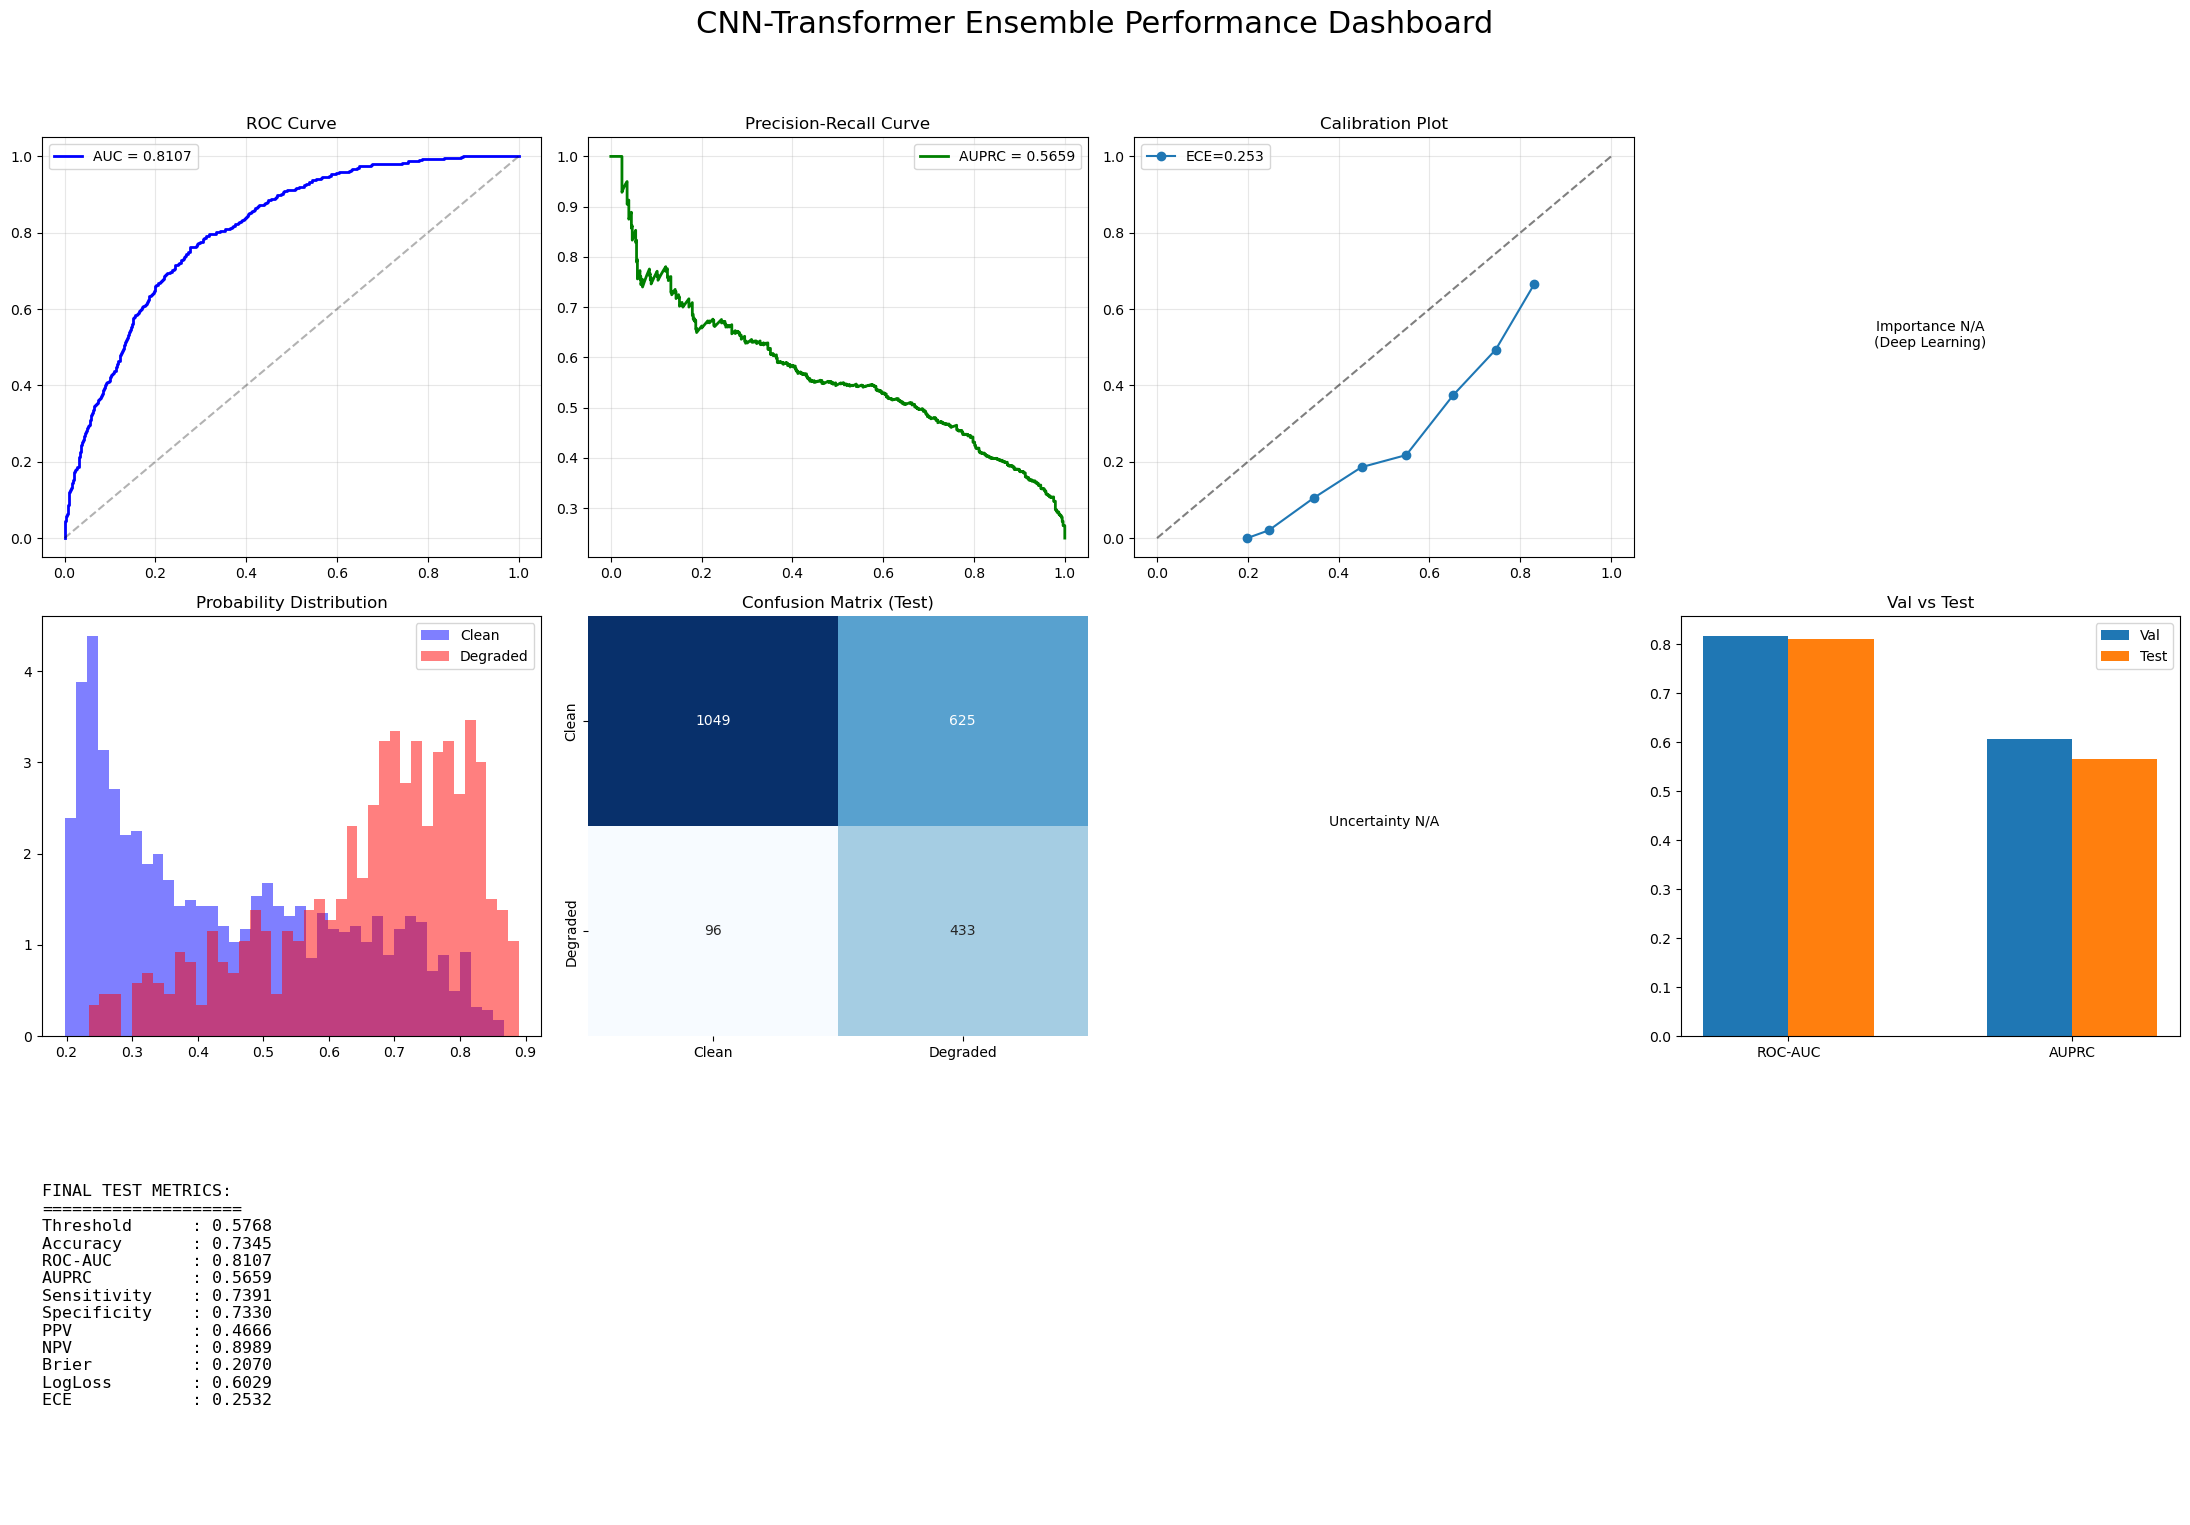

Dashboard saved to: output_clinical/results/Dashboard_CNN-Transformer_Ensemble.png


In [15]:
def train_cnn_transformer_model(db, y_all, idx_tr, idx_val, idx_te, cfg):
    print("\n" + "="*80)
    print("CNN-TRANSFORMER ENSEMBLE (Multi-Scale CNN + Transformer + Uncertainty)")
    print("="*80)

    params_dl3 = {
        'epochs': cfg.dl3_epochs, 'lr': cfg.dl3_lr, 'd_model': cfg.dl3_d_model,
        'n_heads': cfg.dl3_n_heads, 'n_layers': cfg.dl3_n_layers,
        'n_ensemble': cfg.dl3_n_ensemble, 'focal_gamma': cfg.dl3_focal_gamma
    }

    cached_dl3 = load_cached_results(cfg, 'dl3_clinical', params_dl3)

    if cached_dl3:
        print("Using cached results...")
        res_dl3 = cached_dl3['results']
        p_val_dl3 = res_dl3["Val"][1]
        p_test_dl3 = res_dl3["Test"][1]
        epistemic = res_dl3.get("epistemic")
        aleatoric = res_dl3.get("aleatoric")
        coverage = res_dl3.get("coverage")
    else:
        print("Training new ensemble...")
        res_dl3 = run_cnn_transformer_ensemble(db, pd.Series(y_all), idx_tr, idx_val, idx_te, cfg)
        p_val_dl3 = res_dl3["Val"][1]
        p_test_dl3 = res_dl3["Test"][1]
        epistemic = res_dl3["epistemic"]
        aleatoric = res_dl3["aleatoric"]
        coverage = res_dl3["coverage"]
        cache_results = {k: v for k, v in res_dl3.items() if k != 'models'}
        cache_model_results(cfg, 'dl3_clinical', {'results': cache_results}, params_dl3)

    y_val_dl3 = y_all[idx_val]
    y_te_dl3 = y_all[idx_te]

    print("\nThreshold Optimization...")
    thresh_f2, _ = find_optimal_threshold(y_val_dl3, p_val_dl3, metric='fbeta', beta=2.0)
    thresh_youden, _ = find_optimal_threshold(y_val_dl3, p_val_dl3, metric='youden')
    thresh_cost, _ = cost_sensitive_threshold(y_val_dl3, p_val_dl3, cost_fn_to_fp_ratio=5.0)
    print(f"F2-Optimal: {thresh_f2:.3f}, Youden: {thresh_youden:.3f}, Cost: {thresh_cost:.3f}")

    m_test_dl3 = calculate_metrics(y_te_dl3, p_test_dl3, threshold=thresh_youden)
    m_test_dl3['ECE'] = calculate_ece(y_te_dl3, p_test_dl3)

    print("\n" + "="*80)
    print(f"CNN-TRANSFORMER ENSEMBLE - TEST RESULTS (Threshold={thresh_youden:.3f})")
    print("="*80)
    for k, v in m_test_dl3.items():
        print(f"{k:<15}: {v:.4f}")

    if epistemic is not None:
        print(f"\nUncertainty Quantification:")
        print(f"  Epistemic (model): {np.mean(epistemic):.4f} +/- {np.std(epistemic):.4f}")
        print(f"  Aleatoric (data):  {np.mean(aleatoric):.4f} +/- {np.std(aleatoric):.4f}")
        print(f"  Conformal Coverage: {coverage:.4f} (target: {1-cfg.conformal_alpha:.2f})")
        total_unc = np.sqrt(epistemic**2 + aleatoric**2)
        for pct in [25, 50, 75]:
            mask = total_unc <= np.percentile(total_unc, pct)
            if mask.sum() > 0:
                acc = accuracy_score(y_te_dl3[mask], (p_test_dl3[mask] >= thresh_youden).astype(int))
                print(f"  Accuracy (top {pct}% confident): {acc:.4f}")
    print("="*80)

    generate_model_dashboard(y_test=y_te_dl3, p_mean=p_test_dl3,
                             model_name="CNN-Transformer Ensemble",
                             save_dir=cfg.cache_dir / "results",
                             val_metrics=calculate_metrics(y_val_dl3, p_val_dl3, threshold=thresh_youden),
                             test_metrics=m_test_dl3)

    return {"metrics": m_test_dl3, "predictions": p_test_dl3, "y_test": y_te_dl3,
            "epistemic": epistemic, "aleatoric": aleatoric, "coverage": coverage}

result_dl3 = train_cnn_transformer_model(db, y_all, idx_tr, idx_val, idx_te, cfg)

## FINAL COMPARISON

In [16]:
def generate_final_comparison(results_dict, y_te, cfg):
    # Display names for the table
    DISPLAY_NAMES = {
        "LR-A": "Logistic Regression A",
        "LR-B": "Logistic Regression B",
        "MLP": "MLP",
        "CNN": "CNN",
        "CNN-Transformer": "CNN-Transformer Ensemble"
    }

    print("\n" + "="*120)
    print(f"{'FINAL BENCHMARK COMPARISON (TEST SET)':^120}")
    print("="*120)

    cols = ["ROC-AUC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "ECE"]
    bench = results_dict["CNN-Transformer"]["metrics"]

    print(f"{'Model':<30} | " + " | ".join([f"{c:^13}" for c in cols]))
    print("-" * 130)
    print(f"\033[1m{'CNN-Transformer (Benchmark)':<30}\033[0m | " +
          " | ".join([f"\033[1m{bench[c]:.4f}\033[0m" for c in cols]))
    print("-" * 130)

    for model_key in ["LR-A", "LR-B", "MLP", "CNN"]:
        row = results_dict[model_key]["metrics"]
        row_str = f"{DISPLAY_NAMES[model_key]:<30} | "
        for c in cols:
            val = row[c]
            diff = (bench[c] - val) if c == "ECE" else (val - bench[c])
            color = "\033[92m" if diff > 0 else "\033[91m"
            row_str += f"{val:.4f} ({color}{diff:+.4f}\033[0m) | "
        print(row_str)

    # Statistical comparisons
    print("\n" + "="*120)
    print("STATISTICAL COMPARISONS (Bootstrap DeLong Test vs CNN-Transformer)")
    print("="*120)

    p_test_bench = results_dict["CNN-Transformer"]["predictions"]

    for model_key in ["LR-A", "LR-B", "MLP", "CNN"]:
        preds = results_dict[model_key]["predictions"]
        result = delong_test(y_te, preds, p_test_bench)
        sig = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"{DISPLAY_NAMES[model_key]:<30} | AUC Diff: {result['Diff']:+.4f} | "
              f"95% CI: [{result['CI_lower']:+.4f}, {result['CI_upper']:+.4f}] | "
              f"p={result['p_value']:.4f} {sig}")

    # Per-class performance
    print("\n" + "="*120)
    print("PER-CLASS PERFORMANCE")
    print("="*120)

    for model_key in ["CNN-Transformer", "CNN", "LR-A", "LR-B", "MLP"]:
        preds = results_dict[model_key]["predictions"]
        metrics = calculate_per_class_metrics(y_te, preds)
        print(f"\n{DISPLAY_NAMES.get(model_key, model_key)}:")
        for cls in ["Clean", "Degraded"]:
            print(f"  {cls:>10}: Prec={metrics[cls]['Precision']:.3f} | "
                  f"Rec={metrics[cls]['Recall']:.3f} | F1={metrics[cls]['F1']:.3f} | "
                  f"n={metrics[cls]['Support']}")

    # Comparison bar chart
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    metrics_to_plot = ["ROC-AUC", "AUPRC", "Sensitivity", "Specificity"]
    model_keys = ["LR-A", "LR-B", "MLP", "CNN", "CNN-Transformer"]
    model_labels = [DISPLAY_NAMES[k] for k in model_keys]

    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        values = [results_dict[m]["metrics"][metric] for m in model_keys]
        bars = ax.bar(model_labels, values,
                      color=['steelblue', 'coral', 'lightgreen', 'gold', 'purple'])
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Comparison')
        ax.set_ylim([min(values) - 0.05, 1.0])
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)

        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(cfg.cache_dir / "results" / "final_comparison.png", dpi=300)
    plt.show()


                                         FINAL BENCHMARK COMPARISON (TEST SET)                                          
Model                          |    ROC-AUC    |     AUPRC     |  Sensitivity  |  Specificity  |      PPV      |      NPV      |      ECE     
----------------------------------------------------------------------------------------------------------------------------------
CNN-Transformer (Benchmark)    | 0.8107 | 0.5659 | 0.7391 | 0.7330 | 0.4666 | 0.8989 | 0.2532
----------------------------------------------------------------------------------------------------------------------------------
Logistic Regression A          | 0.5591 (-0.2516) | 0.2747 (-0.2912) | 0.5085 (-0.2306) | 0.5956 (-0.1374) | 0.2844 (-0.1822) | 0.7932 (-0.1057) | 0.2602 (-0.0070) | 
Logistic Regression B          | 0.5559 (-0.2549) | 0.2759 (-0.2901) | 0.5614 (-0.1777) | 0.5161 (-0.2168) | 0.2683 (-0.1983) | 0.7883 (-0.1106) | 0.2592 (-0.0060) | 
MLP                            | 0.5606 (-0.2

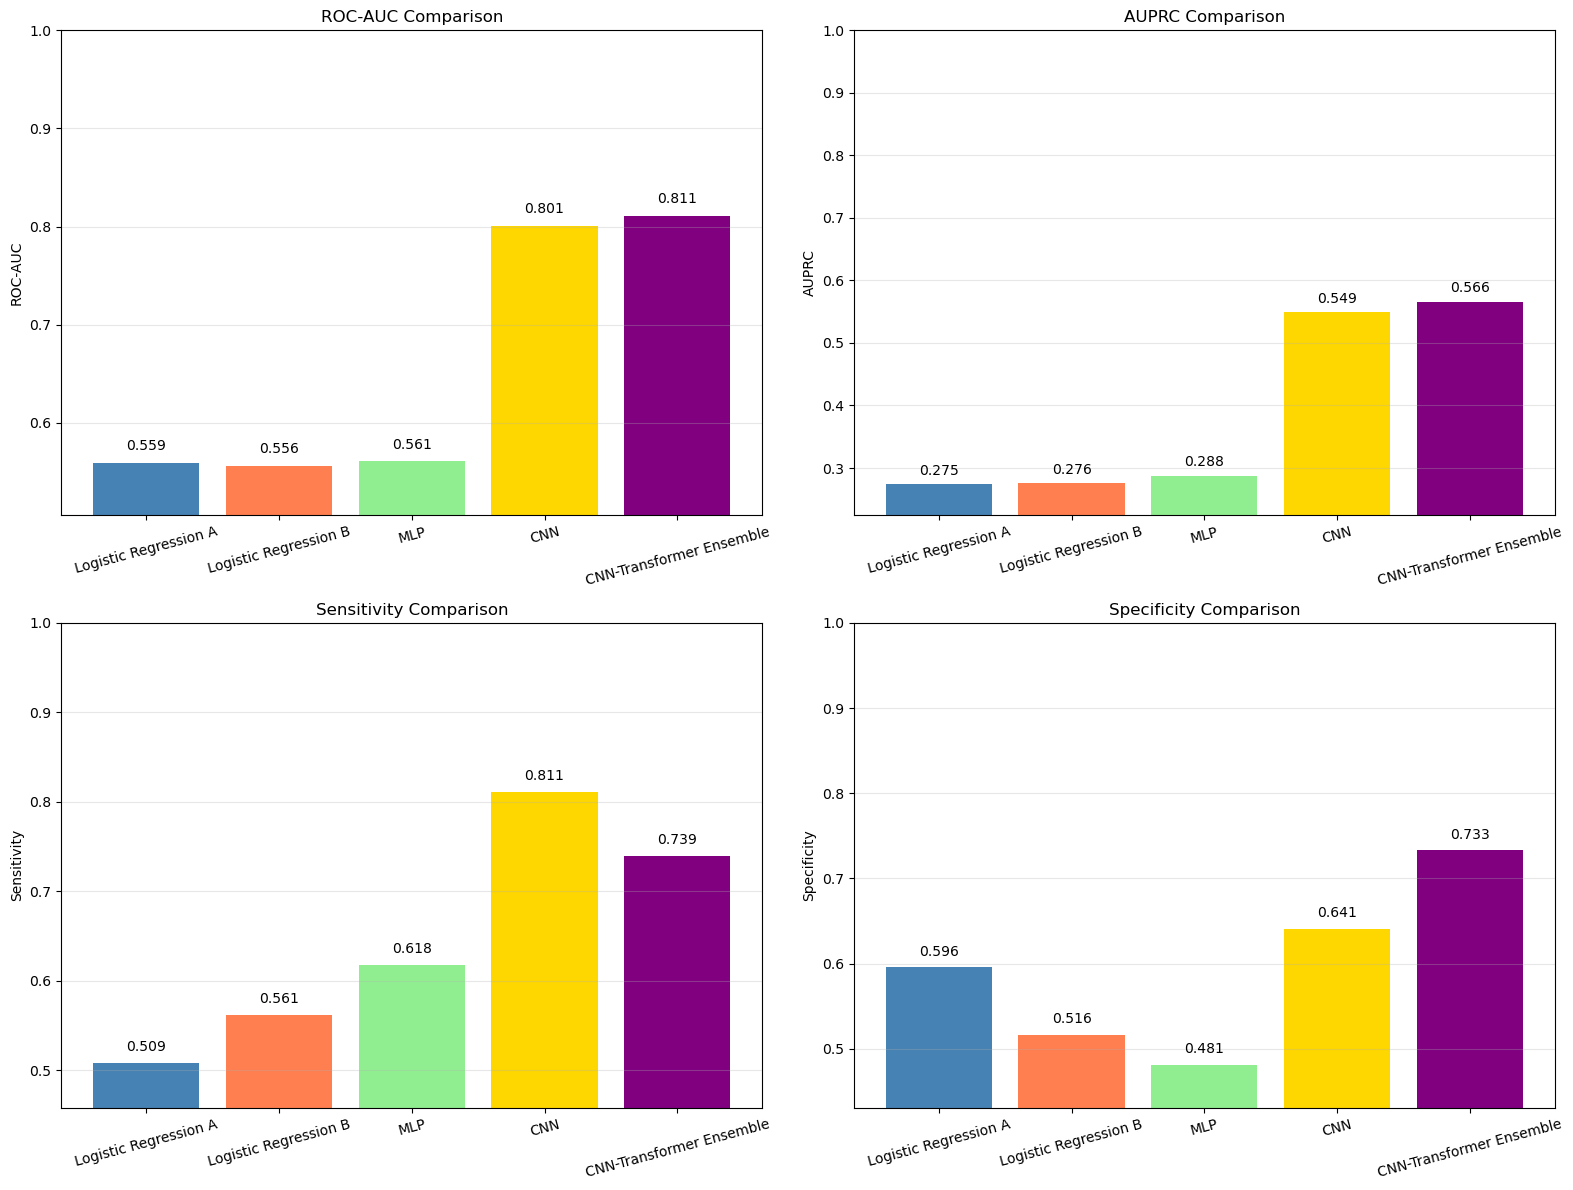

In [17]:
X_tr, y_tr, X_val, y_val, X_te, y_te = get_data(df_basic, cols_basic, idx_tr, idx_val, idx_te)

results = {
    "LR-A": result_a,
    "LR-B": result_b,
    "MLP": result_dl1,
    "CNN": result_dl2,
    "CNN-Transformer": result_dl3
}

generate_final_comparison(results, y_te, cfg)

## SALIENCY MAPS (Deep Learning Models)

Gradient-based saliency maps show which temporal regions and leads the CNN and
CNN-Transformer models attend to when classifying an ECG as clean vs. degraded.
For each model we compute vanilla gradients, Gradient x Input, and (for the
CNN-Transformer ensemble) the averaged saliency across ensemble members.

In [18]:
def compute_saliency_vanilla(model, x_tensor, device, model_type="cnn"):
    """Compute vanilla gradient saliency for a single input.
    
    Args:
        model: trained PyTorch model
        x_tensor: input tensor of shape (1, 12, seq_len)
        device: torch device
        model_type: 'cnn' for ECGConvNet, 'transformer' for ECGQualityTransformer
    
    Returns:
        grad: numpy array of shape (12, seq_len) -- raw gradients
        grad_x_input: numpy array of shape (12, seq_len) -- gradient * input
    """
    model.eval()
    x = x_tensor.clone().to(device).requires_grad_(True)

    if model_type == "transformer":
        logits, _ = model(x)
    else:
        logits = model(x)

    logits.backward()

    grad = x.grad.detach().cpu().numpy().squeeze(0)           # (12, seq_len)
    inp = x_tensor.cpu().numpy().squeeze(0)                    # (12, seq_len)
    grad_x_input = grad * inp

    return grad, grad_x_input


def plot_saliency_single(x_np, grad, grad_x_input, true_label, pred_prob,
                         model_name, record_idx, save_path=None):
    """Plot a 3-row saliency figure for one sample: raw signal, |gradient|, grad*input."""
    lead_subset = [0, 1, 6, 7]  # I, II, V1, V2
    lead_labels = [LEAD_NAMES[i] for i in lead_subset]
    n_leads = len(lead_subset)
    time_axis = np.arange(x_np.shape[1]) / 500.0  # seconds at 500 Hz

    fig, axes = plt.subplots(3, n_leads, figsize=(5 * n_leads, 10), sharex=True)

    label_str = "Degraded" if true_label == 1 else "Clean"
    pred_str = f"P(degraded)={pred_prob:.3f}"
    fig.suptitle(f"{model_name} Saliency -- Record {record_idx}  |  "
                 f"True: {label_str}  |  {pred_str}", fontsize=14, y=1.01)

    for col, lead_idx in enumerate(lead_subset):
        # Row 0: raw (normalized) signal
        ax = axes[0, col]
        ax.plot(time_axis, x_np[lead_idx], color='black', linewidth=0.5)
        ax.set_title(f"Lead {lead_labels[col]}", fontsize=11)
        if col == 0:
            ax.set_ylabel("Signal (norm.)")

        # Row 1: |gradient| heatmap overlaid
        ax = axes[1, col]
        abs_grad = np.abs(grad[lead_idx])
        ax.plot(time_axis, x_np[lead_idx], color='black', linewidth=0.4, alpha=0.5)
        ax.fill_between(time_axis, x_np[lead_idx].min(), x_np[lead_idx].max(),
                        where=np.ones_like(time_axis, dtype=bool),
                        color='red', alpha=abs_grad / (abs_grad.max() + 1e-10) * 0.7)
        if col == 0:
            ax.set_ylabel("|Gradient|")

        # Row 2: grad * input
        ax = axes[2, col]
        gxi = grad_x_input[lead_idx]
        ax.fill_between(time_axis, 0, gxi, where=gxi >= 0, color='red', alpha=0.6, linewidth=0)
        ax.fill_between(time_axis, 0, gxi, where=gxi < 0, color='blue', alpha=0.6, linewidth=0)
        ax.axhline(0, color='gray', linewidth=0.5)
        if col == 0:
            ax.set_ylabel("Grad x Input")
        ax.set_xlabel("Time (s)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_lead_importance_bar(grad_x_input_samples, model_name, save_path=None):
    """Bar chart of average |grad*input| per lead, aggregated over samples."""
    # grad_x_input_samples: list of arrays, each (12, seq_len)
    per_lead = np.array([np.mean(np.abs(g), axis=1) for g in grad_x_input_samples])  # (N, 12)
    mean_imp = per_lead.mean(axis=0)
    std_imp = per_lead.std(axis=0)

    order = np.argsort(mean_imp)[::-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(12), mean_imp[order], xerr=std_imp[order],
            color='steelblue', edgecolor='white', capsize=3)
    ax.set_yticks(range(12))
    ax.set_yticklabels([LEAD_NAMES[i] for i in order])
    ax.invert_yaxis()
    ax.set_xlabel("Mean |Gradient x Input|")
    ax.set_title(f"{model_name} -- Lead Importance (avg over samples)")
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_temporal_importance(grad_x_input_samples, model_name, fs=500, save_path=None):
    """Line plot of temporal importance averaged across leads and samples."""
    # Average |grad*input| across leads then across samples
    temporal = np.array([np.mean(np.abs(g), axis=0) for g in grad_x_input_samples])  # (N, seq_len)
    mean_t = temporal.mean(axis=0)
    std_t = temporal.std(axis=0)
    time_axis = np.arange(len(mean_t)) / fs

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time_axis, mean_t, color='darkred', linewidth=1)
    ax.fill_between(time_axis, mean_t - std_t, mean_t + std_t, color='red', alpha=0.15)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mean |Gradient x Input|")
    ax.set_title(f"{model_name} -- Temporal Importance Profile (avg over samples & leads)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

### CNN (DL2) Saliency Maps

CNN SALIENCY ANALYSIS
Loaded CNN checkpoint from output_clinical/dl2_best.pt
Selected 4 example records: ['TP', 'TN', 'FP', 'FN']


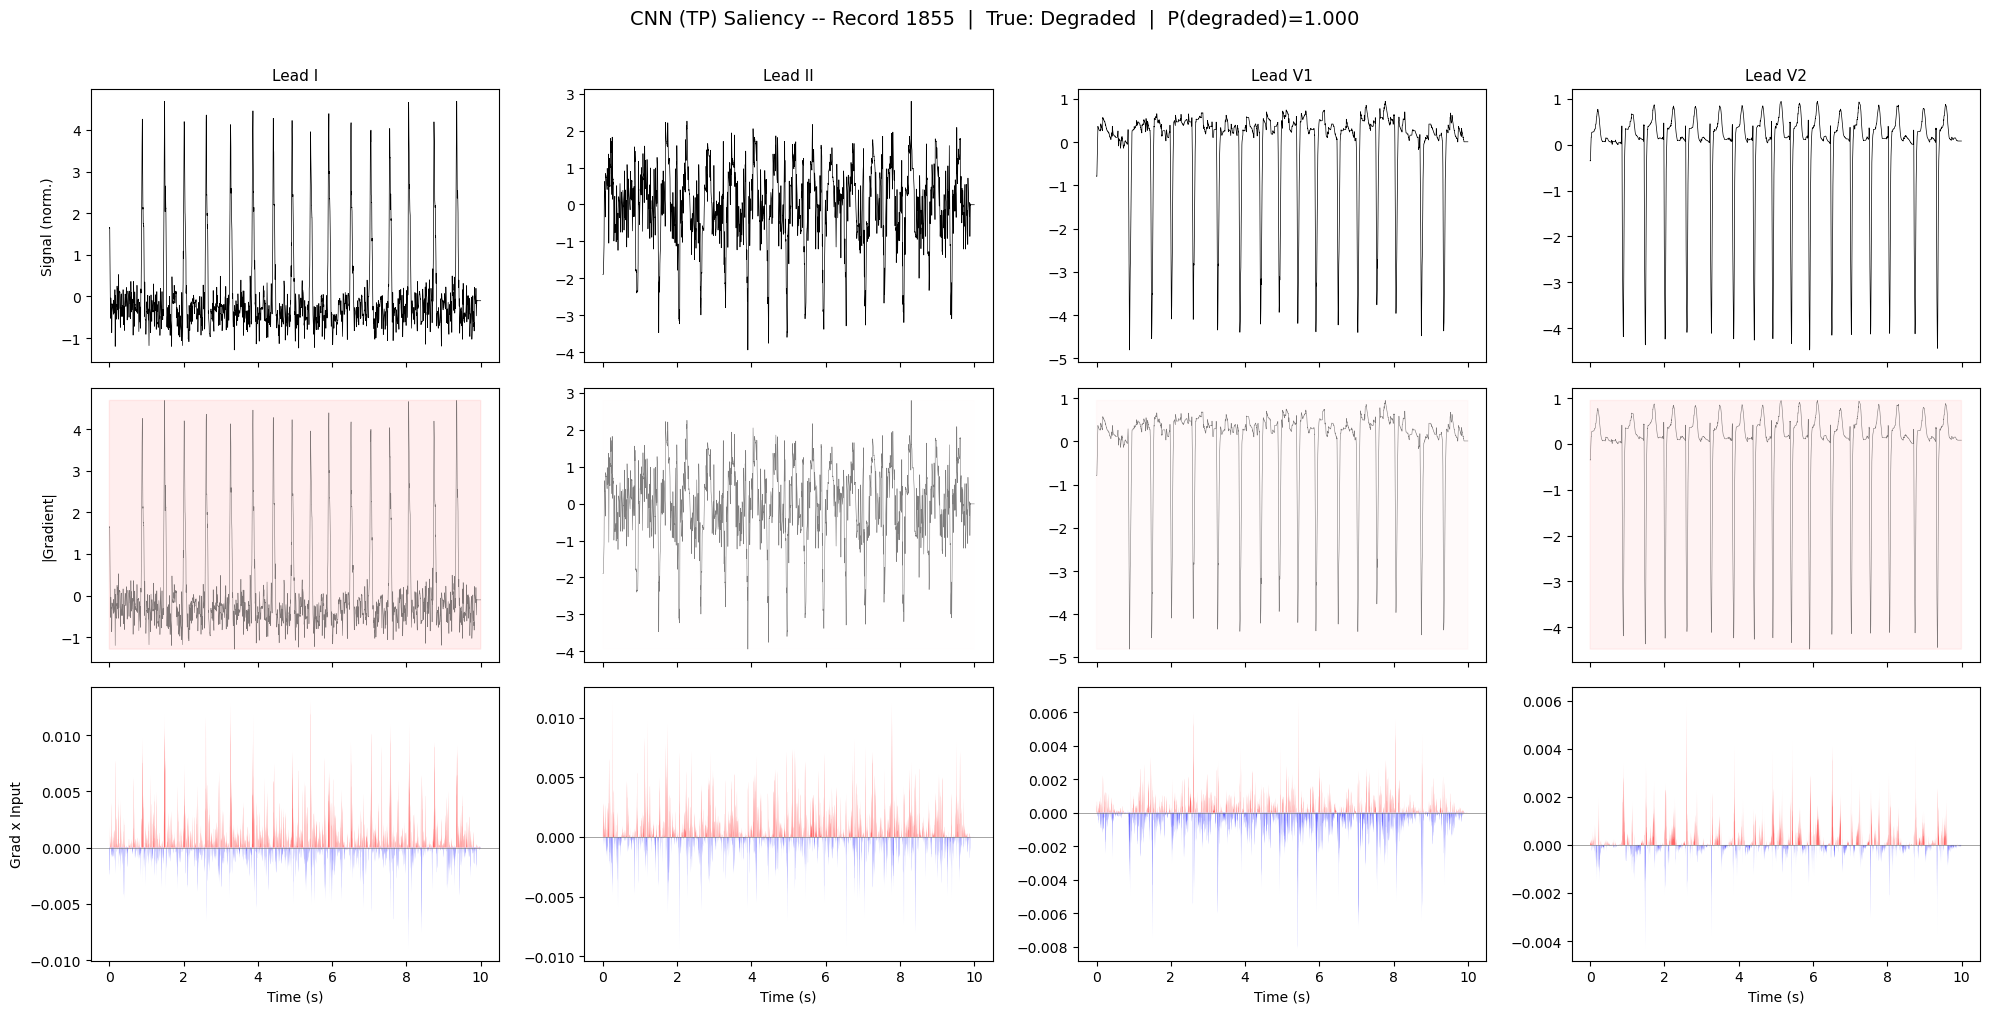

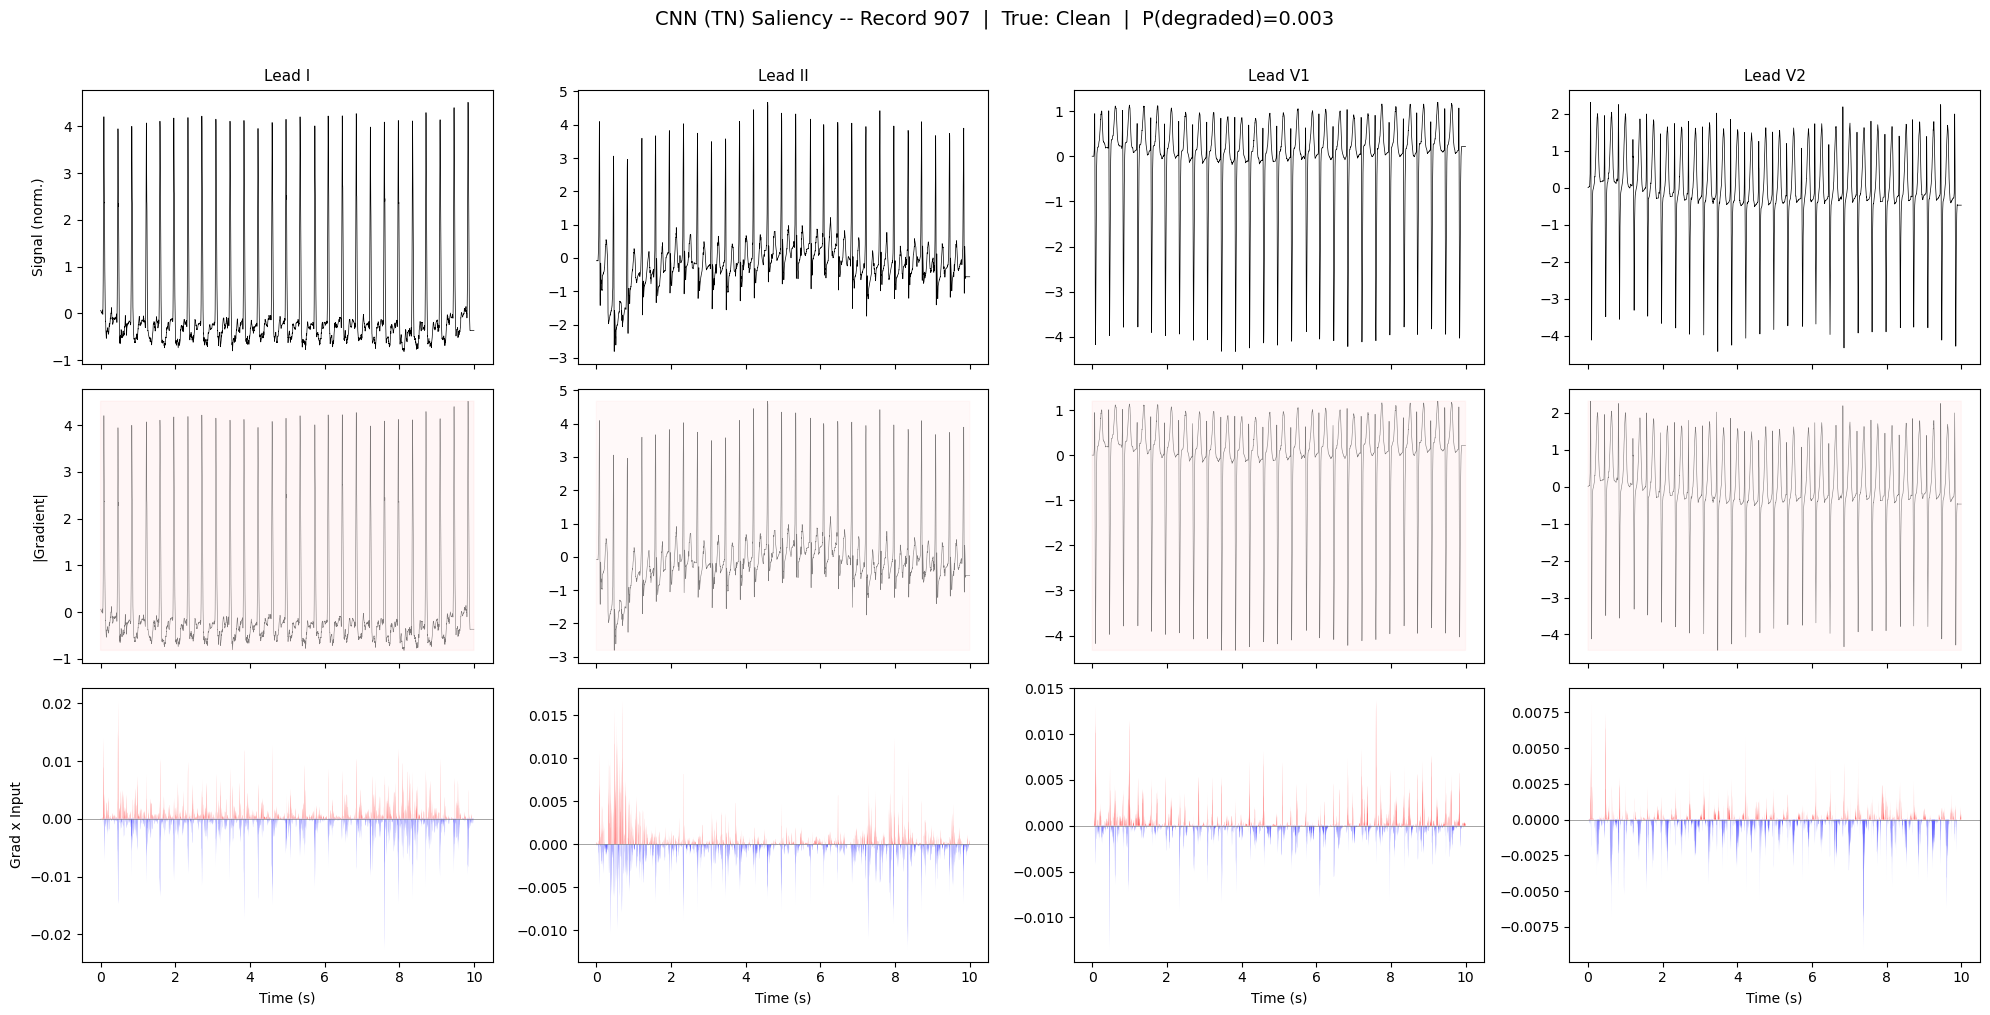

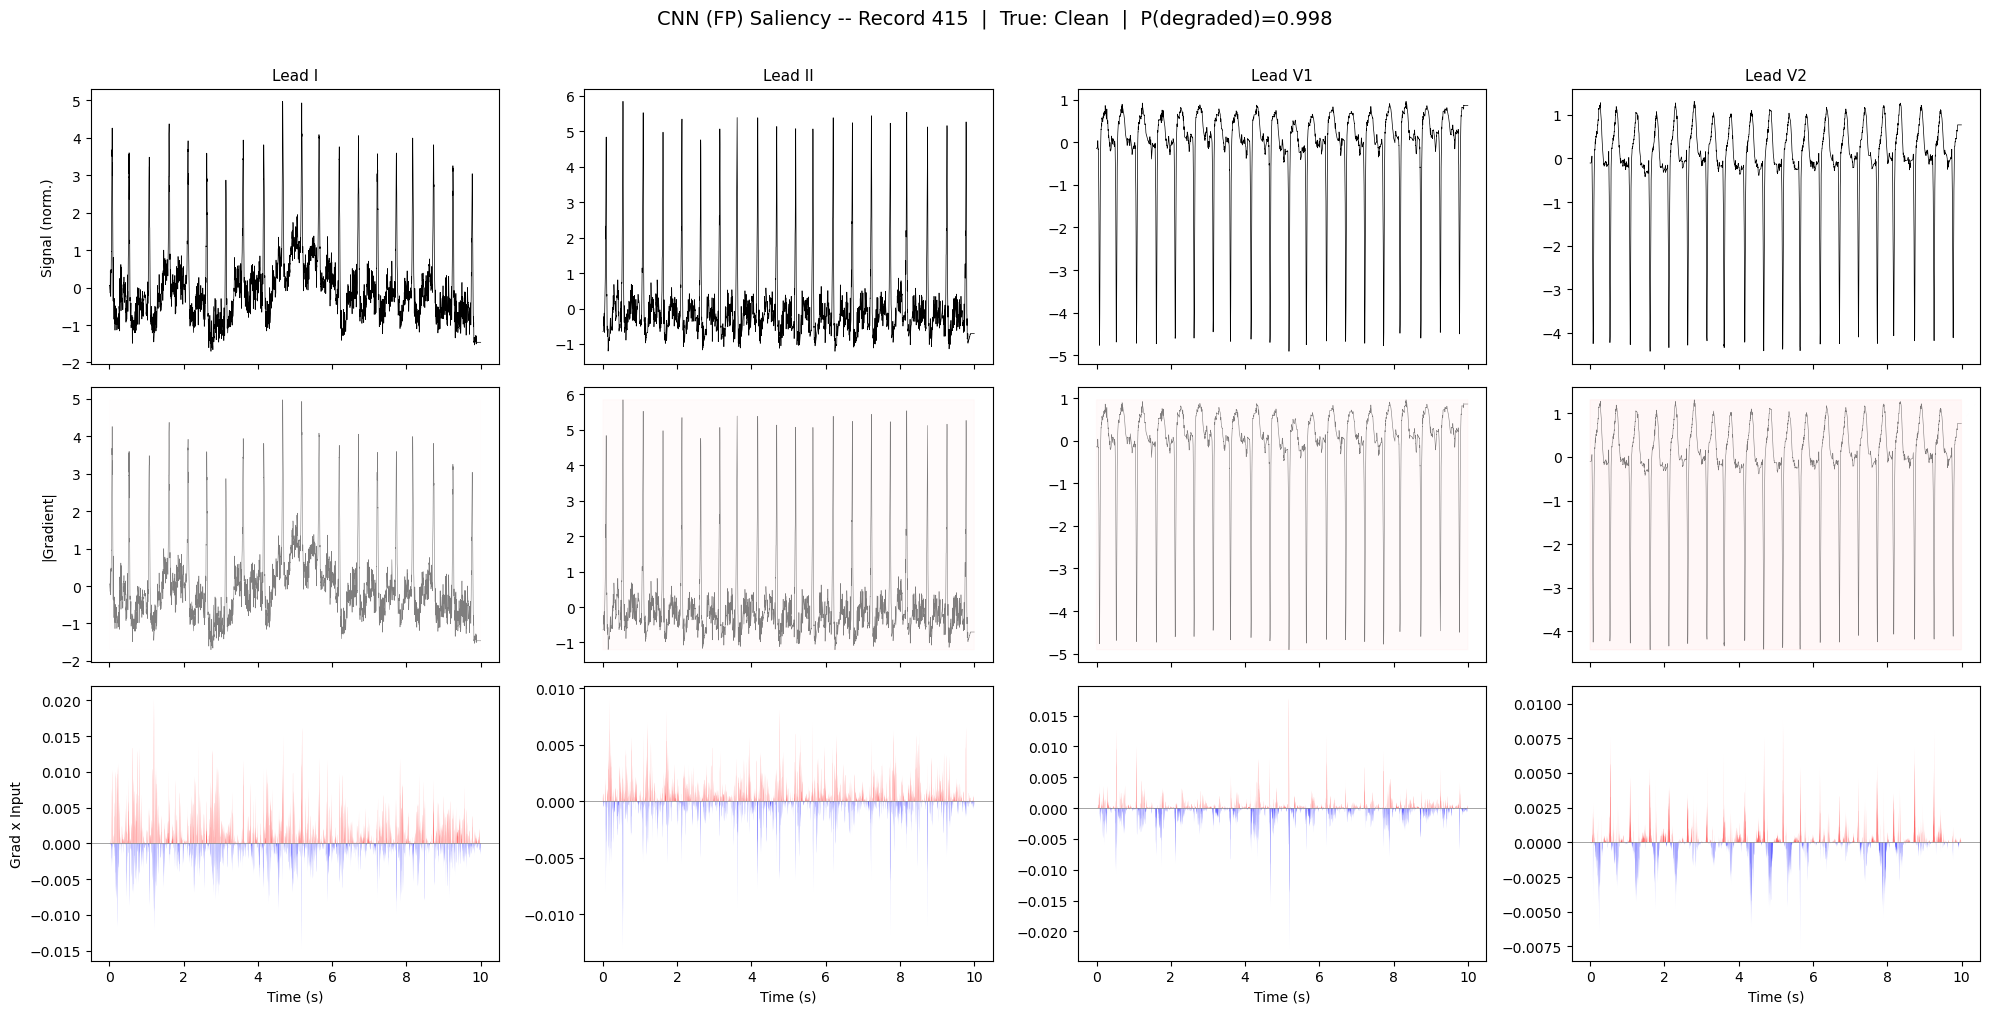

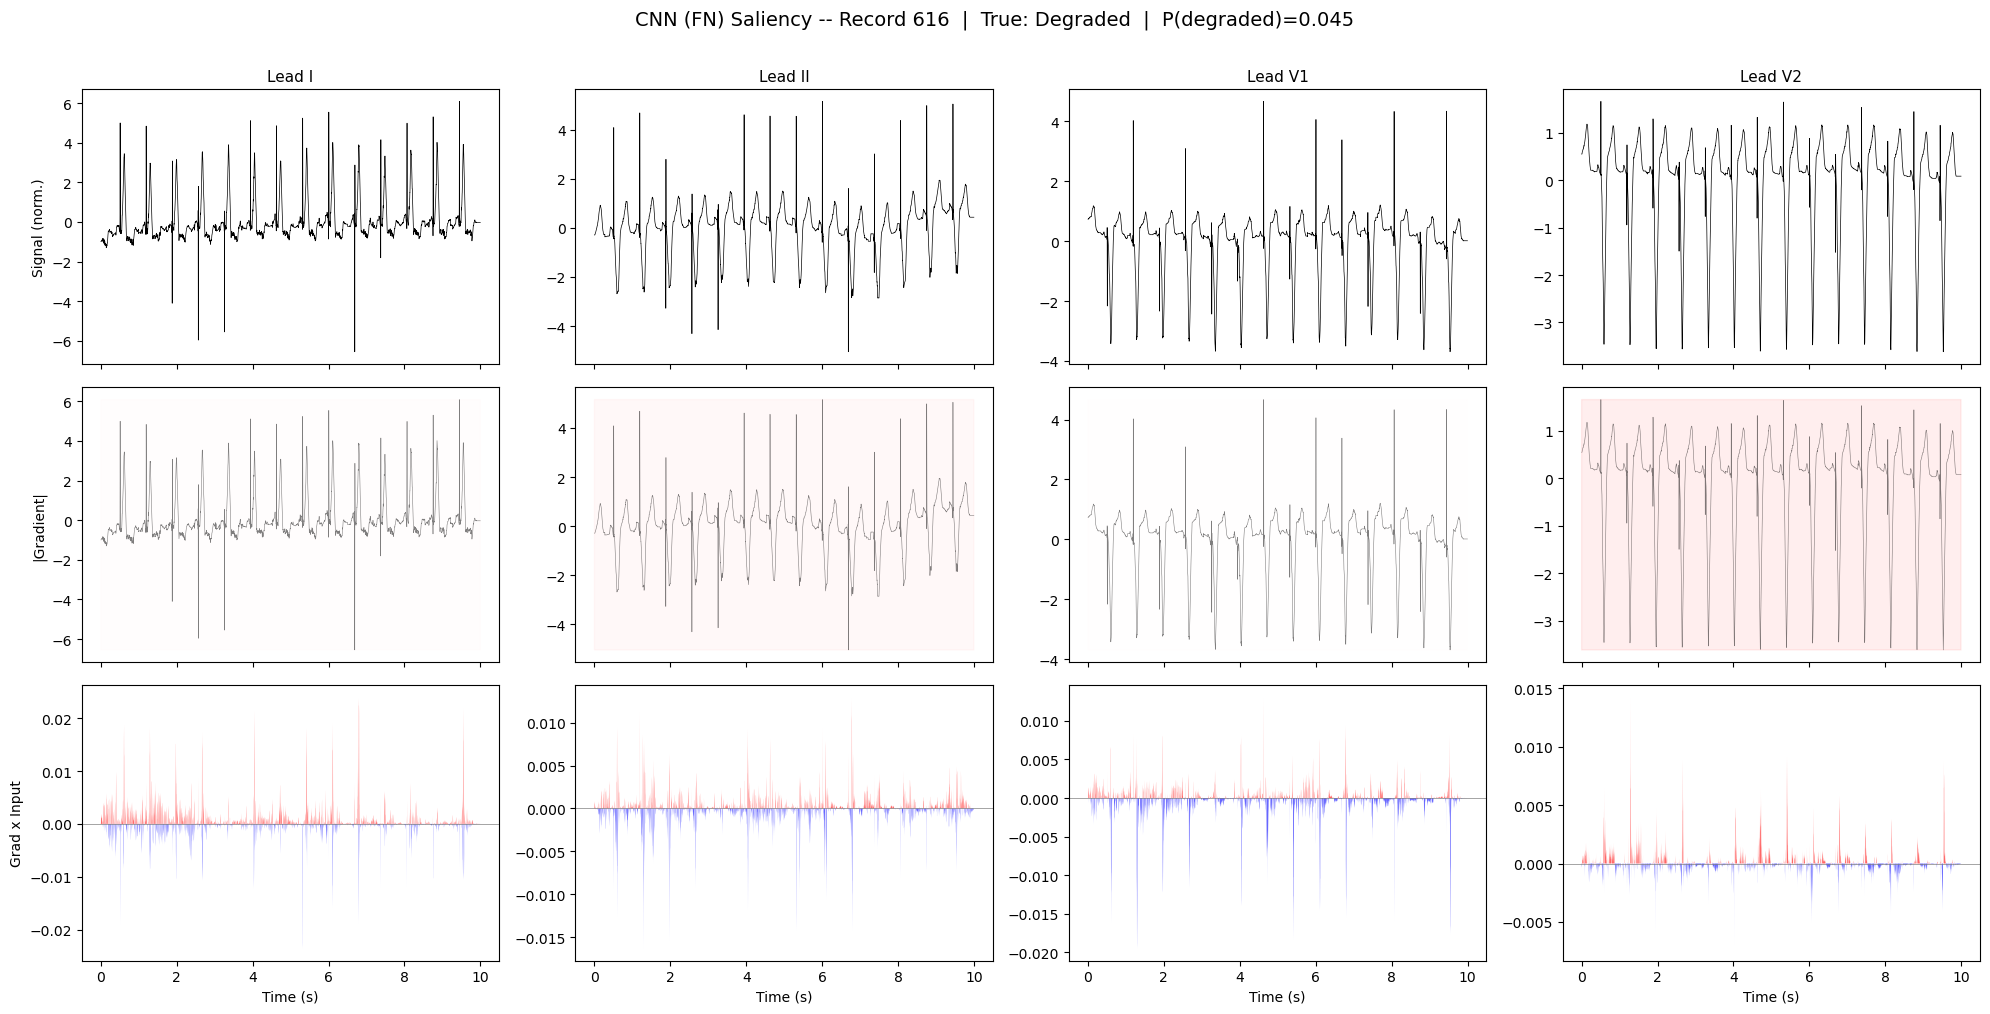

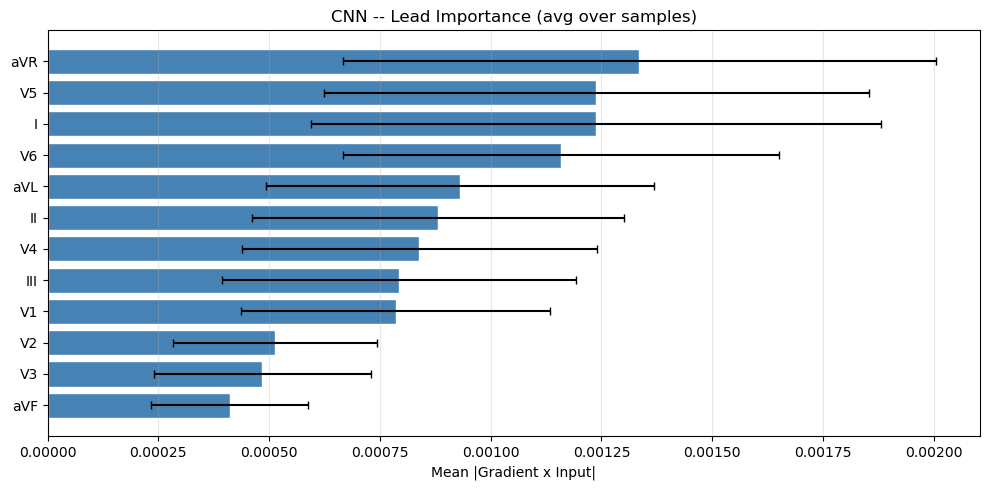

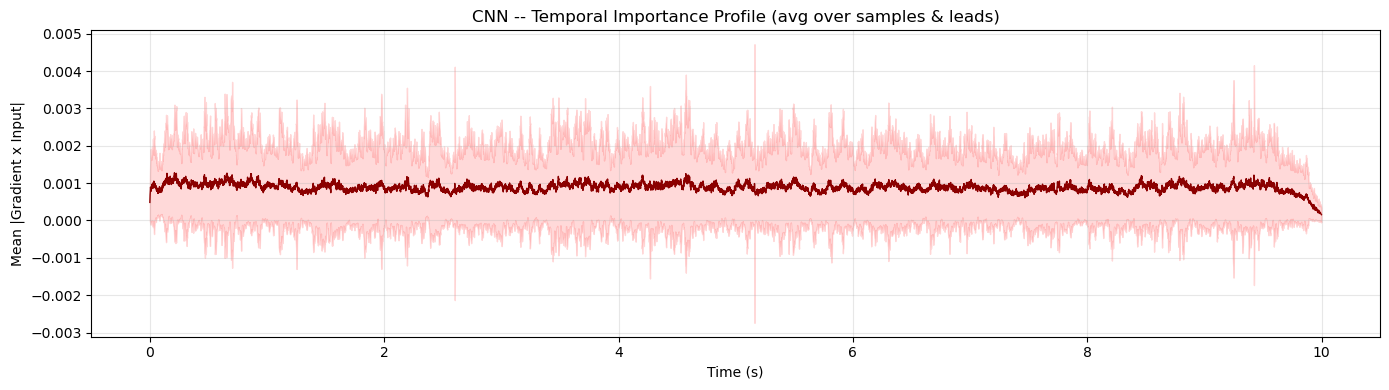

In [19]:
print("="*80)
print("CNN SALIENCY ANALYSIS")
print("="*80)

device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")

# Reload CNN from checkpoint
cnn_model = ECGConvNet().to(device)
cnn_ckpt = cfg.cache_dir / "dl2_best.pt"
if cnn_ckpt.exists():
    cnn_model.load_state_dict(torch.load(cnn_ckpt, map_location=device))
    print(f"Loaded CNN checkpoint from {cnn_ckpt}")
else:
    print("WARNING: No CNN checkpoint found. Skipping CNN saliency.")
    cnn_model = None

if cnn_model is not None:
    # Build a small test dataset for saliency
    ds_te_sal = WaveDataset(db.iloc[idx_te], pd.Series(y_all).iloc[idx_te], cfg.data_root)

    # Select example records: 2 true-positive (degraded predicted degraded),
    # 2 true-negative (clean predicted clean), 2 false cases
    p_test_cnn = result_dl2["predictions"]
    y_te_arr = y_all[idx_te]

    tp_mask = (y_te_arr == 1) & (p_test_cnn >= 0.5)
    tn_mask = (y_te_arr == 0) & (p_test_cnn < 0.5)
    fp_mask = (y_te_arr == 0) & (p_test_cnn >= 0.5)
    fn_mask = (y_te_arr == 1) & (p_test_cnn < 0.5)

    example_indices = {}
    for name, mask in [("TP", tp_mask), ("TN", tn_mask), ("FP", fp_mask), ("FN", fn_mask)]:
        idxs = np.where(mask)[0]
        if len(idxs) > 0:
            # Pick the most confident example
            if name in ["TP", "FP"]:
                pick = idxs[np.argmax(p_test_cnn[idxs])]
            else:
                pick = idxs[np.argmin(p_test_cnn[idxs])]
            example_indices[name] = pick

    print(f"Selected {len(example_indices)} example records: {list(example_indices.keys())}")

    # Per-sample saliency plots
    for case_name, local_idx in example_indices.items():
        x_tensor, y_label = ds_te_sal[local_idx]
        x_tensor = x_tensor.unsqueeze(0)  # (1, 12, seq_len)

        grad, gxi = compute_saliency_vanilla(cnn_model, x_tensor, device, model_type="cnn")

        plot_saliency_single(
            x_np=x_tensor.squeeze(0).numpy(),
            grad=grad, grad_x_input=gxi,
            true_label=int(y_label.item()),
            pred_prob=float(p_test_cnn[local_idx]),
            model_name=f"CNN ({case_name})",
            record_idx=local_idx,
            save_path=cfg.cache_dir / "results" / f"saliency_cnn_{case_name}.png"
        )

    # Aggregate saliency over a batch of test samples
    N_AGG = min(200, len(ds_te_sal))
    rng = np.random.default_rng(42)
    agg_indices = rng.choice(len(ds_te_sal), N_AGG, replace=False)

    gxi_list_cnn = []
    for i in agg_indices:
        x_t, _ = ds_te_sal[i]
        _, gxi = compute_saliency_vanilla(cnn_model, x_t.unsqueeze(0), device, model_type="cnn")
        gxi_list_cnn.append(gxi)

    plot_lead_importance_bar(gxi_list_cnn, "CNN",
                            save_path=cfg.cache_dir / "results" / "saliency_cnn_lead_importance.png")
    plot_temporal_importance(gxi_list_cnn, "CNN",
                            save_path=cfg.cache_dir / "results" / "saliency_cnn_temporal.png")

### CNN-Transformer Ensemble (DL3) Saliency Maps

CNN-TRANSFORMER ENSEMBLE SALIENCY ANALYSIS
DL3 ensemble models are not available from cache (model weights are not persisted).
Re-instantiating and training a single representative model for saliency analysis...
  Epoch 0: AUC=0.7504
  Epoch 20: AUC=0.7965
  Early stop epoch 26, best AUC: 0.7970
  Trained single CNN-Transformer model (AUC=0.7970) for saliency
Selected 4 example records: ['TP', 'TN', 'FP', 'FN']


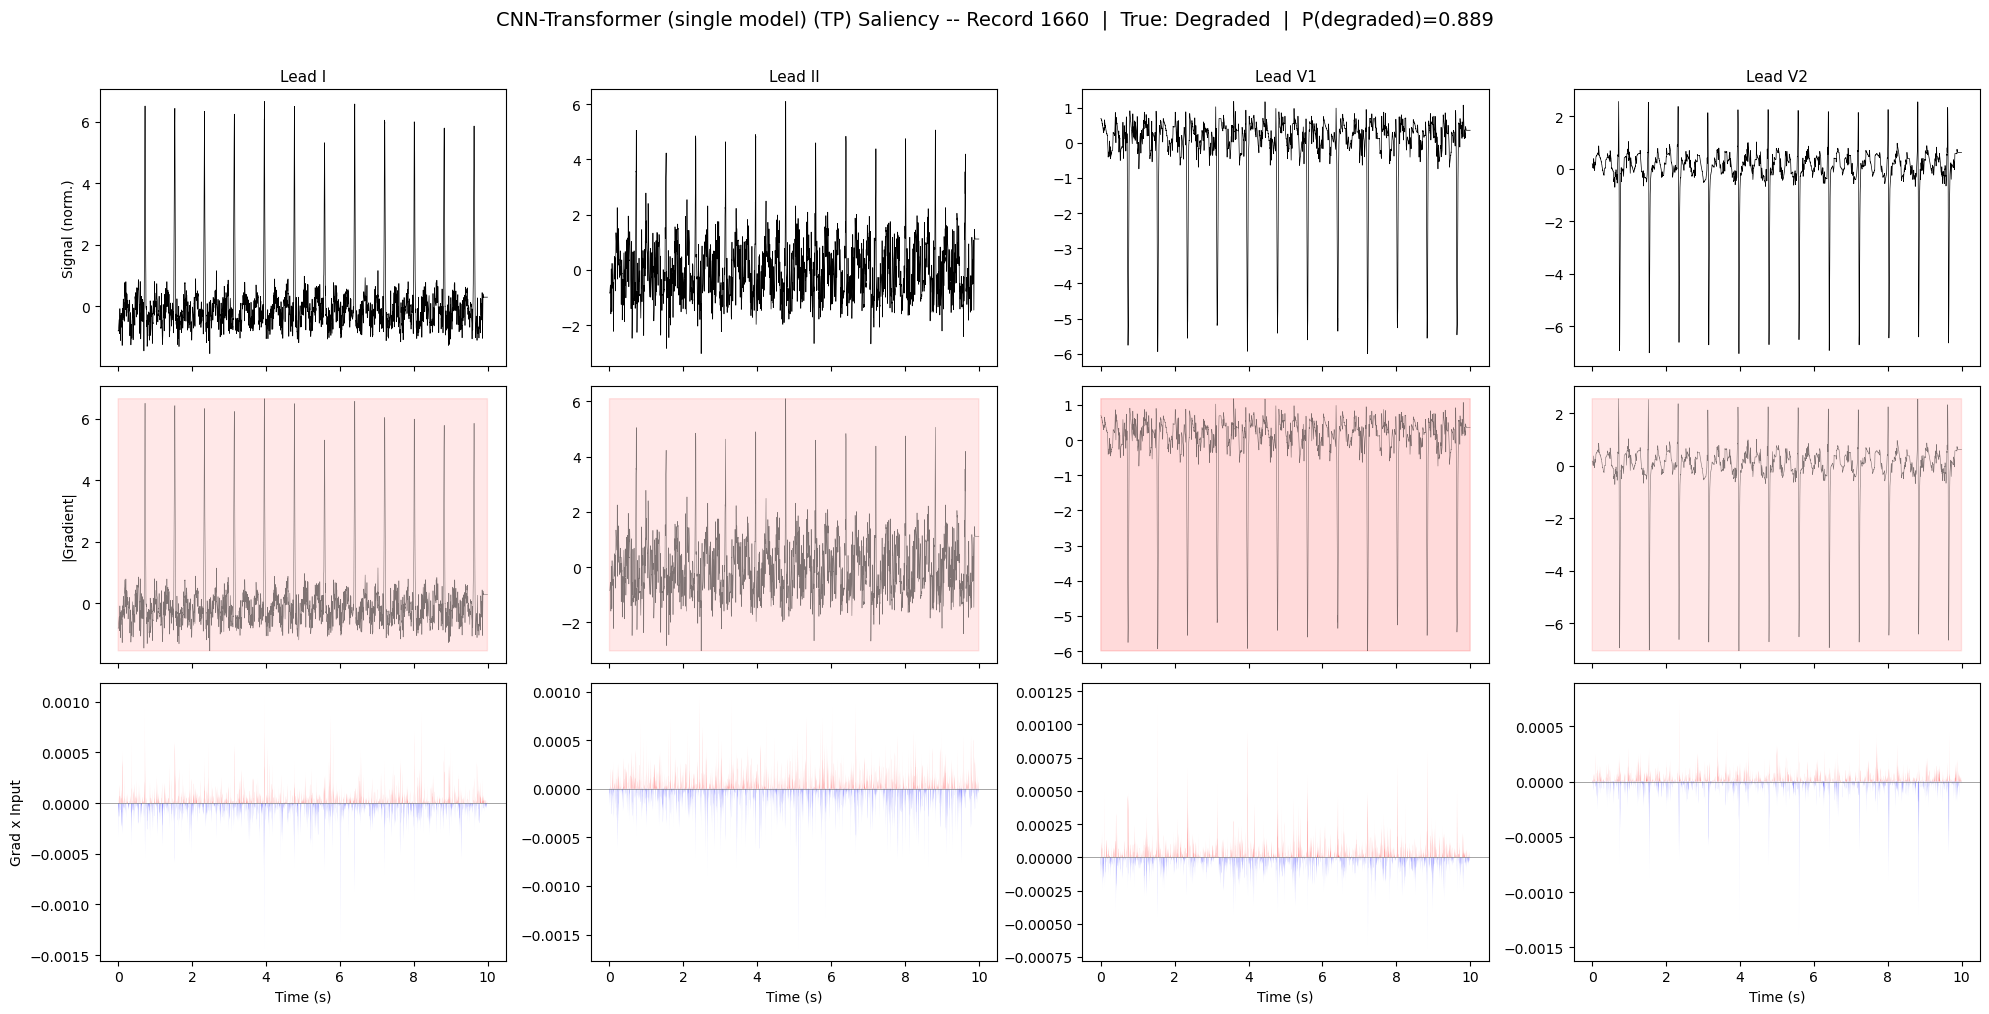

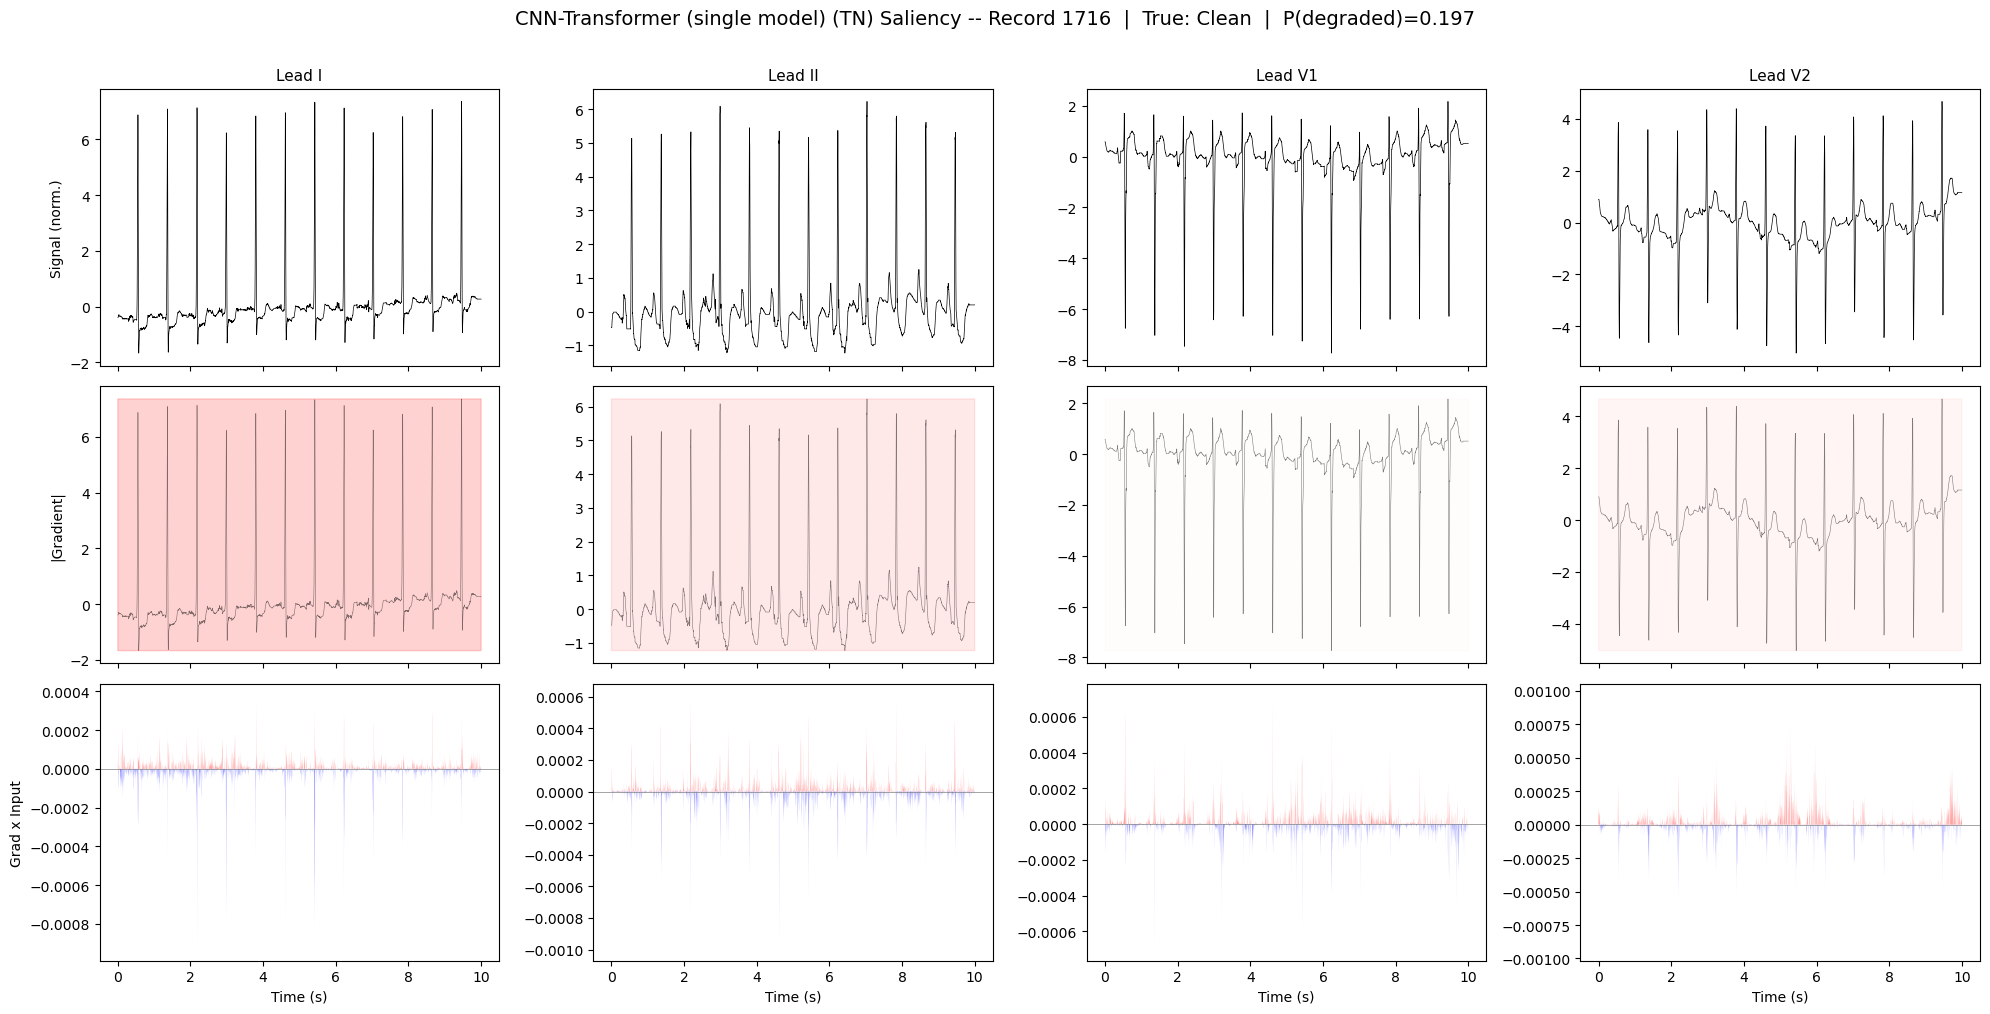

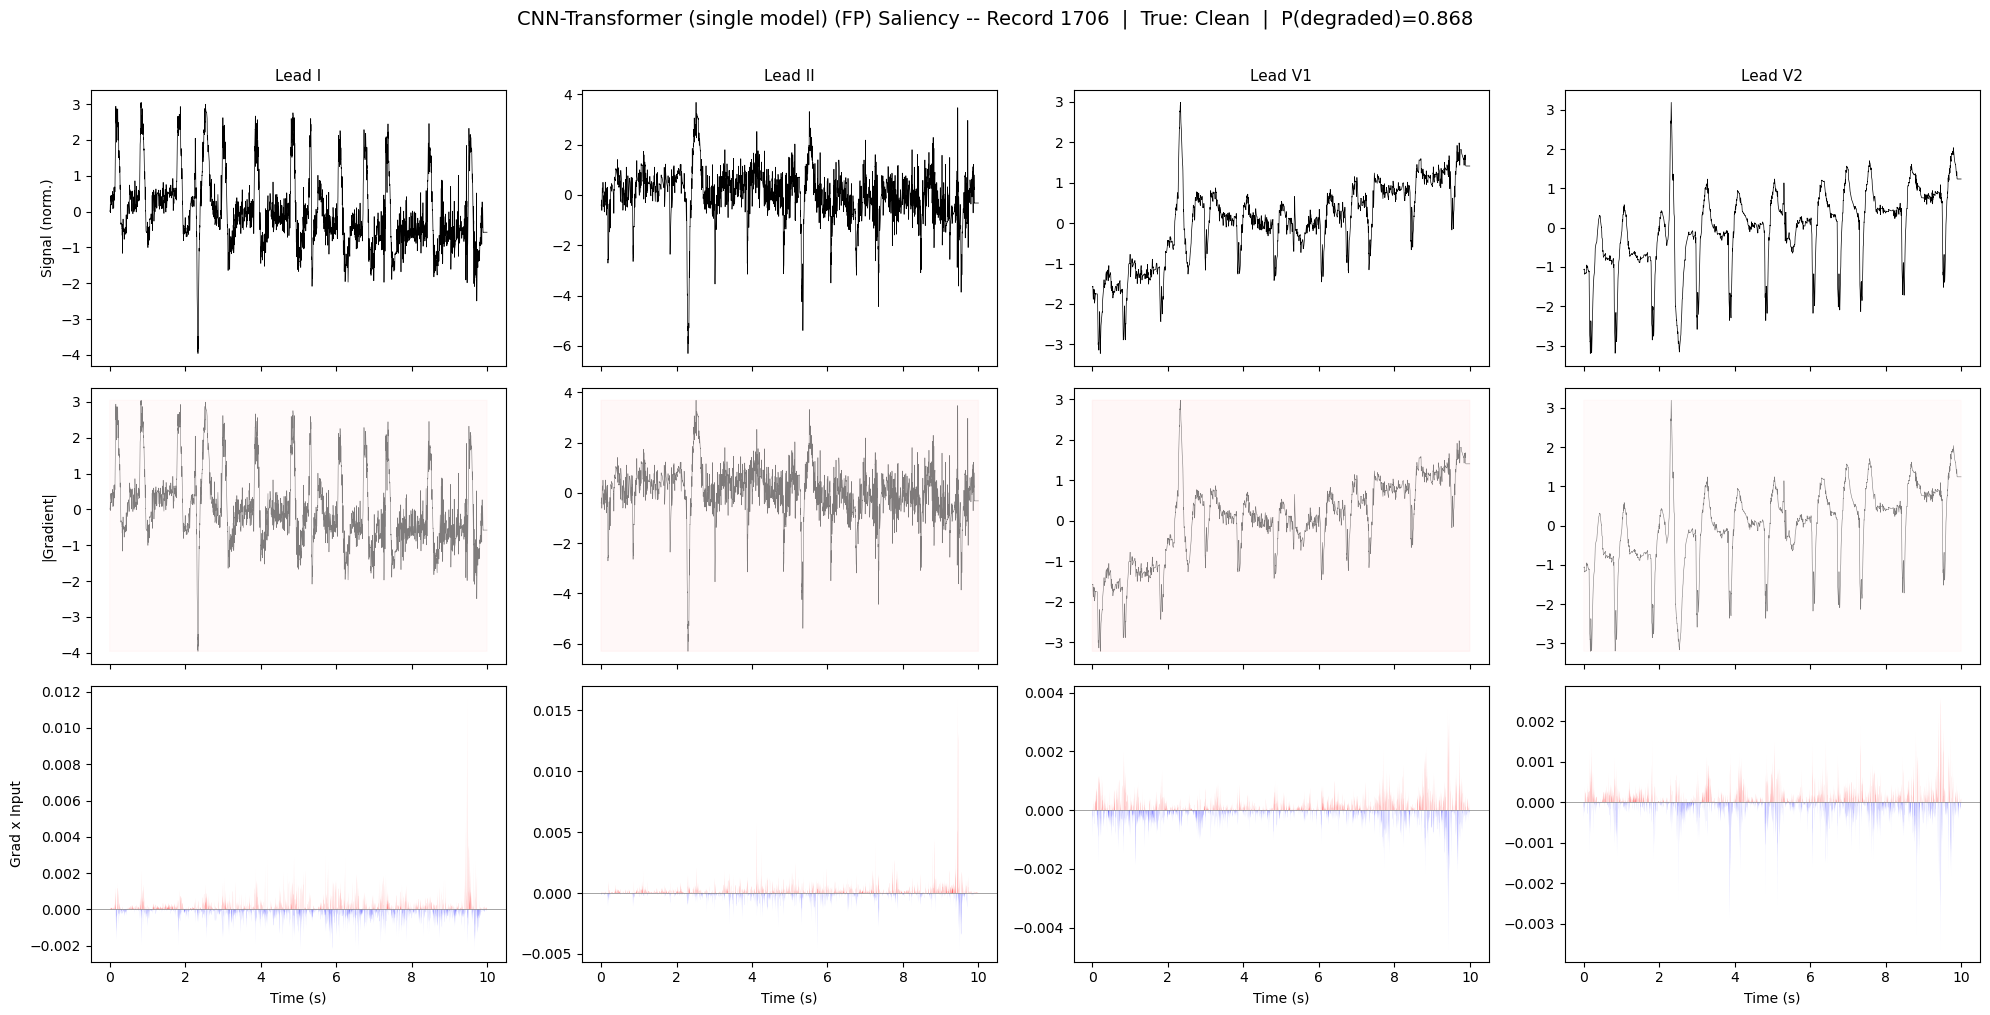

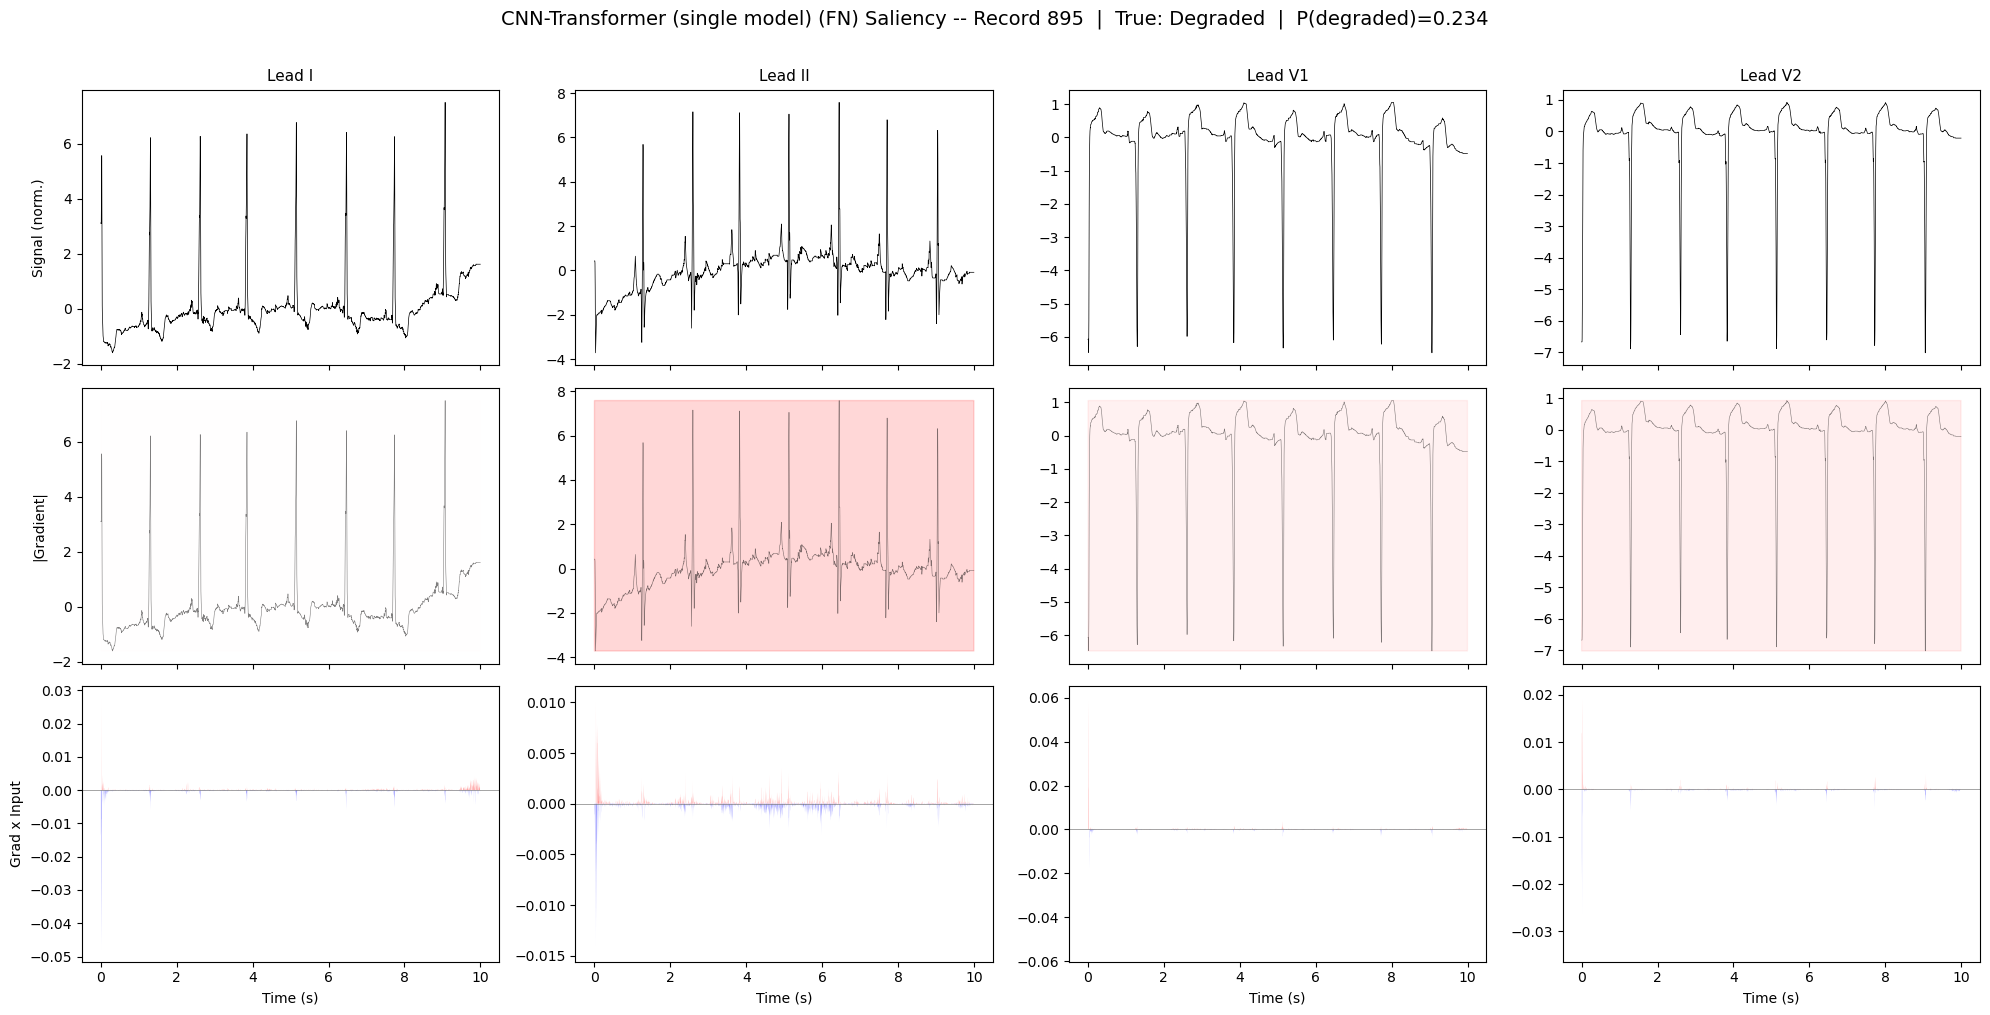

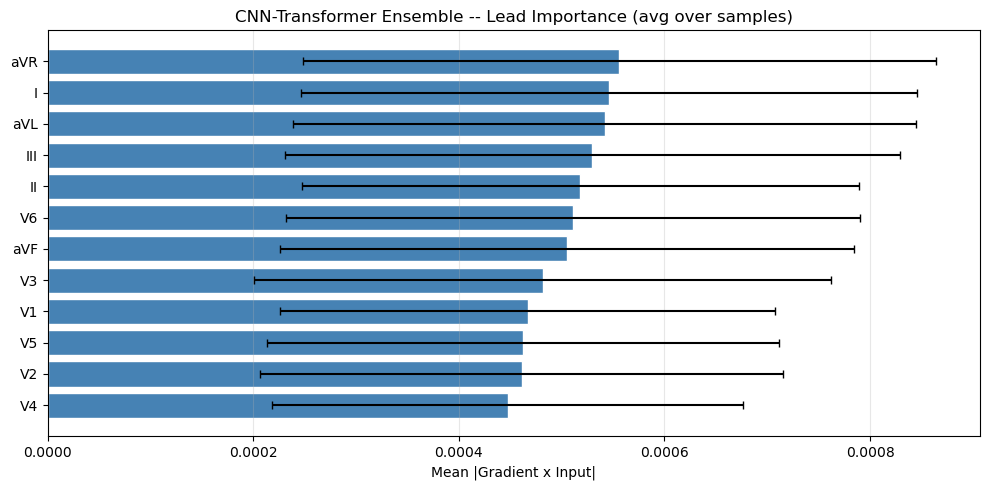

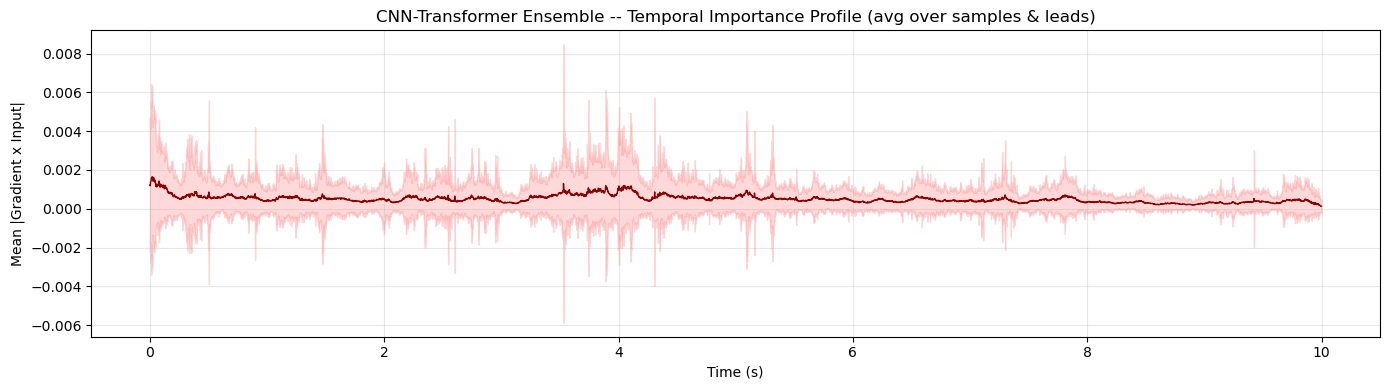

In [20]:
print("="*80)
print("CNN-TRANSFORMER ENSEMBLE SALIENCY ANALYSIS")
print("="*80)

# Check if DL3 models are available (only present if freshly trained, not from cache)
dl3_models = None

# Try to get models from the training result
if "models" in result_dl3 and result_dl3["models"] is not None:
    dl3_models = result_dl3["models"]
    print(f"Using {len(dl3_models)} ensemble models from training run")
else:
    # Models aren't cached -- need to retrain or inform user
    print("DL3 ensemble models are not available from cache (model weights are not persisted).")
    print("Re-instantiating and training a single representative model for saliency analysis...")

    # Train a single lightweight model for saliency purposes
    device = torch.device("mps" if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")

    torch.manual_seed(cfg.random_seed)
    np.random.seed(cfg.random_seed)

    dl3_single = ECGQualityTransformer(
        d_model=cfg.dl3_d_model, n_heads=cfg.dl3_n_heads, n_layers=cfg.dl3_n_layers
    ).to(device)

    ds_tr_sal = WaveDatasetAugmented(db.iloc[idx_tr], pd.Series(y_all).iloc[idx_tr],
                                     cfg.data_root, augment=True)
    ds_val_sal = WaveDatasetAugmented(db.iloc[idx_val], pd.Series(y_all).iloc[idx_val],
                                      cfg.data_root)
    dl_tr_sal = DataLoader(ds_tr_sal, batch_size=cfg.batch_size, shuffle=True)
    dl_val_sal = DataLoader(ds_val_sal, batch_size=cfg.batch_size)

    n_pos = pd.Series(y_all).iloc[idx_tr].sum()
    pw = torch.tensor([(len(idx_tr) - n_pos) / n_pos], dtype=torch.float32, device=device)
    opt_sal = optim.AdamW(dl3_single.parameters(), lr=cfg.dl3_lr, weight_decay=0.01)
    sched_sal = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_sal, T_0=10, T_mult=2)
    crit_sal = FocalLoss(gamma=cfg.dl3_focal_gamma, pos_weight=pw)

    best_auc_sal, best_state_sal = 0, None
    patience_sal, patience_ctr_sal = 15, 0

    for epoch in range(cfg.dl3_epochs):
        dl3_single.train()
        for x, target in dl_tr_sal:
            x, target = x.to(device), target.to(device)
            opt_sal.zero_grad()
            logits, _ = dl3_single(x)
            crit_sal(logits, target).backward()
            torch.nn.utils.clip_grad_norm_(dl3_single.parameters(), 1.0)
            opt_sal.step()
        sched_sal.step()

        dl3_single.eval()
        probs_s, trues_s = [], []
        with torch.no_grad():
            for x, target in dl_val_sal:
                logits, _ = dl3_single(x.to(device))
                probs_s.extend(torch.sigmoid(logits).cpu().numpy())
                trues_s.extend(target.numpy())
        auc_s = roc_auc_score(trues_s, probs_s)
        if auc_s > best_auc_sal:
            best_auc_sal = auc_s
            best_state_sal = {k: v.cpu().clone() for k, v in dl3_single.state_dict().items()}
            patience_ctr_sal = 0
        else:
            patience_ctr_sal += 1
            if patience_ctr_sal >= patience_sal:
                print(f"  Early stop epoch {epoch+1}, best AUC: {best_auc_sal:.4f}")
                break
        if epoch % 20 == 0:
            print(f"  Epoch {epoch}: AUC={auc_s:.4f}")

    dl3_single.load_state_dict(best_state_sal)
    dl3_models = [dl3_single]
    print(f"  Trained single CNN-Transformer model (AUC={best_auc_sal:.4f}) for saliency")

if dl3_models is not None:
    device = torch.device("mps" if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")

    ds_te_sal3 = WaveDataset(db.iloc[idx_te], pd.Series(y_all).iloc[idx_te], cfg.data_root)

    p_test_dl3 = result_dl3["predictions"]
    y_te_arr3 = y_all[idx_te]

    tp_mask3 = (y_te_arr3 == 1) & (p_test_dl3 >= 0.5)
    tn_mask3 = (y_te_arr3 == 0) & (p_test_dl3 < 0.5)
    fp_mask3 = (y_te_arr3 == 0) & (p_test_dl3 >= 0.5)
    fn_mask3 = (y_te_arr3 == 1) & (p_test_dl3 < 0.5)

    example_indices3 = {}
    for name, mask in [("TP", tp_mask3), ("TN", tn_mask3), ("FP", fp_mask3), ("FN", fn_mask3)]:
        idxs = np.where(mask)[0]
        if len(idxs) > 0:
            if name in ["TP", "FP"]:
                pick = idxs[np.argmax(p_test_dl3[idxs])]
            else:
                pick = idxs[np.argmin(p_test_dl3[idxs])]
            example_indices3[name] = pick

    print(f"Selected {len(example_indices3)} example records: {list(example_indices3.keys())}")

    # Per-sample saliency (averaged across ensemble members)
    for case_name, local_idx in example_indices3.items():
        x_tensor, y_label = ds_te_sal3[local_idx]
        x_tensor_batch = x_tensor.unsqueeze(0)

        # Average saliency across ensemble members
        grads_ens, gxis_ens = [], []
        for m in dl3_models:
            m.to(device)
            g, gxi = compute_saliency_vanilla(m, x_tensor_batch, device, model_type="transformer")
            grads_ens.append(g)
            gxis_ens.append(gxi)

        avg_grad = np.mean(grads_ens, axis=0)
        avg_gxi = np.mean(gxis_ens, axis=0)

        ens_tag = f"(ensemble avg, n={len(dl3_models)})" if len(dl3_models) > 1 else "(single model)"
        plot_saliency_single(
            x_np=x_tensor.numpy(),
            grad=avg_grad, grad_x_input=avg_gxi,
            true_label=int(y_label.item()),
            pred_prob=float(p_test_dl3[local_idx]),
            model_name=f"CNN-Transformer {ens_tag} ({case_name})",
            record_idx=local_idx,
            save_path=cfg.cache_dir / "results" / f"saliency_dl3_{case_name}.png"
        )

    # Aggregate saliency over batch
    N_AGG3 = min(200, len(ds_te_sal3))
    rng3 = np.random.default_rng(42)
    agg_indices3 = rng3.choice(len(ds_te_sal3), N_AGG3, replace=False)

    gxi_list_dl3 = []
    for i in agg_indices3:
        x_t, _ = ds_te_sal3[i]
        gxis_m = []
        for m in dl3_models:
            m.to(device)
            _, gxi = compute_saliency_vanilla(m, x_t.unsqueeze(0), device, model_type="transformer")
            gxis_m.append(gxi)
        gxi_list_dl3.append(np.mean(gxis_m, axis=0))

    plot_lead_importance_bar(gxi_list_dl3, "CNN-Transformer Ensemble",
                            save_path=cfg.cache_dir / "results" / "saliency_dl3_lead_importance.png")
    plot_temporal_importance(gxi_list_dl3, "CNN-Transformer Ensemble",
                            save_path=cfg.cache_dir / "results" / "saliency_dl3_temporal.png")

### CNN vs. CNN-Transformer: Lead Importance Comparison

LEAD IMPORTANCE COMPARISON: CNN vs CNN-Transformer


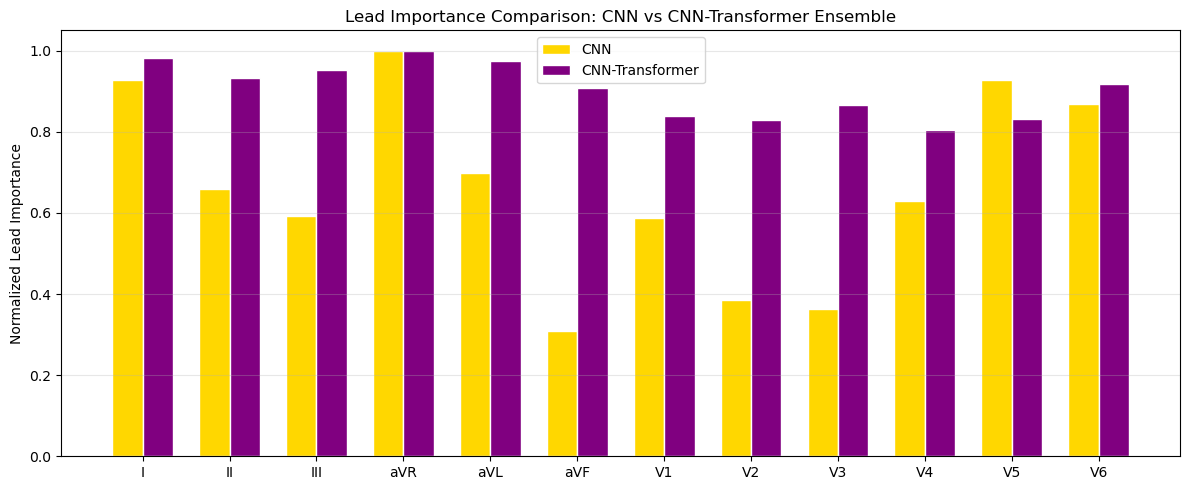


Lead   |          CNN |    CNN-Transformer |  Ratio (DL3/CNN)
------------------------------------------------------------
I      |     0.001238 |           0.000546 |             0.44
II     |     0.000881 |           0.000518 |             0.59
III    |     0.000793 |           0.000530 |             0.67
aVR    |     0.001336 |           0.000556 |             0.42
aVL    |     0.000931 |           0.000542 |             0.58
aVF    |     0.000411 |           0.000505 |             1.23
V1     |     0.000786 |           0.000467 |             0.59
V2     |     0.000514 |           0.000461 |             0.90
V3     |     0.000485 |           0.000481 |             0.99
V4     |     0.000839 |           0.000448 |             0.53
V5     |     0.001239 |           0.000462 |             0.37
V6     |     0.001159 |           0.000511 |             0.44


In [21]:
if cnn_model is not None and dl3_models is not None:
    print("="*80)
    print("LEAD IMPORTANCE COMPARISON: CNN vs CNN-Transformer")
    print("="*80)

    # Compute per-lead mean |grad*input| for both models
    cnn_per_lead = np.array([np.mean(np.abs(g), axis=1) for g in gxi_list_cnn]).mean(axis=0)
    dl3_per_lead = np.array([np.mean(np.abs(g), axis=1) for g in gxi_list_dl3]).mean(axis=0)

    # Normalize to [0,1] for comparison
    cnn_norm = cnn_per_lead / (cnn_per_lead.max() + 1e-10)
    dl3_norm = dl3_per_lead / (dl3_per_lead.max() + 1e-10)

    x_pos = np.arange(12)
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x_pos - width/2, cnn_norm, width, label='CNN', color='gold', edgecolor='white')
    ax.bar(x_pos + width/2, dl3_norm, width, label='CNN-Transformer', color='purple', edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(LEAD_NAMES)
    ax.set_ylabel("Normalized Lead Importance")
    ax.set_title("Lead Importance Comparison: CNN vs CNN-Transformer Ensemble")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(cfg.cache_dir / "results" / "saliency_lead_comparison.png", dpi=300)
    plt.show()

    # Print table
    print(f"\n{'Lead':<6} | {'CNN':>12} | {'CNN-Transformer':>18} | {'Ratio (DL3/CNN)':>16}")
    print("-" * 60)
    for i in range(12):
        ratio = dl3_per_lead[i] / (cnn_per_lead[i] + 1e-10)
        print(f"{LEAD_NAMES[i]:<6} | {cnn_per_lead[i]:>12.6f} | {dl3_per_lead[i]:>18.6f} | {ratio:>16.2f}")